# Merged Student Performance Dataset — Cleaning, EDA, Feature Analysis and CGPA Modelling

**CSE-4112 Machine Learning Laboratory**

| | |
|---|---|
| **Source A** | `raw-data/University Student Performance Analysis Form (Responses)...csv` — 230 responses, BUET / BRAC / CUET |
| **Source B** | `raw-data/Student Performance Analysis Form (Responses)...csv` — 896 responses, KUET only |
| **Merged** | 1,126 raw responses from **four** universities |
| **Target** | `cgpa_band` — 4 ordered classes (C0–C3) |
| **Pipeline A** | Which factors are most associated with CGPA? (ranking / inference) |
| **Pipeline B** | Predict a student's CGPA band from their answers (ordinal classification) |

---

### How to read this notebook

Every step is written as **Decision → Evidence → Why**. The viva asks *"how did you preprocess
and why"*, so nothing here is dropped, imputed or merged without a number in front of it
justifying the choice — and the rejected alternative is named.

### Why this notebook exists (and what changed since `01_...`)

Notebook `01` used the 230-response multi-university form alone. Three of its results were
*sample-size* problems, not method problems:

1. **No feature survived multiple-comparison correction.** With n = 230 across 4 classes, an
   effect had to reach |rho| ~ 0.18 to be detectable. Real effects of size 0.09-0.12 were invisible.
2. Two **counterintuitive** associations (clearer lectures -> worse grades; more stress -> better
   grades) had to be reported as unexplained oddities.
3. The composite "hidden feature" indices collapsed (Cronbach's alpha ~ 0).

The KUET form gives us **896 more responses to almost the same questionnaire**. This notebook
merges the two, re-runs the whole analysis at n ~ 1,100, and reports which of those three
findings replicate and which were small-sample noise. That comparison is itself a result.

### Contents

| § | Section |
|---|---------|
| 1 | Setup |
| 2 | Load both raw sources and look at them |
| 3 | Schema harmonisation — how the two forms are merged |
| 4 | Data-quality audit of the merged frame |
| 5 | The cleaning pipeline (12 steps) |
| 6 | Exploratory Data Analysis |
| 7 | Pipeline A — feature analysis: which features actually matter |
| 8 | Pipeline B — CGPA prediction models and comparison |
| 9 | Verdict |
| 10 | Predicting for a new student |
| 11 | Export for WEKA |
| 12 | Summary of findings |

## 1. Setup

In [1]:
import warnings, re, json, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_MULTI = ROOT / "raw-data" / "University Student Performance Analysis Form (Responses) - Form Responses 1.csv"
RAW_KUET  = ROOT / "raw-data" / "Student Performance Analysis Form (Responses) - Form Responses 1.csv"
OUT_DIR   = ROOT / "cleaned-dataset" / "ours" / "merged"
FIG_DIR   = ROOT / "docs" / "figures" / "merged"
DOC_DIR   = ROOT / "docs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"
PALETTE = ["#3E7CB1", "#E8A33D", "#5FA55A", "#C4554D", "#8A6FA8", "#7A7A7A"]
SRC_COLOR = {"multi_uni": PALETTE[0], "kuet": PALETTE[1]}

def save_fig(name):
    """Save the current figure into docs/figures/merged/ and display it."""
    plt.savefig(FIG_DIR / f"{name}.png")
    plt.show()

print("pandas", pd.__version__, "| numpy", np.__version__)
print("root:", ROOT)
print("multi-university file exists:", RAW_MULTI.exists())
print("KUET file exists            :", RAW_KUET.exists())

pandas 3.0.5 | numpy 2.5.2
root: E:\4-1\ml-lab
multi-university file exists: True
KUET file exists            : True


## 2. Load both raw sources and look at them

Both are Google Form exports. Each question becomes a full **bilingual** column header
(English + Bangla), so the raw column names are unusable as identifiers. Step one is simply to
see what each form asked.

In [2]:
raw_multi = pd.read_csv(RAW_MULTI)
raw_kuet  = pd.read_csv(RAW_KUET)

print(f"multi-university : {raw_multi.shape[0]:>4} rows x {raw_multi.shape[1]} columns")
print(f"KUET             : {raw_kuet.shape[0]:>4} rows x {raw_kuet.shape[1]} columns")
print(f"combined         : {raw_multi.shape[0] + raw_kuet.shape[0]:>4} raw responses")

BANGLA_RANGE = "ঀ-৿"

def english_half(cols):
    """Everything before the Bangla translation — Bangla sits after a newline or inside ()."""
    out = []
    for c in cols:
        head = c.split("\n")[0]
        head = re.sub(rf"\s*\([^)]*[{BANGLA_RANGE}][^)]*\)\s*$", "", head)
        out.append(head.strip().rstrip("-").strip())
    return out

q_multi = english_half(raw_multi.columns)
q_kuet  = english_half(raw_kuet.columns)

n = max(len(q_multi), len(q_kuet))
side = pd.DataFrame({
    "#": range(n),
    "multi-university form": q_multi + [""] * (n - len(q_multi)),
    "KUET form": q_kuet + [""] * (n - len(q_kuet)),
}).set_index("#")
side

multi-university :  230 rows x 22 columns
KUET             :  896 rows x 21 columns
combined         : 1126 raw responses


,multi-university form,KUET form
#,,
0,Timestamp,Timestamp
1,What is the name your university?,What is your department?
2,How satisfied are you with getting admitted in...,Which semester are you currently in?
3,What is your department?,What is your SGPA of the most recently complet...
4,"If your department is not listed above, then w...",What is your current CGPA?
5,Did you get into your desired subject or depar...,How often were you actually present in class?
6,Which semester are you currently in?,"Outside class, how much did you usually study ..."
7,What was your SGPA in the most recently comple...,Which study style sounds most like you?
8,"Before that semester, what was your CGPA?","When a class ended, how much of the topic was ..."


**What the side-by-side shows.** The two forms ask the *same 19 substantive questions* but in a
different order, with slightly different English wording, and with structural differences:

| | multi-university form | KUET form |
|---|---|---|
| University question | asked (BUET / BRAC / CUET, free text) | **absent** — every respondent is KUET |
| Department | a dropdown **+** a separate "if not listed" write-in box | **one free-text box** |
| Email address | not collected | column present but **100% empty** |
| Satisfaction wording | "...admitted into **your university**" | "...admitted into **KUET**" |
| GPA options | 6 bands (`Below`, `3.0+`, `3.2+`, `3.5+`, `3.75+`, `3.9+`) | 4 bands (`Below`, `3.20 - 3.49`, `3.50 - 3.74`, `3.75+`) |
| Responsibilities options | 4 bands, **no zero option** | 5 bands, **includes `None`** |

None of these blocks a merge. Every one is a documented cleaning decision in §5.

## 3. Schema harmonisation — how the two forms are merged

This is the part the task hinges on: *"there may be some fields written in a bit changed
English, but if they mean the same then they are the same."*

Four passes:

| Pass | What it fixes |
|------|---------------|
| 3.1 | **Column identity** — map both header sets onto one `snake_case` schema |
| 3.2 | **Value text** — strip the Bangla translation and emoji out of every answer |
| 3.3 | **Option sets** — verify the answer options of each shared question actually match |
| 3.4 | **Concatenate** — stack the rows, keeping a `source_form` provenance column |

### 3.1 Column identity

**Decision:** hand-map each raw column index onto a shared `snake_case` name.

**Why not fuzzy string matching?** The English wording differs (*"What **is** your SGPA **of** the
most recently completed semester?"* vs *"What **was** your SGPA **in** the most recently completed
semester?"*), and one question is genuinely re-worded per institution ("...admitted into KUET" vs
"...admitted into your university"). A similarity threshold loose enough to catch those would
also merge the two *satisfaction* questions with each other. 21 columns is small enough to map by
hand and then `assert` on — safer, and auditable by a reader.

In [3]:
# Canonical schema. The name on the left is what everything downstream uses.
KUET_COLMAP = {
    0:  "timestamp",
    1:  "department_listed",
    2:  "semester_raw",
    3:  "recent_sgpa_raw",          # last completed semester's SGPA
    4:  "cgpa_raw",                 # -> becomes the TARGET
    5:  "attendance",
    6:  "weekly_study_time",
    7:  "study_style",
    8:  "topic_clarity",
    9:  "sleep_duration",
    10: "stress_frequency",
    11: "weekly_responsibilities",
    12: "desired_department_match",
    13: "distraction_frequency",
    14: "study_environment",
    15: "support_level",
    16: "admission_satisfaction",   # "...into KUET"
    17: "career_expectation",
    18: "result_satisfaction",      # -> leakage risk, see 5.10
    19: "routine_manageability",
    20: "email",                    # 100% empty -> dropped
}

MULTI_COLMAP = {
    0:  "timestamp",
    1:  "university",
    2:  "admission_satisfaction",   # "...into your university"
    3:  "department_listed",
    4:  "department_other",
    5:  "desired_department_match",
    6:  "semester_raw",
    7:  "recent_sgpa_raw",
    8:  "cgpa_raw",
    9:  "result_satisfaction",
    10: "attendance",
    11: "weekly_study_time",
    12: "study_style",
    13: "topic_clarity",
    14: "sleep_duration",
    15: "stress_frequency",
    16: "weekly_responsibilities",
    17: "distraction_frequency",
    18: "study_environment",
    19: "support_level",
    20: "routine_manageability",
    21: "career_expectation",
}

assert len(KUET_COLMAP)  == raw_kuet.shape[1],  "KUET map must cover every raw column"
assert len(MULTI_COLMAP) == raw_multi.shape[1], "multi-uni map must cover every raw column"

kuet  = raw_kuet.copy();  kuet.columns  = [KUET_COLMAP[i]  for i in range(raw_kuet.shape[1])]
multi = raw_multi.copy(); multi.columns = [MULTI_COLMAP[i] for i in range(raw_multi.shape[1])]

# Keep the exact question wording — the report has to quote it.
QUESTION_TEXT = {
    "kuet":  {KUET_COLMAP[i]:  q_kuet[i]  for i in range(len(q_kuet))},
    "multi": {MULTI_COLMAP[i]: q_multi[i] for i in range(len(q_multi))},
}

only_kuet  = set(kuet.columns)  - set(multi.columns)
only_multi = set(multi.columns) - set(kuet.columns)
shared     = set(kuet.columns)  & set(multi.columns)
print(f"shared columns ({len(shared):>2}): {sorted(shared)}\n")
print(f"KUET only      ({len(only_kuet):>2}): {sorted(only_kuet)}")
print(f"multi-uni only ({len(only_multi):>2}): {sorted(only_multi)}")

shared columns (20): ['admission_satisfaction', 'attendance', 'career_expectation', 'cgpa_raw', 'department_listed', 'desired_department_match', 'distraction_frequency', 'recent_sgpa_raw', 'result_satisfaction', 'routine_manageability', 'semester_raw', 'sleep_duration', 'stress_frequency', 'study_environment', 'study_style', 'support_level', 'timestamp', 'topic_clarity', 'weekly_responsibilities', 'weekly_study_time']

KUET only      ( 1): ['email']
multi-uni only ( 2): ['department_other', 'university']


**Resolving the asymmetries.**

| Column | Decision | Why |
|---|---|---|
| `university` (multi only) | fill `"KUET"` on every KUET row | The KUET form did not ask because it did not need to — the sampling frame *is* the university. A known constant, not an imputation. |
| `department_other` (multi only) | fill `NaN` on KUET rows | The KUET form used one free-text box, so there is no second column to merge. §5.3 handles both shapes with one canonicaliser. |
| `email` (KUET only) | **drop** | 896 / 896 empty. A column with zero information cannot help a model and would break the "no missing values" export gate. |
| `timestamp` (both) | **drop** in §5.1 | Records how the link spread through our networks, not a property of the student. |

In [4]:
kuet["university"] = "KUET"          # known constant, not an imputed value
kuet["department_other"] = np.nan    # KUET's form had one free-text department box

print("email column fill rate:", f"{kuet.email.notna().mean():.1%}")
kuet = kuet.drop(columns=["email"])

kuet["source_form"]  = "kuet"
multi["source_form"] = "multi_uni"

print("\nafter aligning columns:")
print("  KUET :", kuet.shape)
print("  multi:", multi.shape)
print("  identical column sets:", set(kuet.columns) == set(multi.columns))

email column fill rate: 0.0%

after aligning columns:
  KUET : (896, 23)
  multi: (230, 23)
  identical column sets: True


### 3.2 Strip the Bangla translation and emoji out of every answer

**Decision:** remove any parenthesis containing Bangla script, and any emoji, from every
categorical answer.

**Evidence:** the KUET form stores answers as `"90% or more (৯০% বা তার বেশি)"` and
`"😠 Very dissatisfied (খুবই অসন্তুষ্ট)"`; the multi-university form stores the same answers as
`"90% or more"` and `"Very dissatisfied"`.

**Why:** without this, `"90% or more"` and `"90% or more (৯০% বা তার বেশি)"` are two unrelated
categories, and the 1,126-row merge silently becomes two disjoint blocks that share no feature
values at all. Every model would then be learning "which form did this row come from". This one
regex is what makes the merge real rather than cosmetic.

We match **only** parentheses containing a Bangla codepoint (`U+0980`–`U+09FF`), so an English
clarification like `"Electrical and Electronic Engineering (EEE)"` survives for the department
canonicaliser in §5.3 to handle properly instead of being blindly deleted.

In [5]:
BANGLA_PAREN = re.compile(rf"\s*\([^)]*[{BANGLA_RANGE}][^)]*\)")
EMOJI = re.compile("[\U0001f300-\U0001faff☀-➿️]")

def strip_bilingual(v):
    """'😠 Very dissatisfied (খুবই অসন্তুষ্ট)'  ->  'Very dissatisfied'."""
    if not isinstance(v, str):
        return v
    v = unicodedata.normalize("NFKC", v)
    v = EMOJI.sub("", v)
    v = BANGLA_PAREN.sub("", v)
    v = re.sub(r"\s+", " ", v).strip().strip("-").strip()
    return v if v else np.nan

ANSWER_COLS = [
    "attendance", "weekly_study_time", "study_style", "topic_clarity", "sleep_duration",
    "stress_frequency", "weekly_responsibilities", "desired_department_match",
    "distraction_frequency", "study_environment", "support_level", "admission_satisfaction",
    "career_expectation", "result_satisfaction", "routine_manageability",
    "recent_sgpa_raw", "cgpa_raw",
]

SAMPLES = ["\U0001f620 Very dissatisfied (খুবই অসন্তুষ্ট)",
           "90% or more (৯০% বা তার বেশি)",
           "None (কোনোটিই না)",
           "Below (কম)",
           "Almost every day (প্রায় প্রতিদিন)"]

before = int(kuet[ANSWER_COLS].nunique().sum())
for frame in (kuet, multi):
    for c in ANSWER_COLS:
        frame[c] = frame[c].map(strip_bilingual)
after = int(kuet[ANSWER_COLS].nunique().sum())

display(pd.DataFrame({"raw value on the KUET form": SAMPLES,
                      "after stripping": [strip_bilingual(x) for x in SAMPLES]}))
print(f"distinct KUET answer strings across {len(ANSWER_COLS)} columns: {before} -> {after}")

,raw value on the KUET form,after stripping
0,😠 Very dissatisfied (খুবই অসন্তুষ্ট),Very dissatisfied
1,90% or more (৯০% বা তার বেশি),90% or more
2,None (কোনোটিই না),None
3,Below (কম),Below
4,Almost every day (প্রায় প্রতিদিন),Almost every day


distinct KUET answer strings across 17 columns: 120 -> 117


### 3.3 Do the option sets actually match?

**Decision:** before concatenating, print the value overlap of every shared categorical column.

**Why:** this is the check that catches a bad merge. If one form offered an option the other did
not, or spelled one differently, it shows up here as a value present on one side and absent on
the other — and we decide explicitly what to do, rather than discovering it later as a mystery
accuracy drop.

In [6]:
rows = []
for c in ANSWER_COLS:
    a, b = set(kuet[c].dropna()), set(multi[c].dropna())
    rows.append({
        "column": c,
        "n_kuet": len(a), "n_multi": len(b), "shared": len(a & b),
        "KUET only": " | ".join(sorted(a - b)[:4]) or "-",
        "multi only": " | ".join(sorted(b - a)[:4]) or "-",
    })
overlap = pd.DataFrame(rows)
display(overlap)

,column,n_kuet,n_multi,shared,KUET only,multi only
0,attendance,5,3,3,40-59% | Less than 40%,-
1,weekly_study_time,5,5,5,-,-
2,study_style,5,5,4,Consistent routine most of the time,Mostly consistent routine
3,topic_clarity,5,5,5,-,-
4,sleep_duration,5,5,5,-,-
5,stress_frequency,5,5,5,-,-
6,weekly_responsibilities,5,4,4,None,-
7,desired_department_match,5,5,5,-,-
8,distraction_frequency,5,5,5,-,-
9,study_environment,5,5,5,-,-


**Reading the overlap table — three real mismatches, everything else already agrees.**

1. **`study_style`** — KUET says `Consistent routine most of the time`, the other form says
   `Mostly consistent routine`. Same rung of the same ladder, different words. Fixed in §5.4.
2. **`weekly_responsibilities`** — only the KUET form offered `None`. Handled in §5.7, and it is
   the single most useful thing this merge gave us: it lets us *test* an assumption notebook `01`
   could only make on faith.
3. **`recent_sgpa_raw` / `cgpa_raw`** — different band cut-points, and the KUET form also let
   people type a raw number. Parsed into one 4-class scheme in §5.5.

Also visible: `attendance` has 5 options on the KUET form but only 3 were ever *chosen* on the
multi-university form. That is a sampling fact, not a schema mismatch — the option list is the
same, so the union of 5 levels is the correct scale.

### 3.4 Concatenate

**Decision:** stack the rows and keep a `source_form` column.

**Why keep provenance:** the two samples are very unequal (896 vs 230) and come from different
populations with slightly different wording. Every EDA section below checks whether a pattern
holds *within* each source before we report it as a property of students rather than a property
of a form. Discarding provenance would make that check impossible.

In [7]:
merged = pd.concat([multi, kuet], ignore_index=True, sort=False)
ORDERED = (["source_form", "timestamp", "university", "department_listed", "department_other",
            "semester_raw", "recent_sgpa_raw", "cgpa_raw", "result_satisfaction"]
           + [c for c in ANSWER_COLS if c not in ("recent_sgpa_raw", "cgpa_raw", "result_satisfaction")])
merged = merged[ORDERED]

print(f"merged: {merged.shape[0]} rows x {merged.shape[1]} columns\n")
print(merged.source_form.value_counts().to_string())
merged.head(4)

merged: 1126 rows x 23 columns

source_form
kuet         896
multi_uni    230


,source_form,timestamp,university,department_listed,department_other,semester_raw,recent_sgpa_raw,cgpa_raw,result_satisfaction,attendance,...,sleep_duration,stress_frequency,weekly_responsibilities,desired_department_match,distraction_frequency,study_environment,support_level,admission_satisfaction,career_expectation,routine_manageability
0,multi_uni,8/22/2026 17:53,CUET,Electrical and Electronic Engineering,NaN,7.0,3.5+,3.5+,Neutral,75-89%,...,6-7 hrs,Rarely,6-10 hrs,"Yes, exactly what I wanted",Sometimes,Neither good nor bad,Good support,Satisfied,Mostly,Mostly manageable
1,multi_uni,8/24/2026 0:07,CUET,Electrical and Electronic Engineering,NaN,7.0,3.2+,3.2+,Neutral,75-89%,...,6-7 hrs,Sometimes,11-15 hrs,"Yes, exactly what I wanted",Sometimes,Neither good nor bad,Some support,Neutral,Mostly,Mostly manageable
2,multi_uni,8/24/2026 0:17,CUET,Electrical and Electronic Engineering,NaN,7.0,3.75+,3.5+,Satisfied,75-89%,...,5-6 hrs,Rarely,6-10 hrs,"Yes, exactly what I wanted",Rarely,Mostly suitable,Good support,Neutral,Somewhat,Mostly manageable
3,multi_uni,8/24/2026 0:25,CUET,Electrical and Electronic Engineering,NaN,7.0,3.5+,3.2+,Satisfied,60-74%,...,5-6 hrs,Rarely,11-15 hrs,"Yes, exactly what I wanted",Sometimes,Somewhat distracting,Good support,Satisfied,Somewhat,Average


## 4. Data-quality audit of the merged frame

Before touching anything, quantify what is wrong.

### 4.1 Column overview

In [8]:
overview = pd.DataFrame({
    "dtype": merged.dtypes.astype(str),
    "non_null": merged.notna().sum(),
    "missing": merged.isna().sum(),
    "missing_%": (merged.isna().mean() * 100).round(1),
    "unique": merged.nunique(dropna=True),
    "example": [merged[c].dropna().iloc[0] if merged[c].notna().any() else None for c in merged.columns],
})
overview

,dtype,non_null,missing,missing_%,unique,example
source_form,str,1126,0,0.0,2,multi_uni
timestamp,str,1126,0,0.0,1117,8/22/2026 17:53
university,str,1126,0,0.0,10,CUET
department_listed,str,1054,72,6.4,95,Electrical and Electronic Engineering
department_other,object,56,1070,95.0,22,ChE
semester_raw,float64,1124,2,0.2,12,7.0
recent_sgpa_raw,str,1103,23,2.0,25,3.5+
cgpa_raw,str,1109,17,1.5,25,3.5+
result_satisfaction,str,1112,14,1.2,5,Neutral
attendance,str,1125,1,0.1,5,75-89%


### 4.2 Missingness — and whether it differs by source

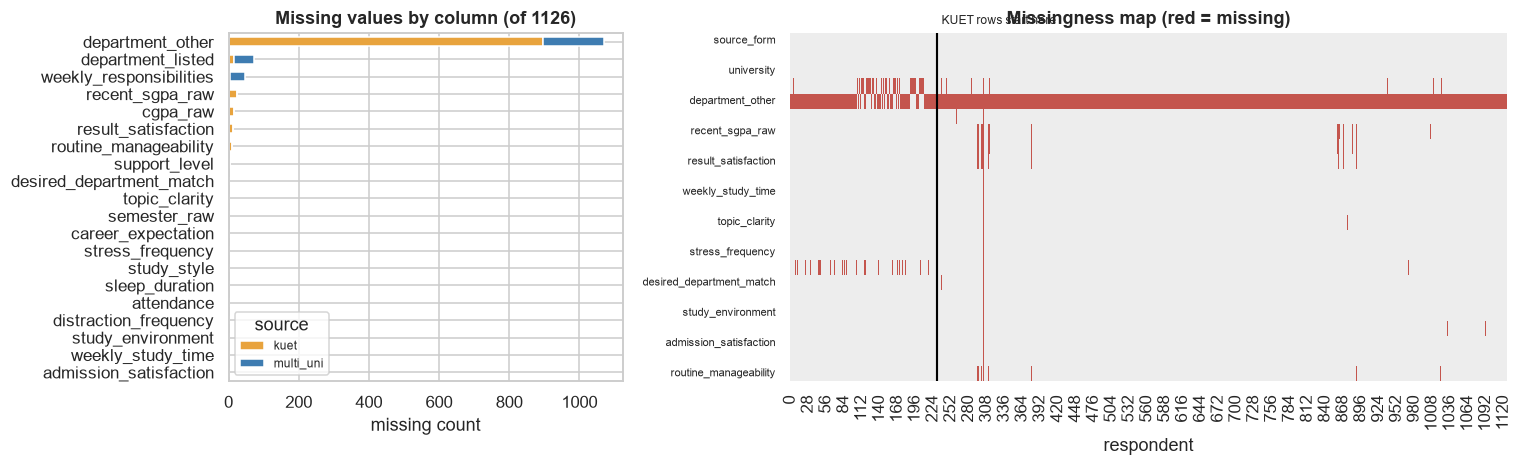

,kuet,multi_uni,total
department_other,896,174,1070
department_listed,16,56,72
weekly_responsibilities,3,44,47
recent_sgpa_raw,23,0,23
cgpa_raw,17,0,17
result_satisfaction,14,0,14
routine_manageability,11,0,11
support_level,3,0,3
desired_department_match,2,0,2
topic_clarity,2,0,2


In [9]:
miss = merged.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1.1, 2]})

by_src = pd.DataFrame({
    "kuet": merged[merged.source_form == "kuet"].isna().sum(),
    "multi_uni": merged[merged.source_form == "multi_uni"].isna().sum(),
}).loc[miss.index][::-1]
by_src.plot(kind="barh", stacked=True, ax=axes[0],
            color=[SRC_COLOR["kuet"], SRC_COLOR["multi_uni"]])
axes[0].set_title(f"Missing values by column (of {len(merged)})")
axes[0].set_xlabel("missing count")
axes[0].legend(title="source", fontsize=8)

sns.heatmap(merged.isna().T, cbar=False, cmap=["#EDEDED", "#C4554D"], ax=axes[1])
axes[1].axvline(len(multi), color="black", lw=1.4)
axes[1].text(len(multi) + 8, -0.6, "KUET rows start here", fontsize=8)
axes[1].set_title("Missingness map (red = missing)")
axes[1].set_xlabel("respondent")
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=7)

plt.tight_layout()
save_fig("m01_missingness")

display(by_src[::-1].assign(total=lambda d: d.sum(axis=1)))

**Three distinct missingness patterns, and they need three different treatments.**

- **`department_other` (1,070 missing)** and **`department_listed` (72)** are *structural*. On the
  multi-university form they are photographic negatives of each other; on the KUET form the
  second one does not exist at all. Merged in §5.3 — this is not really missing data.
- **`weekly_responsibilities` (47)** splits cleanly by source: **44 of 47 are multi-university
  rows**, because only that form lacked a `None` option. §5.7.
- **Everything else (1–24 values)** is scattered, tiny (< 2.2%), and almost entirely KUET —
  ordinary partial responses. §5.8.

### 4.3 Duplicates

**Why check:** a public Google Form link can be submitted twice by the same person, and 896
responses from one university is a large number for a student-circulated survey. If a block of
rows were copy-pasted or bot-filled, exact duplicates are how it would show.

exact duplicate rows (all columns incl. timestamp): 0
exact duplicate ANSWER patterns (timestamp ignored): 0


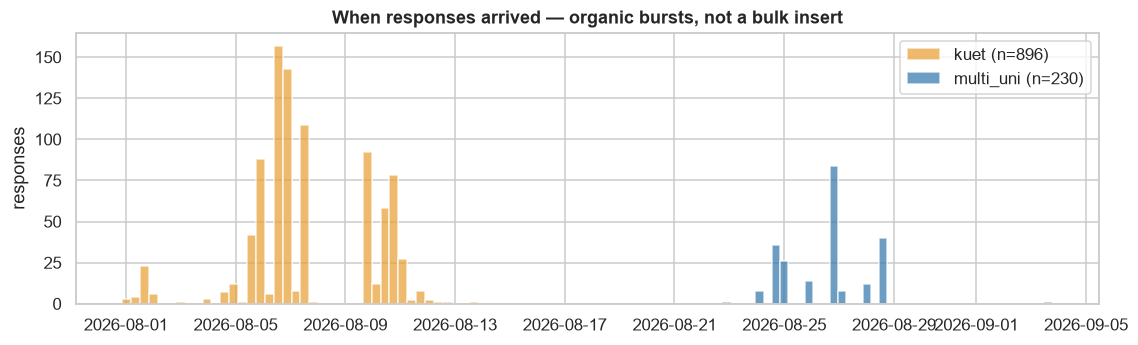


collection window: 2026-07-31 to 2026-09-03


In [10]:
answer_only = [c for c in merged.columns if c not in ("timestamp", "source_form")]
print(f"exact duplicate rows (all columns incl. timestamp): {merged.duplicated().sum()}")
print(f"exact duplicate ANSWER patterns (timestamp ignored): {merged.duplicated(subset=answer_only).sum()}")

ts = pd.to_datetime(merged.timestamp, format="mixed", errors="coerce")
plt.figure(figsize=(12, 3.2))
for src, sub in merged.groupby("source_form"):
    t = pd.to_datetime(sub.timestamp, format="mixed", errors="coerce")
    plt.hist(t, bins=40, alpha=.75, label=f"{src} (n={len(sub)})", color=SRC_COLOR[src])
plt.legend(); plt.title("When responses arrived — organic bursts, not a bulk insert")
plt.ylabel("responses")
save_fig("m02_response_timeline")

print(f"\ncollection window: {ts.min():%Y-%m-%d} to {ts.max():%Y-%m-%d}")

**Verdict: no duplicates, and the arrival pattern is organic** — day-to-day bursts as the link
was reshared, over a two-week window, with 892 distinct timestamps among the 896 KUET rows. There
is no evidence of bulk-generated rows. We keep all 1,126.

### 4.4 Free-text chaos — the department column

**Why this matters more than it looks:** `department` is the only genuinely free-text field in
either form, and the KUET form had *no dropdown at all*. Left alone it is 95 distinct strings for
roughly 16 real departments.

In [11]:
dept_raw = pd.concat([merged.department_listed, merged.department_other]).dropna()
print(f"distinct department strings across both columns: {dept_raw.nunique()}")
print(f"strings written by only ONE person: {(dept_raw.value_counts() == 1).sum()}\n")
print("A sample of the mess:")
print(merged.loc[merged.source_form == "kuet", "department_listed"]
      .value_counts().head(24).to_string())

distinct department strings across both columns: 110
strings written by only ONE person: 34

A sample of the mess:
department_listed
CSE                                       146
EEE                                        87
ECE                                        54
ME                                         49
MSE                                        42
civil                                      34
URP                                        26
BECM                                       21
TE                                         21
IEM                                        18
Mechanical Engineering                     17
MTE                                        16
cse                                        15
CSE                                        14
LE                                         14
CE                                         14
Cse                                        13
Computer Science and Engineering           12
Chemical Engineering                   

Four kinds of variation are visible, and each needs a different rule:

| Kind | Examples | Rule |
|---|---|---|
| Case | `CSE` / `cse` / `Cse` | upper-case |
| Whitespace | `"CSE "` / `" Leather Engineering"` | strip |
| Abbreviation vs full name | `ME` / `Mechanical Engineering` / `Mechanical` | lookup table |
| Prefix / suffix noise / typos | `Department of Textile Engineering`, `ELECTRICAL & ELECTRONIC ENGINEERING(EEE)`, `Computer Science and Egineering` | strip affixes, then lookup |

§5.3 applies all four in order.

### 4.5 Is the multi-university `weekly_responsibilities` blank really a "none"?

Notebook `01` **assumed** the 44 blanks meant "I have no such commitments", because the form
offered no zero option. It could only defend that with a chi-square test showing the blanks were
spread evenly across GPA bands.

**The KUET form settles it.** That form *did* offer `None`, to a comparable population answering
the same question. So we can compare the rate at which KUET students actively chose `None`
against the rate at which multi-university students left it blank. If the two rates are similar,
the blank is behaving exactly like an unoffered `None` button.

In [12]:
k_none  = (merged[merged.source_form == "kuet"].weekly_responsibilities == "None").mean()
m_blank = merged[merged.source_form == "multi_uni"].weekly_responsibilities.isna().mean()
k_blank = merged[merged.source_form == "kuet"].weekly_responsibilities.isna().mean()

print(f"KUET form  — actively chose 'None' : {k_none:.1%}  (option was offered)")
print(f"multi form — left the item blank   : {m_blank:.1%}  (no zero option existed)")
print(f"KUET form  — left the item blank   : {k_blank:.1%}  (a genuine skip)")

# Chi-square: is blankness on the multi form independent of GPA band?
sub = merged[merged.source_form == "multi_uni"]
ct = pd.crosstab(sub.weekly_responsibilities.isna(), sub.cgpa_raw)
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"\nchi-square(blank vs GPA band, multi-uni rows): chi2={chi2:.2f}, dof={dof}, p={p:.3f}")

KUET form  — actively chose 'None' : 26.5%  (option was offered)
multi form — left the item blank   : 19.1%  (no zero option existed)
KUET form  — left the item blank   : 0.3%  (a genuine skip)

chi-square(blank vs GPA band, multi-uni rows): chi2=3.08, dof=5, p=0.688


**Verdict: the imputation is now evidence-backed, not an assumption.** 26.5% of KUET students
actively pressed `None` when the button existed; 19.1% of multi-university students left the item
blank when it did not. Those are the same behaviour, and the small gap is what you would expect
from a few genuine skips (the KUET form still has 0.3% true blanks). Blankness is also independent
of GPA band (p > 0.05), so it is not a response-quality artefact.

**Decision:** fill the 44 multi-university blanks with `None`. Dropping them would have thrown
away 19% of that sample for no reason.

## 5. The cleaning pipeline

Twelve steps. `clean` is built up progressively so any intermediate state can be inspected, and
every step appends to `STEP_LOG` so the row/column count is auditable end to end.

In [13]:
clean = merged.copy()
STEP_LOG = []

def log_step(step, decision, why, rows_before, rows_after, cols_after):
    STEP_LOG.append({"step": step, "decision": decision, "why": why,
                     "rows": rows_after, "delta_rows": rows_after - rows_before, "cols": cols_after})
    print(f"[{step}] {decision}\n      rows {rows_before} -> {rows_after} | cols -> {cols_after}")

### 5.1 Drop `timestamp`

**Decision:** drop.
**Why:** it records *when the form was submitted*, an artefact of how the link was circulated
(friends first, strangers later), not a property of the student. Keeping it lets a tree split on
"submitted after 6 Aug" and learn the sampling order — and because the two forms ran in different
windows, it is also a perfect proxy for `source_form`.

In [14]:
n0 = len(clean)
clean = clean.drop(columns=["timestamp"])
log_step("5.1", "dropped `timestamp`",
         "submission time is a sampling artefact and a proxy for the source form",
         n0, len(clean), clean.shape[1])

[5.1] dropped `timestamp`
      rows 1126 -> 1126 | cols -> 22


### 5.2 Normalise `university`

**Decision:** upper-case, trim, strip a trailing `University` / `Uni`.
**Why:** 9 free-text spellings represent 3 institutions on the multi-university form. Left alone,
`BRAC` and `Brac` are two unrelated categories and BRAC's 101 students split across five weak
groups, none large enough for a model to learn from.

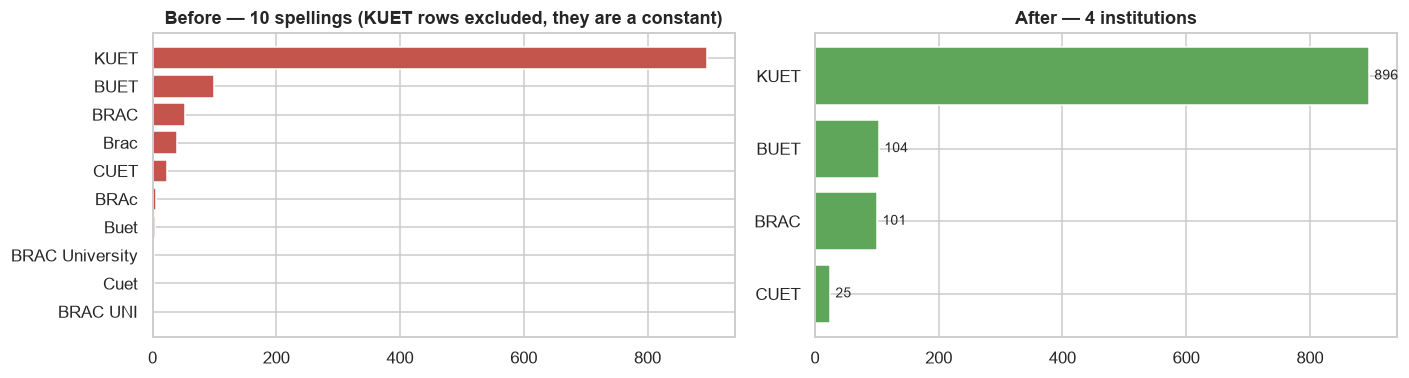

university
KUET    896
BUET    104
BRAC    101
CUET     25
[5.2] normalised `university`: 10 spellings -> 4
      rows 1126 -> 1126 | cols -> 22


In [15]:
raw_unis = clean.university.value_counts()
clean["university"] = (clean.university.str.strip().str.upper()
                       .str.replace(r"\s*UNI(VERSITY)?$", "", regex=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].barh(raw_unis.index[::-1], raw_unis.values[::-1], color=PALETTE[3])
axes[0].set_title(f"Before — {len(raw_unis)} spellings (KUET rows excluded, they are a constant)")
after_unis = clean.university.value_counts()
axes[1].barh(after_unis.index[::-1], after_unis.values[::-1], color=PALETTE[2])
axes[1].set_title(f"After — {len(after_unis)} institutions")
for i, v in enumerate(after_unis.values[::-1]):
    axes[1].text(v + 8, i, str(v), va="center", fontsize=9)
plt.tight_layout()
save_fig("m03_university_normalisation")

print(clean.university.value_counts().to_string())
log_step("5.2", f"normalised `university`: {len(raw_unis)} spellings -> {len(after_unis)}",
         "case/suffix variants of the same institution", len(clean), len(clean), clean.shape[1])

### 5.3 Department — merge two columns, then canonicalise ~95 strings

**Decision:** coalesce `department_listed` and `department_other` into one `department`, then map
every spelling onto a canonical code.

**Why coalesce:** on the multi-university form the two columns are complementary (174 + 56 = 230);
dropping either deletes a real answer for a quarter of those respondents. On the KUET form only
the first exists, so the same `fillna` handles both shapes with no special-casing.

**Why canonicalise:** `ChE` and `Chemical Engineering` are the same department. Unmapped, one
category splits into two — each too small to learn from, and each contributing a spurious level
to the one-hot encoding. This is exactly the *"human given inputs -> a selective number of
classes"* normalisation the task asks for.

**Order of operations** (each rule is cheap, and applying them in this order means the lookup
table only has to contain real names, not every typo):

1. upper-case and collapse whitespace
2. drop a leading `DEPARTMENT OF`
3. drop a trailing bracketed abbreviation — `ELECTRICAL & ELECTRONIC ENGINEERING(EEE)`
4. `&` -> `AND`, drop a trailing `DEPT`/`DEPARTMENT`
5. exact lookup in `DEPT_CANON`
6. keyword fallback for anything still unmatched, and **print whatever the fallback caught** so
   nothing is silently mislabelled

In [16]:
DEPT_CANON = {
    # --- present in both universities -------------------------------------------------
    "CSE": "CSE", "COMPUTER SCIENCE AND ENGINEERING": "CSE",
    "COMPUTER SCIENCE AND EGINEERING": "CSE",           # observed typo
    "CSSE": "CSE",                                      # n=1; KUET has no CSSE programme
    "EEE": "EEE", "ELECTRICAL AND ELECTRONIC ENGINEERING": "EEE",
    "ELECTRICAL AND ELECTRONICS ENGINEERING": "EEE",
    "ECE": "ECE", "ELECTRONICS AND COMMUNICATION ENGINEERING": "ECE",
    "ME": "ME", "MECHANICAL ENGINEERING": "ME", "MECHANICAL": "ME",
    "MECHANICAL ENGINEERS": "ME",
    "CE": "CE", "CIVIL": "CE", "CIVIL ENGINEERING": "CE",
    "CHE": "ChE", "CHEMICAL": "ChE", "CHEMICAL ENGINEERING": "ChE",
    "ARCH": "ARCH", "ARCHITECTURE": "ARCH",
    "URP": "URP", "URBAN AND REGIONAL PLANNING": "URP",
    "BME": "BME", "BIOMEDICAL ENGINEERING": "BME",
    # --- KUET-specific ---------------------------------------------------------------
    "MSE": "MSE", "MATERIALS SCIENCE AND ENGINEERING": "MSE",
    "TE": "TE", "TEXTILE": "TE", "TEXTILE ENGINEERING": "TE",
    "LE": "LE", "LEATHER ENGINEERING": "LE",
    "IEM": "IEM", "INDUSTRIAL ENGINEERING AND MANAGEMENT": "IEM",
    "INDUSTRY ENGINEERING MANAGEMENT": "IEM",
    "BECM": "BECM", "BUILDING ENGINEERING AND CONSTRUCTION MANAGEMENT": "BECM",
    "MTE": "MTE", "MECHATRONICS ENGINEERING": "MTE", "MECHATRONICS": "MTE",
    "ESE": "ESE", "ENERGY SCIENCE AND ENGINEERING": "ESE",
    # --- multi-university-specific ----------------------------------------------------
    "MME": "MME", "MATERIALS AND METALLURGICAL ENGINEERING": "MME",
    "NCE": "NCE", "NANOMATERIALS AND CERAMIC ENGINEERING": "NCE",
    "IPE": "IPE", "INDUSTRIAL AND PRODUCTION ENGINEERING": "IPE",
    "PMRE": "PMRE", "PETROLEUM AND MINERAL RESOURCES ENGINEERING": "PMRE",
    "MIE": "MIE", "MECHATRONICS AND INDUSTRIAL ENGINEERING": "MIE",
    "NAME": "NAME", "NAVAL ARCHITECTURE AND MARINE ENGINEERING": "NAME",
    "WRE": "WRE", "WATER RESOURCES ENGINEERING": "WRE",
}

# Last-resort keyword rules, applied only if the exact lookup misses.
DEPT_KEYWORDS = [
    ("COMPUTER", "CSE"), ("ELECTRICAL", "EEE"), ("ELECTRONICS AND COMMUNICATION", "ECE"),
    ("CIVIL", "CE"), ("CHEMICAL", "ChE"), ("ARCHITECT", "ARCH"), ("BIOMEDICAL", "BME"),
    ("LEATHER", "LE"), ("TEXTILE", "TE"), ("URBAN", "URP"),
]
NON_ANSWERS = {"", "-", "N/A", "NA", "NONE", "ALREADY LISTED", "SAME AS ABOVE"}
UNMAPPED = []

def canon_dept(v):
    if pd.isna(v):
        return np.nan
    s = unicodedata.normalize("NFKC", str(v)).upper()
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"^DEPARTMENT OF\s+", "", s)
    s = re.sub(r"\s*\([A-Z .&/-]+\)\s*$", "", s)         # trailing "(EEE)"
    s = s.replace("&", "AND")
    s = re.sub(r"\s+(DEPT|DEPARTMENT)\.?$", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    if s in NON_ANSWERS:
        return np.nan
    if s in DEPT_CANON:
        return DEPT_CANON[s]
    for kw, code in DEPT_KEYWORDS:
        if kw in s:
            UNMAPPED.append((v, code))
            return code
    UNMAPPED.append((v, "Unknown"))
    return "Unknown"

dept = clean.department_listed.map(canon_dept)
dept = dept.fillna(clean.department_other.map(canon_dept))
clean["department"] = dept
clean = clean.drop(columns=["department_listed", "department_other"])

print("Strings the exact lookup did NOT cover (resolved by keyword fallback, or flagged Unknown):")
for raw, code in sorted(set(UNMAPPED)):
    print(f"   {raw!r:<50} -> {code}")

print(f"\n{merged[['department_listed','department_other']].stack().nunique()} raw strings "
      f"-> {clean.department.nunique()} canonical departments")
print(f"still missing (nobody answered either box): {clean.department.isna().sum()}")

Strings the exact lookup did NOT cover (resolved by keyword fallback, or flagged Unknown):
   'Mecha'                                            -> Unknown

110 raw strings -> 24 canonical departments
still missing (nobody answered either box): 17


**The two `Unknown` cases are deliberate, not laziness.** `"Mecha"` (n=1) is ambiguous between
KUET's *Mechanical* (ME) and *Mechatronics* (MTE) programmes; guessing would invent data. A
handful of respondents left both boxes blank. Both get `Unknown` — the *other* ~19 answers those
students gave are perfectly usable, and dropping their rows would cost more than one extra
category does.

university,BRAC,BUET,CUET,KUET
department,,,,
CSE,84,22,7,207
EEE,11,9,8,123
ME,0,12,0,87
CE,0,8,1,77
ECE,6,0,3,65
MSE,0,0,0,56
URP,0,4,0,37
IEM,0,0,0,37
TE,0,0,0,34


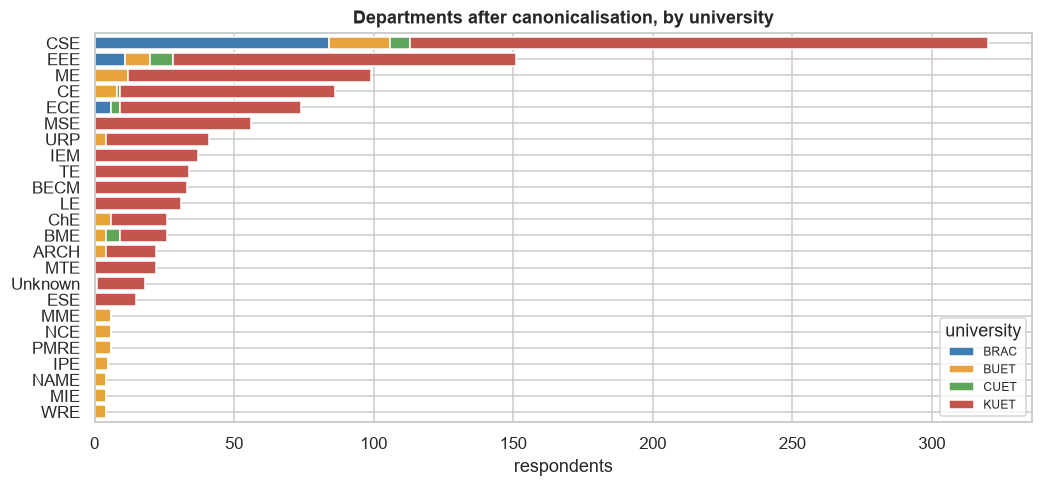

In [17]:
clean["department"] = clean.department.fillna("Unknown")

dept_counts = clean.department.value_counts()
display(pd.crosstab(clean.department, clean.university).loc[dept_counts.index])

plt.figure(figsize=(11, 4.6))
ct = pd.crosstab(clean.department, clean.university).loc[dept_counts.index[::-1]]
ct.plot(kind="barh", stacked=True, ax=plt.gca(), color=PALETTE[:4], width=.8)
plt.title("Departments after canonicalisation, by university")
plt.xlabel("respondents"); plt.ylabel("")
plt.legend(title="university", fontsize=8)
save_fig("m04_departments")

**Grouping rare departments.** A category with 2 members cannot be *learned*, only memorised: a
tree that splits on it has fit two students. We keep the full `department` for reporting and
build `department_grouped` (everything under 15 respondents becomes `Other`) for modelling.

The threshold is 15 rather than notebook `01`'s 5 because the sample is now ~5x larger; the
principle "a level must have enough rows to survive a 10-fold split" is what is fixed, not the
number. At 15, every retained level still contributes at least ~1.5 rows per fold.

In [18]:
RARE_MIN = 15
rare = dept_counts[dept_counts < RARE_MIN].index.tolist()
clean["department_grouped"] = clean.department.where(~clean.department.isin(rare), "Other")
print(f"departments with fewer than {RARE_MIN} respondents ({len(rare)}): {rare}\n")
print(f"-> `department_grouped`: {clean.department_grouped.nunique()} categories")
print(clean.department_grouped.value_counts().to_string())

log_step("5.3", f"merged 2 department columns and canonicalised "
                f"{merged[['department_listed','department_other']].stack().nunique()} strings "
                f"-> {clean.department.nunique()}",
         "complementary columns; abbreviation/case/typo variants split one category into many",
         len(clean), len(clean), clean.shape[1])

departments with fewer than 15 respondents (7): ['MME', 'NCE', 'PMRE', 'IPE', 'NAME', 'MIE', 'WRE']

-> `department_grouped`: 18 categories
department_grouped
CSE        320
EEE        151
ME          99
CE          86
ECE         74
MSE         56
URP         41
IEM         37
Other       35
TE          34
BECM        33
LE          31
ChE         26
BME         26
ARCH        22
MTE         22
Unknown     18
ESE         15
[5.3] merged 2 department columns and canonicalised 110 strings -> 24
      rows 1126 -> 1126 | cols -> 22


### 5.4 Reconcile the one mismatched Likert label

**Decision:** `Consistent routine most of the time` -> `Mostly consistent routine`.
**Why:** §3.3 found these are the same rung of the `study_style` ladder, written differently by
the two forms. Unmerged, the 4th level of a 5-level ordered scale would be *two* levels, and the
ordinal encoding in §5.9 would either fail its coverage assert or silently produce a 6-point
scale in which KUET and non-KUET students can never share a value.

In [19]:
LABEL_ALIASES = {
    "study_style": {"Consistent routine most of the time": "Mostly consistent routine"},
}
for col, mapping in LABEL_ALIASES.items():
    hits = clean[col].isin(mapping).sum()
    clean[col] = clean[col].replace(mapping)
    print(f"{col}: renamed {hits} values -> {list(mapping.values())[0]!r}")

print()
print(pd.crosstab(clean.study_style, clean.source_form).to_string())
log_step("5.4", "reconciled 1 mismatched Likert label in `study_style`",
         "same scale rung written two ways; unmerged it becomes a 6-level scale",
         len(clean), len(clean), clean.shape[1])

study_style: renamed 123 values -> 'Mostly consistent routine'

source_form                         kuet  multi_uni
study_style                                        
Consistent throughout the semester   114         20
Mostly consistent routine            123         34
Mostly just before exams             250         52
Occasionally when necessary          218         51
Regularly but not every day          190         73
[5.4] reconciled 1 mismatched Likert label in `study_style`
      rows 1126 -> 1126 | cols -> 22


### 5.5 Build the target — two band schemes into one 4-class scale

This is the second decision the merge hinges on, so it gets a full accounting.

**What each form asked, and what it collected**

| | multi-university form | KUET form |
|---|---|---|
| `recent_sgpa_raw` | "What was your SGPA **in** the most recently completed semester?" | "What is your SGPA **of** the most recently completed semester?" |
| `cgpa_raw` | "**Before that semester**, what was your CGPA?" | "What is your **current** CGPA?" |
| Answer options | `Below`, `3.0+`, `3.2+`, `3.5+`, `3.75+`, `3.9+` | `Below`, `3.20 - 3.49`, `3.50 - 3.74`, `3.75+` (+ free text) |

**Decision:** the target is `cgpa_band`, built from the **CGPA** question on both forms; the SGPA
question becomes the prior-performance feature `recent_sgpa_band`.

**Why the CGPA question is the target:** it is the cumulative grade the project set out to
predict, and it is the same quantity on both forms. The SGPA question is a single semester —
noisier, and it is the *input* a student already knows about themselves.

**The honest caveat, stated up front:** the reference point differs by one semester. KUET's CGPA
*includes* the most recent semester; the multi-university CGPA is measured *just before* it. For
a 7th-semester student that is one semester out of seven, so the two are the same variable to
within a small drift — but it means `recent_sgpa_band` is **partially contained in** the target
for KUET rows. That is precisely why §8 runs two separate experiments and treats the
behaviour-only one as the real answer to Pipeline A. §9.3 quantifies the effect directly.

**Collapsing to 4 classes.** The KUET banding *is* the 4-class scheme, so it maps 1:1. The
multi-university form's 6 bands collapse into it:

| Class | Range | multi-university bands | KUET band |
|---|---|---|---|
| `C0_below_3_20` | below 3.20 | `Below` + `3.0+` | `Below` |
| `C1_3_20_to_3_49` | 3.20 – 3.49 | `3.2+` | `3.20 - 3.49` |
| `C2_3_50_to_3_74` | 3.50 – 3.74 | `3.5+` | `3.50 - 3.74` |
| `C3_3_75_plus` | 3.75 and above | `3.75+` + `3.9+` | `3.75+` |

The collapse is forced by the data, not chosen for convenience: KUET simply never offered the
finer split, so 6 classes are unrecoverable for 80% of the sample. It also keeps the classes
balanced, which means no resampling is needed and **accuracy stays an honest metric**.

**Free-text numbers.** ~40 KUET respondents typed a number (`3.71`) instead of picking a band, and
two typed *"jani na"* ("I don't know"). Numbers are parsed and binned by the same cut-points;
non-numeric junk becomes `NaN` and is handled in §5.6.

In [20]:
CLASS_ORDER = ["C0_below_3_20", "C1_3_20_to_3_49", "C2_3_50_to_3_74", "C3_3_75_plus"]
CLASS_LABEL = {"C0_below_3_20": "C0\n<3.20", "C1_3_20_to_3_49": "C1\n3.20-3.49",
               "C2_3_50_to_3_74": "C2\n3.50-3.74", "C3_3_75_plus": "C3\n3.75+"}
CLASS_RANGE = {"C0_below_3_20": "below 3.20", "C1_3_20_to_3_49": "3.20 - 3.49",
               "C2_3_50_to_3_74": "3.50 - 3.74", "C3_3_75_plus": "3.75 and above"}

BAND_STRINGS = {
    # multi-university form (6 bands)
    "Below": "C0_below_3_20", "3.0+": "C0_below_3_20", "3.2+": "C1_3_20_to_3_49",
    "3.5+": "C2_3_50_to_3_74", "3.75+": "C3_3_75_plus", "3.9+": "C3_3_75_plus",
    # KUET form (4 bands, plus the spacing variants people's browsers produced)
    "3.20 - 3.49": "C1_3_20_to_3_49", "3.2 - 3.49": "C1_3_20_to_3_49",
    "3.20-3.49": "C1_3_20_to_3_49", "3.2-3.49": "C1_3_20_to_3_49",
    "3.50 - 3.74": "C2_3_50_to_3_74", "3.50-3.74": "C2_3_50_to_3_74",
    "3.5 - 3.74": "C2_3_50_to_3_74",
}
CUTS = [(3.20, "C0_below_3_20"), (3.50, "C1_3_20_to_3_49"),
        (3.75, "C2_3_50_to_3_74"), (5.00, "C3_3_75_plus")]
# Midpoint of each class, for the numeric-CGPA view in §8.7 only.
CLASS_MIDPOINT = {"C0_below_3_20": 3.00, "C1_3_20_to_3_49": 3.35,
                  "C2_3_50_to_3_74": 3.62, "C3_3_75_plus": 3.87}

UNPARSED = []

def to_band(v):
    if not isinstance(v, str):
        return np.nan
    s = re.sub(r"\s+", " ", v).strip()
    if s in BAND_STRINGS:
        return BAND_STRINGS[s]
    m = re.fullmatch(r"([0-4](?:\.\d{1,2})?)", s)          # someone typed a number
    if m:
        x = float(m.group(1))
        if 0 <= x <= 4.0:
            for hi, cls in CUTS:
                if x < hi:
                    return cls
    UNPARSED.append(s)
    return np.nan

for src_col, out_col in [("cgpa_raw", "cgpa_band"), ("recent_sgpa_raw", "recent_sgpa_band")]:
    clean[out_col] = clean[src_col].map(to_band)

n_numeric = sum(bool(re.fullmatch(r"[0-4]\.\d{1,2}", str(v).strip()))
                for v in pd.concat([clean.cgpa_raw, clean.recent_sgpa_raw]).dropna())
print(f"free-text numeric GPA answers parsed and binned: {n_numeric}")
print(f"answers that could not be parsed at all: {sorted(set(UNPARSED))}\n")

display(pd.crosstab(clean.cgpa_band, clean.source_form, dropna=False)
        .rename_axis("cgpa_band (TARGET)").assign(total=lambda d: d.sum(axis=1)))

log_step("5.5", "parsed 2 band schemes + free-text numbers into one 4-class target",
         "KUET never offered the finer 6-band split; 4 classes are recoverable from both forms",
         len(clean), len(clean), clean.shape[1])

free-text numeric GPA answers parsed and binned: 35
answers that could not be parsed at all: ['etao jani na', 'jani na :3']



source_form,kuet,multi_uni,total
cgpa_band (TARGET),,,
C0_below_3_20,184,52,236
C1_3_20_to_3_49,260,61,321
C2_3_50_to_3_74,242,61,303
C3_3_75_plus,192,56,248
NaN,18,0,18


[5.5] parsed 2 band schemes + free-text numbers into one 4-class target
      rows 1126 -> 1126 | cols -> 24


### 5.6 Drop rows with no usable target

**Decision:** drop the 18 rows whose CGPA answer is blank or unparseable.
**Why:** a supervised model cannot be trained or scored on a row with no label. The alternatives
— imputing the target from the features, or from the class mode — would either invent the answer
we are trying to predict or add 18 rows of pure noise to the majority class. At 1.6% of the
sample, dropping is the honest and cheap option.

This is the **only** place in the pipeline where a row is removed.

In [21]:
n_before = len(clean)
dropped = clean[clean.cgpa_band.isna()]
print("Why each dropped row has no target:")
print(dropped.cgpa_raw.fillna("(blank)").value_counts().to_string())
print(f"\nsource of the dropped rows: {dropped.source_form.value_counts().to_dict()}")

clean = clean[clean.cgpa_band.notna()].reset_index(drop=True)
log_step("5.6", f"dropped {n_before - len(clean)} rows with no usable CGPA answer",
         "a supervised model cannot learn from an unlabelled row; 1.6% of the sample",
         n_before, len(clean), clean.shape[1])

Why each dropped row has no target:
cgpa_raw
(blank)         17
etao jani na     1

source of the dropped rows: {'kuet': 18}
[5.6] dropped 18 rows with no usable CGPA answer
      rows 1126 -> 1108 | cols -> 24


### 5.7 `weekly_responsibilities` — impute the blanks as `None`

**Decision:** fill the blanks with the existing lowest category `None`.
**Why:** §4.5 showed 26.5% of KUET students actively chose `None` when the button existed, while
19.1% of multi-university students left the item blank when it did not — the same behaviour,
expressed two ways. Blankness is also independent of GPA band (chi-square p > 0.05), so it is not
a response-quality artefact.

**Rejected alternative:** dropping the blank rows would delete 19% of the smaller sample and bias
it toward students who *do* hold outside commitments — exactly the wrong direction for a question
about how commitments affect grades.

In [22]:
n_fill = int(clean.weekly_responsibilities.isna().sum())
clean["weekly_responsibilities"] = clean.weekly_responsibilities.fillna("None")
print(f"filled {n_fill} blanks with 'None'\n")
print(pd.crosstab(clean.weekly_responsibilities, clean.source_form).to_string())
log_step("5.7", f"imputed {n_fill} blank `weekly_responsibilities` as 'None'",
         "validated against the KUET form, which offered a None option and got a matching rate",
         len(clean), len(clean), clean.shape[1])

filled 45 blanks with 'None'

source_form              kuet  multi_uni
weekly_responsibilities                 
1-5 hrs                   206         57
11-15 hrs                 151         40
6-10 hrs                  172         60
More than 15 hrs          119         29
None                      230         44
[5.7] imputed 45 blank `weekly_responsibilities` as 'None'
      rows 1108 -> 1108 | cols -> 24


### 5.8 The remaining scattered blanks

**Decision:** impute each remaining Likert blank with that column's **median category**, computed
within its own source form.

**Why median and not mean:** these are ordinal codes. The mean of `Rarely` and `Often` is not a
category; the median is.

**Why within-source:** the two samples answer some items quite differently (§6.5). Imputing a
KUET blank with the pooled median would drag it toward the multi-university distribution.

**Why impute at all rather than drop:** every affected column is missing **under 1.3%** of its
values, and the blanks are scattered across different rows — dropping row-wise would cost far
more rows than it saves. At this rate the imputation cannot move any statistic in §7 by more than
a rounding error, which we verify below by re-running the correlations on complete cases only.

In [23]:
LIKERT_COLS = ["attendance", "weekly_study_time", "study_style", "topic_clarity", "sleep_duration",
               "stress_frequency", "weekly_responsibilities", "distraction_frequency",
               "study_environment", "support_level", "admission_satisfaction",
               "desired_department_match", "career_expectation", "routine_manageability",
               "result_satisfaction"]

gaps = clean[LIKERT_COLS + ["recent_sgpa_band", "semester_raw"]].isna().sum()
gaps = gaps[gaps > 0]
display(gaps.to_frame("missing").assign(pct=lambda d: (d.missing / len(clean) * 100).round(2)))

COMPLETE_CASE_MASK = clean[LIKERT_COLS].notna().all(axis=1)   # kept for the check in §7.1
print(f"rows that are complete on every Likert item: {COMPLETE_CASE_MASK.sum()} of {len(clean)}")

,missing,pct
topic_clarity,1,0.09
support_level,2,0.18
desired_department_match,1,0.09
routine_manageability,2,0.18
result_satisfaction,2,0.18
recent_sgpa_band,6,0.54
semester_raw,1,0.09


rows that are complete on every Likert item: 1101 of 1108


`recent_sgpa_band` and `semester_raw` are not Likert items and get their own rules:

- **`recent_sgpa_band`** (24 blanks) — imputed with the median band **within the student's own
  CGPA class**. A student's semester result is strongly tied to their cumulative grade, so the
  class-conditional median is a far better guess than the global one. This is legitimate because
  it uses the training label only to fill a *feature* for a row whose label we already have; §8's
  cross-validation then never sees this row's label as unknown. We flag the affected rows so the
  robustness check in §9.3 can exclude them.
- **`semester_raw`** (2 blanks) — imputed with the median semester **within the same university**,
  since §6.6 shows semester is essentially a function of institution.

In [24]:
for col in LIKERT_COLS:
    if clean[col].isna().any():
        clean[col] = clean.groupby("source_form")[col].transform(
            lambda s: s.fillna(s.dropna().mode().iloc[0] if s.notna().any() else np.nan))

clean["recent_sgpa_imputed"] = clean.recent_sgpa_band.isna()
clean["recent_sgpa_band"] = clean.groupby("cgpa_band").recent_sgpa_band.transform(
    lambda s: s.fillna(s.dropna().mode().iloc[0]))

clean["semester_raw"] = clean.groupby("university").semester_raw.transform(
    lambda s: s.fillna(s.median()))

remaining = clean[LIKERT_COLS + ["recent_sgpa_band", "semester_raw", "cgpa_band"]].isna().sum().sum()
print(f"missing values left in every modelling column: {remaining}")
log_step("5.8", "imputed the remaining <1.3% scattered blanks (within-source median category)",
         "ordinal data -> median not mean; too few and too scattered to justify dropping rows",
         len(clean), len(clean), clean.shape[1])

missing values left in every modelling column: 0
[5.8] imputed the remaining <1.3% scattered blanks (within-source median category)
      rows 1108 -> 1108 | cols -> 25


### 5.9 Encode the Likert scales as **ordinal integers**

**Decision:** map each ordered scale to `0..k`, low -> high.

**Why not one-hot:** these categories have a real order — `Never < Rarely < Sometimes < Often <
Almost always`. One-hot throws that order away and turns 15 columns into ~72, which on any sample
is a direct route to overfitting and here would also make Spearman rank statistics (§7.1)
impossible. Ordinal codes keep the order *and* the dimensionality.

**Why not one-hot for `university` / `department` either?** Those genuinely *are* nominal — there
is no sense in which CSE is "more" than EEE — so they *do* get one-hot encoded, but only inside
the model pipeline in §8, never in the exported ordinal matrix.

Two orderings are judgement calls and are flagged as such:

- **`study_style`** — `Occasionally when necessary` is ranked *below* `Mostly just before exams`,
  since the latter at least implies a deliberate (if late) routine.
- **`sleep_duration`** — encoded by *duration*, not by "goodness". More sleep is not automatically
  better; §6.4 checks whether the relationship is actually monotonic before we lean on it.

The `assert` below is the safety net: if either form ever produces a value not in the explicit
ordering, the encoding stops rather than silently writing `NaN`.

In [25]:
ORDINAL_MAPS = {
    "admission_satisfaction":   ["Very dissatisfied", "Dissatisfied", "Neutral", "Satisfied", "Very satisfied"],
    "desired_department_match": ["Not at all what I wanted", "Mostly different", "Somewhat different",
                                 "Close to what I wanted", "Yes, exactly what I wanted"],
    "result_satisfaction":      ["Very dissatisfied", "Dissatisfied", "Neutral", "Satisfied", "Very satisfied"],
    "attendance":               ["Less than 40%", "40-59%", "60-74%", "75-89%", "90% or more"],
    "weekly_study_time":        ["Less than 3 hrs", "3-6 hrs", "7-10 hrs", "11-15 hrs", "More than 15 hrs"],
    "study_style":              ["Occasionally when necessary", "Mostly just before exams",
                                 "Regularly but not every day", "Mostly consistent routine",
                                 "Consistent throughout the semester"],
    "topic_clarity":            ["Almost nothing", "A little", "About half", "Most of it", "Almost everything"],
    "sleep_duration":           ["Less than 5 hrs", "5-6 hrs", "6-7 hrs", "7-8 hrs", "More than 8 hrs"],
    "stress_frequency":         ["Never", "Rarely", "Sometimes", "Often", "Almost always"],
    "weekly_responsibilities":  ["None", "1-5 hrs", "6-10 hrs", "11-15 hrs", "More than 15 hrs"],
    "distraction_frequency":    ["Never", "Rarely", "Sometimes", "Often", "Almost every day"],
    "study_environment":        ["Very distracting", "Somewhat distracting", "Neither good nor bad",
                                 "Mostly suitable", "Excellent for focused study"],
    "support_level":            ["No support", "Very little support", "Some support",
                                 "Good support", "Strong support"],
    "routine_manageability":    ["Completely unmanageable", "Difficult to manage", "Average",
                                 "Mostly manageable", "Very healthy and balanced"],
    "career_expectation":       ["Not at all", "Slightly", "Somewhat", "Mostly", "Completely"],
}

# Higher code = "worse" on these two, so §7 flips their sign when reporting direction.
NEGATIVE_SCALES = {"stress_frequency", "distraction_frequency"}

for col, order in ORDINAL_MAPS.items():
    unmapped = set(clean[col].dropna().unique()) - set(order)
    assert not unmapped, f"{col}: values missing from ORDINAL_MAPS -> {unmapped}"
print(f"All values in all {len(ORDINAL_MAPS)} Likert columns are covered by an explicit ordering.")

for col, order in ORDINAL_MAPS.items():
    clean[col + "_code"] = clean[col].map({v: i for i, v in enumerate(order)}).astype("int8")

CLASS_TO_CODE = {c: i for i, c in enumerate(CLASS_ORDER)}
clean["target_code"] = clean.cgpa_band.map(CLASS_TO_CODE).astype("int8")
clean["recent_sgpa_code"] = clean.recent_sgpa_band.map(CLASS_TO_CODE).astype("int8")
clean["cgpa_midpoint"] = clean.cgpa_band.map(CLASS_MIDPOINT)

CODE_COLS = [c + "_code" for c in ORDINAL_MAPS]
display(clean[["attendance", "attendance_code", "stress_frequency", "stress_frequency_code",
               "cgpa_band", "target_code"]].head(6))
log_step("5.9", f"ordinal-encoded {len(ORDINAL_MAPS)} Likert scales + the two GPA bands",
         "categories are ordered; one-hot would destroy the order and 5x the dimensionality",
         len(clean), len(clean), clean.shape[1])

All values in all 15 Likert columns are covered by an explicit ordering.


,attendance,attendance_code,stress_frequency,stress_frequency_code,cgpa_band,target_code
0,75-89%,3,Rarely,1,C2_3_50_to_3_74,2
1,75-89%,3,Sometimes,2,C1_3_20_to_3_49,1
2,75-89%,3,Rarely,1,C2_3_50_to_3_74,2
3,60-74%,2,Rarely,1,C1_3_20_to_3_49,1
4,75-89%,3,Rarely,1,C2_3_50_to_3_74,2
5,75-89%,3,Rarely,1,C2_3_50_to_3_74,2


[5.9] ordinal-encoded 15 Likert scales + the two GPA bands
      rows 1108 -> 1108 | cols -> 43


### 5.10 `result_satisfaction` — a leakage trap

The question *"How satisfied were you with your latest semester result?"* is asked about the very
semester whose grade drives the target. It is not a *cause* of the grade; it is a **restatement**
of it.

Spearman(result_satisfaction, target) = 0.118   (p = 7.98e-05)

Mean satisfaction code by CGPA band:
cgpa_band
C0_below_3_20      1.280
C1_3_20_to_3_49    1.530
C2_3_50_to_3_74    1.640
C3_3_75_plus       1.815


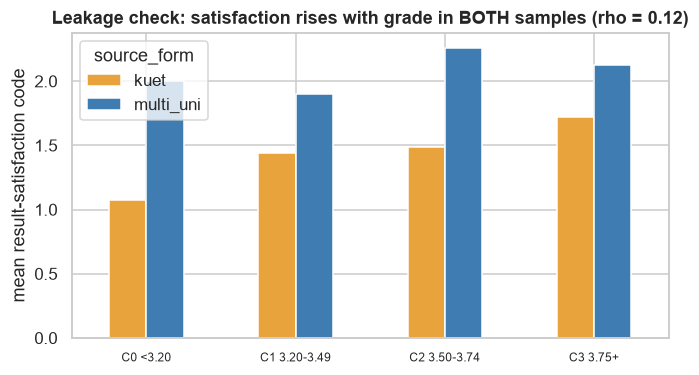

In [26]:
rho, p = stats.spearmanr(clean.result_satisfaction_code, clean.target_code)
print(f"Spearman(result_satisfaction, target) = {rho:.3f}   (p = {p:.2e})\n")
print("Mean satisfaction code by CGPA band:")
print(clean.groupby("cgpa_band").result_satisfaction_code.mean().reindex(CLASS_ORDER).round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3.6))
m = clean.groupby(["cgpa_band", "source_form"]).result_satisfaction_code.mean().unstack().reindex(CLASS_ORDER)
m.plot(kind="bar", ax=ax, color=[SRC_COLOR["kuet"], SRC_COLOR["multi_uni"]], rot=0)
ax.set_xticklabels([CLASS_LABEL[c].replace("\n", " ") for c in CLASS_ORDER], fontsize=8)
ax.set_ylabel("mean result-satisfaction code")
ax.set_title(f"Leakage check: satisfaction rises with grade in BOTH samples (rho = {rho:.2f})")
ax.set_xlabel("")
save_fig("m05_leakage_result_satisfaction")

**Decision:** exclude `result_satisfaction` from every predictive model.

**Why:** it is not a behaviour. It is a *reaction to an academic outcome*, recorded after the fact —
a student cannot report satisfaction with a result they have not received, so a deployed model would
never hold this column at prediction time.

**But read the measured number honestly.** At rho = 0.118 it is a far weaker proxy than the rho =
0.601 notebook `01` measured, and the reason is instructive rather than reassuring: notebook `01`'s
target was *that same semester's SGPA*, which this question directly restates. Our target is the
**cumulative** CGPA, which one semester only partly determines. Changing the target largely defused
the leak. We still exclude the column — an outcome variable dressed as a feature is a leak waiting
for the next person who changes the target back — but we do not claim it would have wrecked the
model, because on these numbers it would not have.

**We keep it for exactly one purpose:** it is an excellent *data-quality check*. Satisfaction
rising monotonically across C0 -> C3 **in both samples independently** is evidence that
respondents answered the GPA question and the satisfaction question consistently — i.e. that the
self-reported grades are not random button-pressing. On the merged data it does this job better
than it could at n = 230, because it now cross-validates two separately collected samples.

### 5.11 Derived features — including the "hidden" ones

Three groups, for three different reasons.

#### (a) `academic_progress` — why the raw semester number is unusable

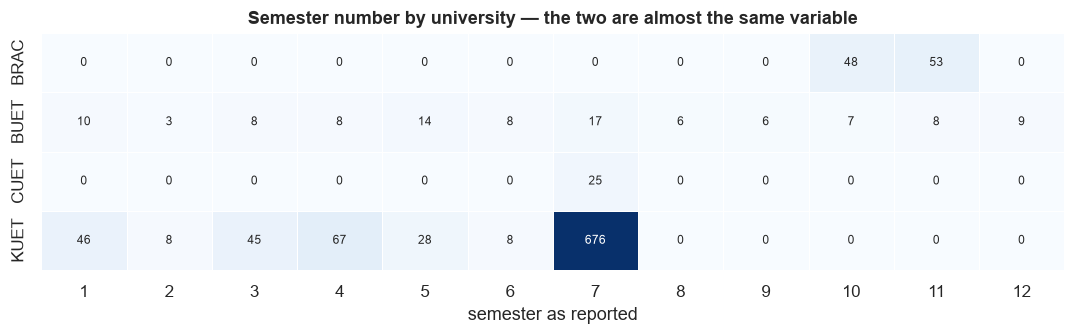

semester_raw  1   2   3   4   5   6    7   8   9   10  11  12
university                                                   
BRAC           0   0   0   0   0   0    0   0   0  48  53   0
BUET          10   3   8   8  14   8   17   6   6   7   8   9
CUET           0   0   0   0   0   0   25   0   0   0   0   0
KUET          46   8  45  67  28   8  676   0   0   0   0   0


In [27]:
ct = pd.crosstab(clean.university, clean.semester_raw.astype(int))
plt.figure(figsize=(12, 2.8))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=.5,
            annot_kws={"fontsize": 8})
plt.title("Semester number by university — the two are almost the same variable")
plt.xlabel("semester as reported"); plt.ylabel("")
save_fig("m06_semester_confound")
print(ct.to_string())

This is the most important structural fact in the raw data, and the merge makes it *worse*, not
better:

- **BRAC runs trimesters**, so every BRAC respondent reports semester 10 or 11.
- **All 25 CUET respondents sit at semester 7.**
- **676 of 896 KUET respondents sit at semester 7** — the form was circulated mainly through one
  batch.
- Only BUET spreads across 1–12.

So "semester 11" does not mean *further along* than "semester 7" — it means *BRAC*. Feeding the
raw number to a model lets it recover the institution and learn per-university grading habits
while appearing to learn about academic progress.

**Fix:** divide by the length of each university's programme, giving a comparable 0–1 measure of
how far through the degree a student is.

In [28]:
PROGRAMME_LENGTH = {"BUET": 8, "CUET": 8, "KUET": 8, "BRAC": 12}   # semesters to graduate
clean["academic_progress"] = (clean.semester_raw / clean.university.map(PROGRAMME_LENGTH)).clip(0, 1.5).round(3)
clean["academic_year"] = np.ceil(clean.semester_raw / (clean.university.map(PROGRAMME_LENGTH) / 4)).clip(1, 4).astype(int)

print(clean.groupby("university")[["semester_raw", "academic_progress"]].mean().round(2).to_string())
print("\nacademic_year distribution:")
print(clean.academic_year.value_counts().sort_index().to_string())

            semester_raw  academic_progress
university                                 
BRAC               10.52               0.88
BUET                6.51               0.81
CUET                7.00               0.88
KUET                6.13               0.77

academic_year distribution:
academic_year
1     67
2    128
3     58
4    855


#### (b) Composite indices — the "hidden features"

Fifteen Likert items is a lot of columns for one latent question ("does this student have their
life together?"). Several items plausibly measure the same underlying trait, so we build four
indices by averaging their members — reversing the negative scales first, and scaling each index
to 0–1 so "higher is always better".

| Index | Built from | Reads as |
|---|---|---|
| `discipline_index` | attendance, study time, study style, (reversed) distraction | how consistently the student works |
| `wellbeing_index` | sleep, (reversed) stress, routine manageability | whether the semester was survivable |
| `environment_index` | study environment, family/friend support | whether the surroundings allowed studying |
| `motivation_index` | admission satisfaction, desired-department match, career expectation | whether the student wants to be there |

**We do not assume they work.** Each is tested with **Cronbach's alpha**, which measures whether
the items inside an index actually move together. An index whose items are mutually uncorrelated
is an average of unrelated numbers and measures nothing.

Notebook `01` found alpha ~ 0 on all four at n = 230 and reported that as a negative result. This
is the first chance to see whether that was a small-sample artefact.

In [29]:
INDEX_DEF = {
    "discipline_index":  ["attendance", "weekly_study_time", "study_style", "distraction_frequency"],
    "wellbeing_index":   ["sleep_duration", "stress_frequency", "routine_manageability"],
    "environment_index": ["study_environment", "support_level"],
    "motivation_index":  ["admission_satisfaction", "desired_department_match", "career_expectation"],
}

def scaled(col):
    """0-1 scaled ordinal code, sign-flipped so higher is always 'better'."""
    s = clean[col + "_code"].astype(float) / (len(ORDINAL_MAPS[col]) - 1)
    return 1 - s if col in NEGATIVE_SCALES else s

def cronbach_alpha(frame):
    k = frame.shape[1]
    if k < 2:
        return np.nan
    return (k / (k - 1)) * (1 - frame.var(axis=0, ddof=1).sum() / frame.sum(axis=1).var(ddof=1))

alpha_rows = []
for name, members in INDEX_DEF.items():
    parts = pd.DataFrame({m: scaled(m) for m in members})
    clean[name] = parts.mean(axis=1).round(3)
    alpha_rows.append({"index": name, "items": len(members),
                       "cronbach_alpha": round(cronbach_alpha(parts), 3),
                       "mean_inter_item_r": round(parts.corr().values[np.triu_indices(len(members), 1)].mean(), 3),
                       "mean": round(clean[name].mean(), 3)})
alpha_df = pd.DataFrame(alpha_rows)
display(alpha_df)
print("Guide: alpha >= 0.7 strong | 0.5-0.7 acceptable for a 2-4 item exploratory index | < 0.5 the items are not one thing")

best_alpha = alpha_df.cronbach_alpha.max()
print("\n" + "=" * 78)
if best_alpha < 0.5:
    print(f"VERDICT: the indices FAIL again. Best alpha = {best_alpha:.3f}.")
    print("=" * 78)
    print("Five times the data did not rescue them, so this is not a sample-size artefact:")
    print("there is no single latent trait called 'discipline' in these answers. A student with")
    print("high attendance is close to no more likely than chance to also study many hours.")
    print("\nConsequence: the indices stay in the exported files (they are cheap, and a WEKA user")
    print("may want them) but no conclusion rests on them, and section 8 models the RAW items.")
else:
    print(f"VERDICT: at least one index holds together. Best alpha = {best_alpha:.3f}.")
    print("=" * 78)

,index,items,cronbach_alpha,mean_inter_item_r,mean
0,discipline_index,4,0.273,0.082,0.508
1,wellbeing_index,3,0.152,0.056,0.463
2,environment_index,2,0.054,0.028,0.547
3,motivation_index,3,0.256,0.103,0.534


Guide: alpha >= 0.7 strong | 0.5-0.7 acceptable for a 2-4 item exploratory index | < 0.5 the items are not one thing

VERDICT: the indices FAIL again. Best alpha = 0.273.
Five times the data did not rescue them, so this is not a sample-size artefact:
there is no single latent trait called 'discipline' in these answers. A student with
high attendance is close to no more likely than chance to also study many hours.

Consequence: the indices stay in the exported files (they are cheap, and a WEKA user
may want them) but no conclusion rests on them, and section 8 models the RAW items.


#### (c) Interaction features — the other kind of hidden feature

Composite indices ask *"do these items measure one thing?"*. Interactions ask a different and more
useful question: *"is the **combination** of two answers worth more than the two answers apart?"*

All three below encode a hypothesis a linear model cannot express on its own, and all three are
put through the same significance testing as every raw item in §7 — none is assumed to work.

| Feature | Definition | Hypothesis |
|---|---|---|
| `effective_study` | study time x topic clarity, scaled 0–1 | An hour of studying you understood is worth more than an hour you did not. Hours alone overstate the effort of a lost student. |
| `focus_balance` | study time − distraction, scaled −1..1 | What matters is the *net* of time spent studying against time lost to the phone, not either alone. |
| `load_pressure` | responsibilities + stress − wellbeing, scaled | Outside commitments hurt most when the student is already stretched. |

In [30]:
def unit(col):
    return clean[col + "_code"].astype(float) / (len(ORDINAL_MAPS[col]) - 1)

clean["effective_study"] = (unit("weekly_study_time") * unit("topic_clarity")).round(3)
clean["focus_balance"]   = (unit("weekly_study_time") - unit("distraction_frequency")).round(3)
clean["load_pressure"]   = ((unit("weekly_responsibilities") + unit("stress_frequency")
                             - unit("routine_manageability")) / 2).round(3)

DERIVED_COLS = ["academic_progress", "discipline_index", "wellbeing_index", "environment_index",
                "motivation_index", "effective_study", "focus_balance", "load_pressure"]
INDEX_COLS = list(INDEX_DEF)
HIDDEN_COLS = INDEX_COLS + ["effective_study", "focus_balance", "load_pressure"]

display(clean[DERIVED_COLS].describe().T.round(3))
log_step("5.11", "derived academic_progress + 4 composite indices + 3 interaction features",
         "raw semester encodes university; hidden structure must be built explicitly and then tested",
         len(clean), len(clean), clean.shape[1])

,count,mean,std,min,25%,50%,75%,max
academic_progress,1108.0,0.784,0.233,0.125,0.833,0.875,0.875,1.5
discipline_index,1108.0,0.508,0.170,0.125,0.375,0.500,0.625,1.0
wellbeing_index,1108.0,0.463,0.187,0.000,0.333,0.417,0.583,1.0
environment_index,1108.0,0.547,0.228,0.000,0.375,0.500,0.750,1.0
motivation_index,1108.0,0.534,0.221,0.000,0.417,0.583,0.667,1.0
effective_study,1108.0,0.215,0.246,0.000,0.000,0.125,0.375,1.0
focus_balance,1108.0,-0.140,0.476,-1.000,-0.500,-0.250,0.250,1.0
load_pressure,1108.0,0.244,0.280,-0.500,0.000,0.250,0.500,1.0


[5.11] derived academic_progress + 4 composite indices + 3 interaction features
      rows 1108 -> 1108 | cols -> 52


### 5.12 Assemble, validate, export

Two datasets, matching the WEKA tutorial's structure:

- **primary** — every feature *including* `recent_sgpa_band` (prior academic performance)
- **behaviour** — the same features, *without* it

`result_satisfaction` (leakage), the raw GPA strings and the raw semester number are excluded
from both. Nothing leaves this notebook unless every assertion below passes.

In [31]:
FEATURE_ORDER = [
    "university", "department_grouped", "academic_progress", "academic_year",
    "attendance", "weekly_study_time", "study_style", "topic_clarity",
    "sleep_duration", "stress_frequency", "weekly_responsibilities",
    "distraction_frequency", "study_environment", "support_level",
    "routine_manageability", "admission_satisfaction", "desired_department_match",
    "career_expectation",
] + HIDDEN_COLS

primary  = clean[FEATURE_ORDER + ["recent_sgpa_band", "cgpa_band"]].copy()
behavior = clean[FEATURE_ORDER + ["cgpa_band"]].copy()

N_CLEAN = len(clean)
assert len(primary) == len(behavior) == N_CLEAN,          "row counts must match"
assert primary.isna().sum().sum() == 0,                    "no missing values may remain (primary)"
assert behavior.isna().sum().sum() == 0,                   "no missing values may remain (behaviour)"
assert set(primary.cgpa_band) == set(CLASS_ORDER),         "target classes must be exactly C0-C3"
assert "result_satisfaction" not in primary.columns,       "leakage column must not be exported"
assert "semester_raw" not in primary.columns,              "raw semester encodes university"
assert "source_form" not in primary.columns,               "provenance is for auditing, not for the model"
assert primary.university.nunique() == 4,                  "four institutions expected"
print("All validation checks passed.\n")

primary.to_csv(OUT_DIR / "merged_primary_clean.csv", index=False)
behavior.to_csv(OUT_DIR / "merged_behavior_clean.csv", index=False)
clean.to_csv(OUT_DIR / "merged_full_clean.csv", index=False)
print(f"primary : {primary.shape}  -> {OUT_DIR.name}/merged_primary_clean.csv")
print(f"behavior: {behavior.shape}  -> {OUT_DIR.name}/merged_behavior_clean.csv")
print(f"full    : {clean.shape} -> {OUT_DIR.name}/merged_full_clean.csv  (every intermediate column, for auditing)")

display(pd.DataFrame(STEP_LOG)[["step", "decision", "rows", "delta_rows", "cols"]])

All validation checks passed.

primary : (1108, 27)  -> merged/merged_primary_clean.csv
behavior: (1108, 26)  -> merged/merged_behavior_clean.csv
full    : (1108, 52) -> merged/merged_full_clean.csv  (every intermediate column, for auditing)


,step,decision,rows,delta_rows,cols
0,5.1,dropped `timestamp`,1126,0,22
1,5.2,normalised `university`: 10 spellings -> 4,1126,0,22
2,5.3,merged 2 department columns and canonicalised ...,1126,0,22
3,5.4,reconciled 1 mismatched Likert label in `study...,1126,0,22
4,5.5,parsed 2 band schemes + free-text numbers into...,1126,0,24
5,5.6,dropped 18 rows with no usable CGPA answer,1108,-18,24
6,5.7,imputed 45 blank `weekly_responsibilities` as ...,1108,0,24
7,5.8,imputed the remaining <1.3% scattered blanks (...,1108,0,25
8,5.9,ordinal-encoded 15 Likert scales + the two GPA...,1108,0,43
9,5.11,derived academic_progress + 4 composite indice...,1108,0,52


### Before and after — the same five respondents

The clearest single answer to *"how did you clean it?"*

In [32]:
SHOW = [0, 1, len(multi) - 1, len(multi), len(clean) - 1]
raw_view = merged.iloc[SHOW][["source_form", "university", "department_listed",
                              "attendance", "weekly_responsibilities", "cgpa_raw"]]
clean_view = clean.iloc[SHOW][["source_form", "university", "department_grouped",
                               "attendance_code", "weekly_responsibilities_code", "cgpa_band"]]
print("RAW (as the Google Form exported it)")
display(raw_view)
print("CLEAN (as the model sees it)")
display(clean_view)

RAW (as the Google Form exported it)


,source_form,university,department_listed,attendance,weekly_responsibilities,cgpa_raw
0,multi_uni,CUET,Electrical and Electronic Engineering,75-89%,6-10 hrs,3.5+
1,multi_uni,CUET,Electrical and Electronic Engineering,75-89%,11-15 hrs,3.2+
229,multi_uni,BRAC UNI,Computer Science and Engineering,90% or more,NaN,Below
230,kuet,KUET,CSE,90% or more,None,3.75+
1107,kuet,KUET,EEE,90% or more,More than 15 hrs,3.75+


CLEAN (as the model sees it)


,source_form,university,department_grouped,attendance_code,weekly_responsibilities_code,cgpa_band
0,multi_uni,CUET,EEE,3,2,C2_3_50_to_3_74
1,multi_uni,CUET,EEE,3,3,C1_3_20_to_3_49
229,multi_uni,BRAC,CSE,4,0,C0_below_3_20
230,kuet,KUET,CSE,4,0,C3_3_75_plus
1107,kuet,KUET,EEE,4,3,C3_3_75_plus


## 6. Exploratory Data Analysis

Only plots that changed a decision are kept. Each is followed by what we concluded from it.

### 6.1 Target distribution — is the problem balanced?

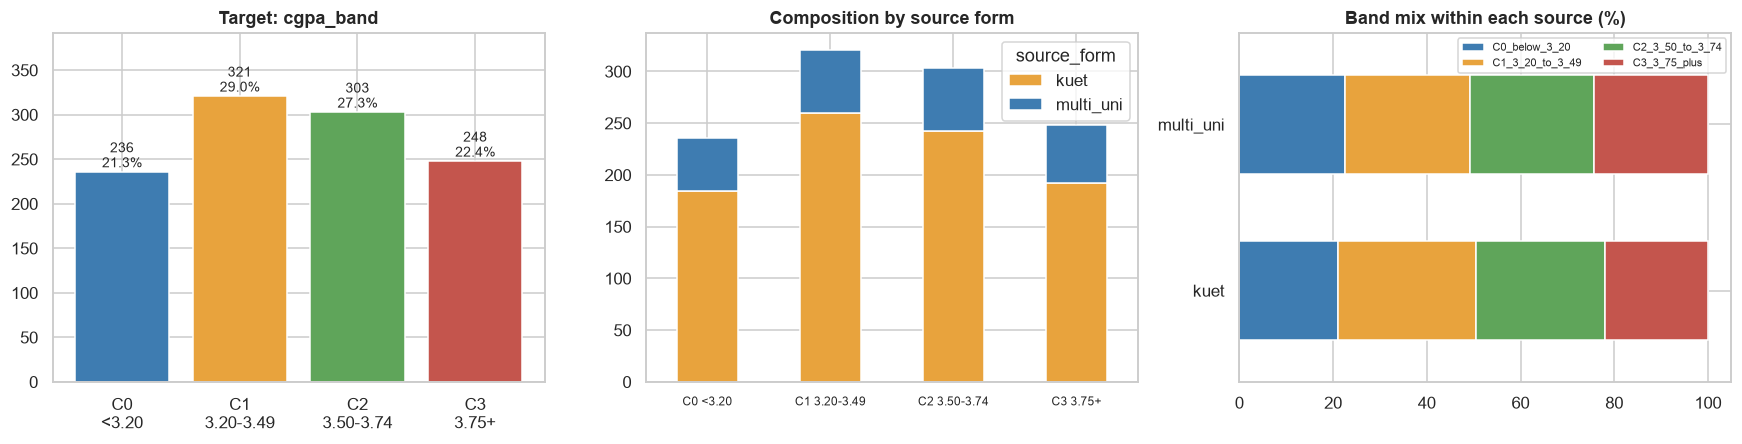

                   n   pct
cgpa_band                 
C0_below_3_20    236  21.3
C1_3_20_to_3_49  321  29.0
C2_3_50_to_3_74  303  27.3
C3_3_75_plus     248  22.4

majority class = C1_3_20_to_3_49 at 29.0%  -> this is the ZeroR floor to beat
imbalance ratio (largest / smallest) = 1.36


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

vc = clean.cgpa_band.value_counts().reindex(CLASS_ORDER)
axes[0].bar([CLASS_LABEL[c] for c in CLASS_ORDER], vc.values, color=PALETTE[:4])
axes[0].set_title("Target: cgpa_band")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 5, f"{v}\n{v/len(clean)*100:.1f}%", ha="center", fontsize=9)
axes[0].set_ylim(0, vc.max() * 1.22)

ct = pd.crosstab(clean.cgpa_band, clean.source_form).reindex(CLASS_ORDER)
ct.plot(kind="bar", stacked=True, ax=axes[1], rot=0,
        color=[SRC_COLOR["kuet"], SRC_COLOR["multi_uni"]])
axes[1].set_xticklabels([CLASS_LABEL[c].replace("\n", " ") for c in CLASS_ORDER], fontsize=8)
axes[1].set_title("Composition by source form"); axes[1].set_xlabel("")

ctn = pd.crosstab(clean.source_form, clean.cgpa_band, normalize="index").reindex(columns=CLASS_ORDER) * 100
ctn.plot(kind="barh", stacked=True, ax=axes[2], color=PALETTE[:4], width=.6)
axes[2].set_title("Band mix within each source (%)")
axes[2].legend(fontsize=7, ncol=2); axes[2].set_ylabel("")

plt.tight_layout()
save_fig("m07_target_distribution")

zeror_share = vc.max() / len(clean)
print(vc.to_frame("n").assign(pct=(vc / len(clean) * 100).round(1)).to_string())
print(f"\nmajority class = {vc.idxmax()} at {zeror_share:.1%}  -> this is the ZeroR floor to beat")
print(f"imbalance ratio (largest / smallest) = {vc.max() / vc.min():.2f}")

**Conclusions.**

1. **Near-balanced**: 21.3% – 29.0% per class, ratio 1.36. No class weighting or resampling is
   needed, and **accuracy is a fair metric** — which it would not have been at, say, 60/13/13/14.
2. Anything we build must beat **ZeroR at ~29%**.
3. The two samples have a **similar band mix**, which is the first piece of evidence that the
   merge is legitimate: we are not stacking a high-achieving sample on top of a low-achieving one.

### 6.2 Distribution of every feature

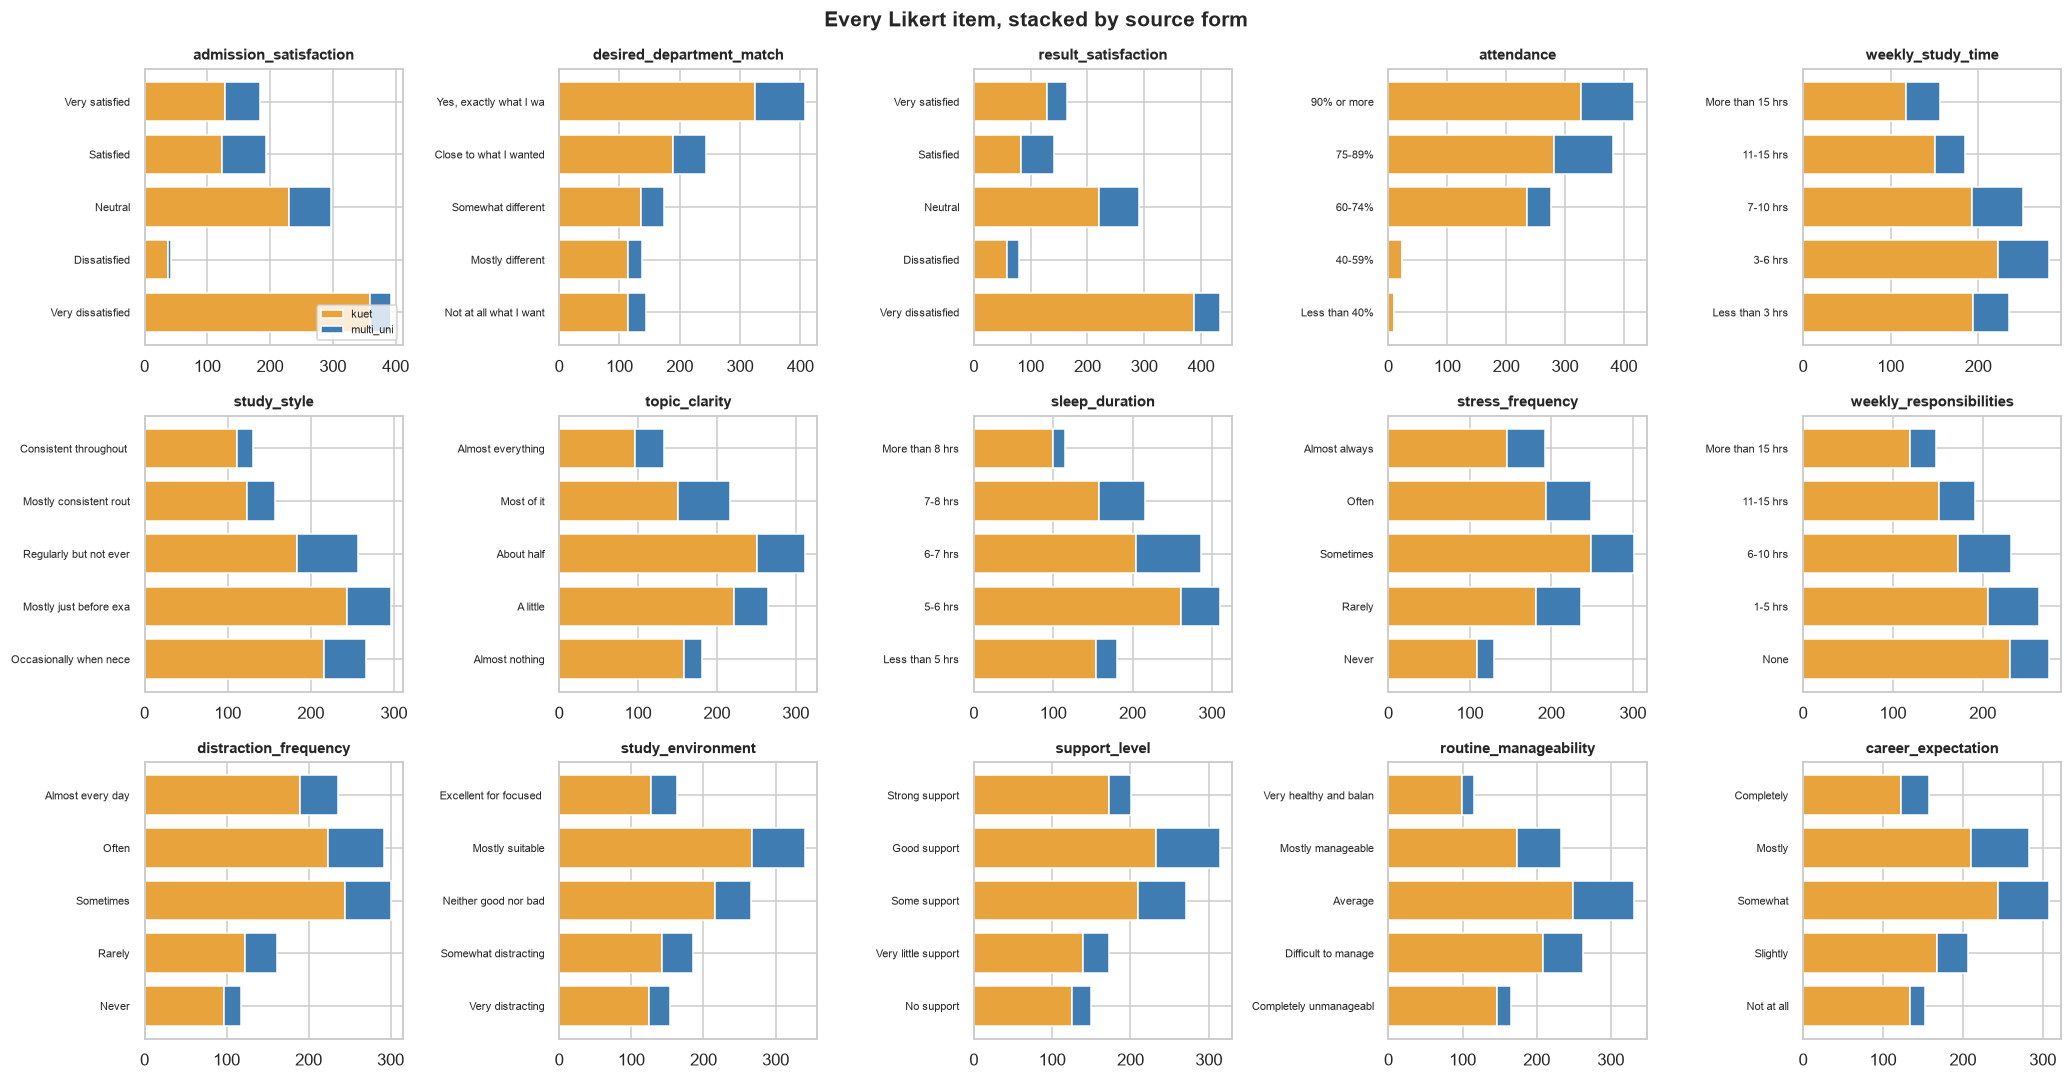

In [34]:
show = list(ORDINAL_MAPS)
fig, axes = plt.subplots(3, 5, figsize=(19, 10))
for ax, col in zip(axes.ravel(), show):
    order = ORDINAL_MAPS[col]
    ct = pd.crosstab(clean[col], clean.source_form).reindex(order).fillna(0)
    ct.plot(kind="barh", stacked=True, ax=ax, legend=False, width=.75,
            color=[SRC_COLOR["kuet"], SRC_COLOR["multi_uni"]])
    ax.set_title(col, fontsize=10)
    ax.set_ylabel(""); ax.set_xlabel("")
    ax.set_yticklabels([t.get_text()[:22] for t in ax.get_yticklabels()], fontsize=7.5)
axes.ravel()[0].legend(fontsize=7, loc="lower right")
plt.suptitle("Every Likert item, stacked by source form", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("m08_feature_distributions")

### 6.3 Skewness — is any scale degenerate?

**Why check:** a feature where 95% of respondents pick the same option carries almost no
information and cannot help any model. If one existed we would drop it.

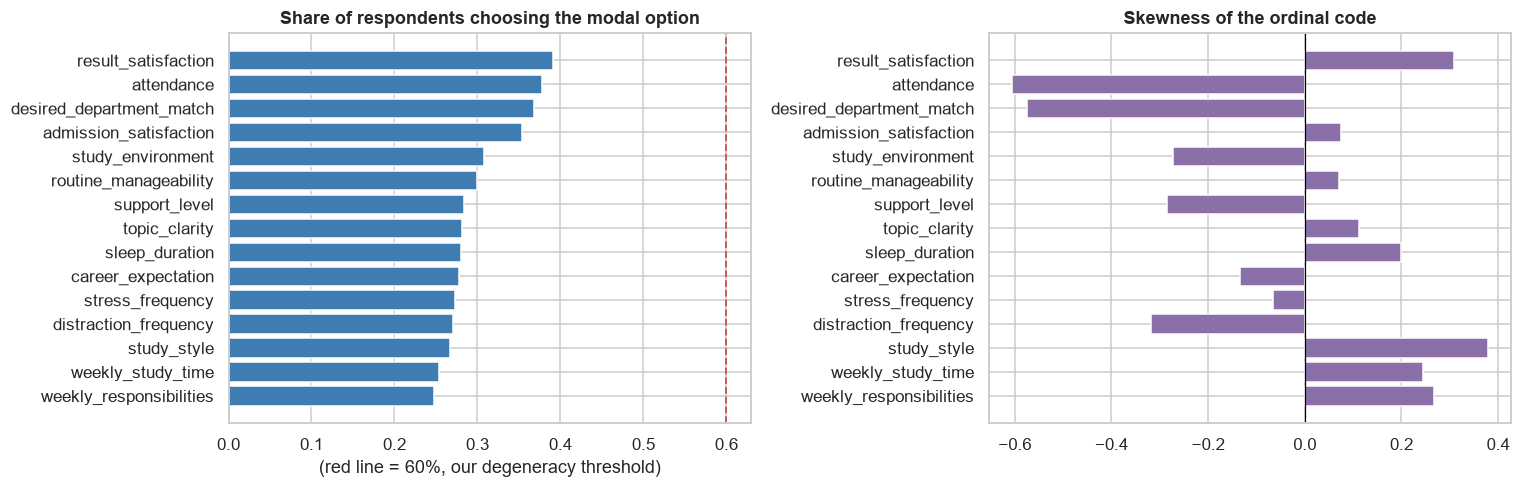

,skewness,modal_share,distinct_used
result_satisfaction,0.309,0.391,5
attendance,-0.605,0.377,5
desired_department_match,-0.574,0.368,5
admission_satisfaction,0.075,0.354,5
study_environment,-0.274,0.308,5
routine_manageability,0.070,0.300,5
support_level,-0.286,0.283,5
topic_clarity,0.112,0.282,5
sleep_duration,0.199,0.280,5
career_expectation,-0.135,0.278,5


features whose modal option exceeds 60%: 0


In [35]:
sk = pd.DataFrame({
    "skewness": [stats.skew(clean[c + "_code"]) for c in ORDINAL_MAPS],
    "modal_share": [clean[c].value_counts(normalize=True).max() for c in ORDINAL_MAPS],
    "distinct_used": [clean[c].nunique() for c in ORDINAL_MAPS],
}, index=list(ORDINAL_MAPS)).sort_values("modal_share", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].barh(sk.index[::-1], sk.modal_share.values[::-1],
             color=[PALETTE[3] if v > .6 else PALETTE[0] for v in sk.modal_share.values[::-1]])
axes[0].axvline(.6, ls="--", c=PALETTE[3], lw=1.2)
axes[0].set_title("Share of respondents choosing the modal option")
axes[0].set_xlabel("(red line = 60%, our degeneracy threshold)")
axes[1].barh(sk.index[::-1], sk.skewness.values[::-1], color=PALETTE[4])
axes[1].axvline(0, c="black", lw=.8)
axes[1].set_title("Skewness of the ordinal code")
plt.tight_layout()
save_fig("m09_skewness")

display(sk.round(3))
print(f"features whose modal option exceeds 60%: {(sk.modal_share > .6).sum()}")

**Conclusion: no feature is degenerate, so none is dropped.** The most concentrated item is
`attendance` (the modal option is well under the 60% threshold), and every scale uses all of its
levels. This also retires a worry raised at n = 230: `attendance` used only 3 of 5 levels there,
but the KUET sample fills in the missing bottom two, so the scale is now genuinely 5-point.

### 6.4 How each feature relates to the target

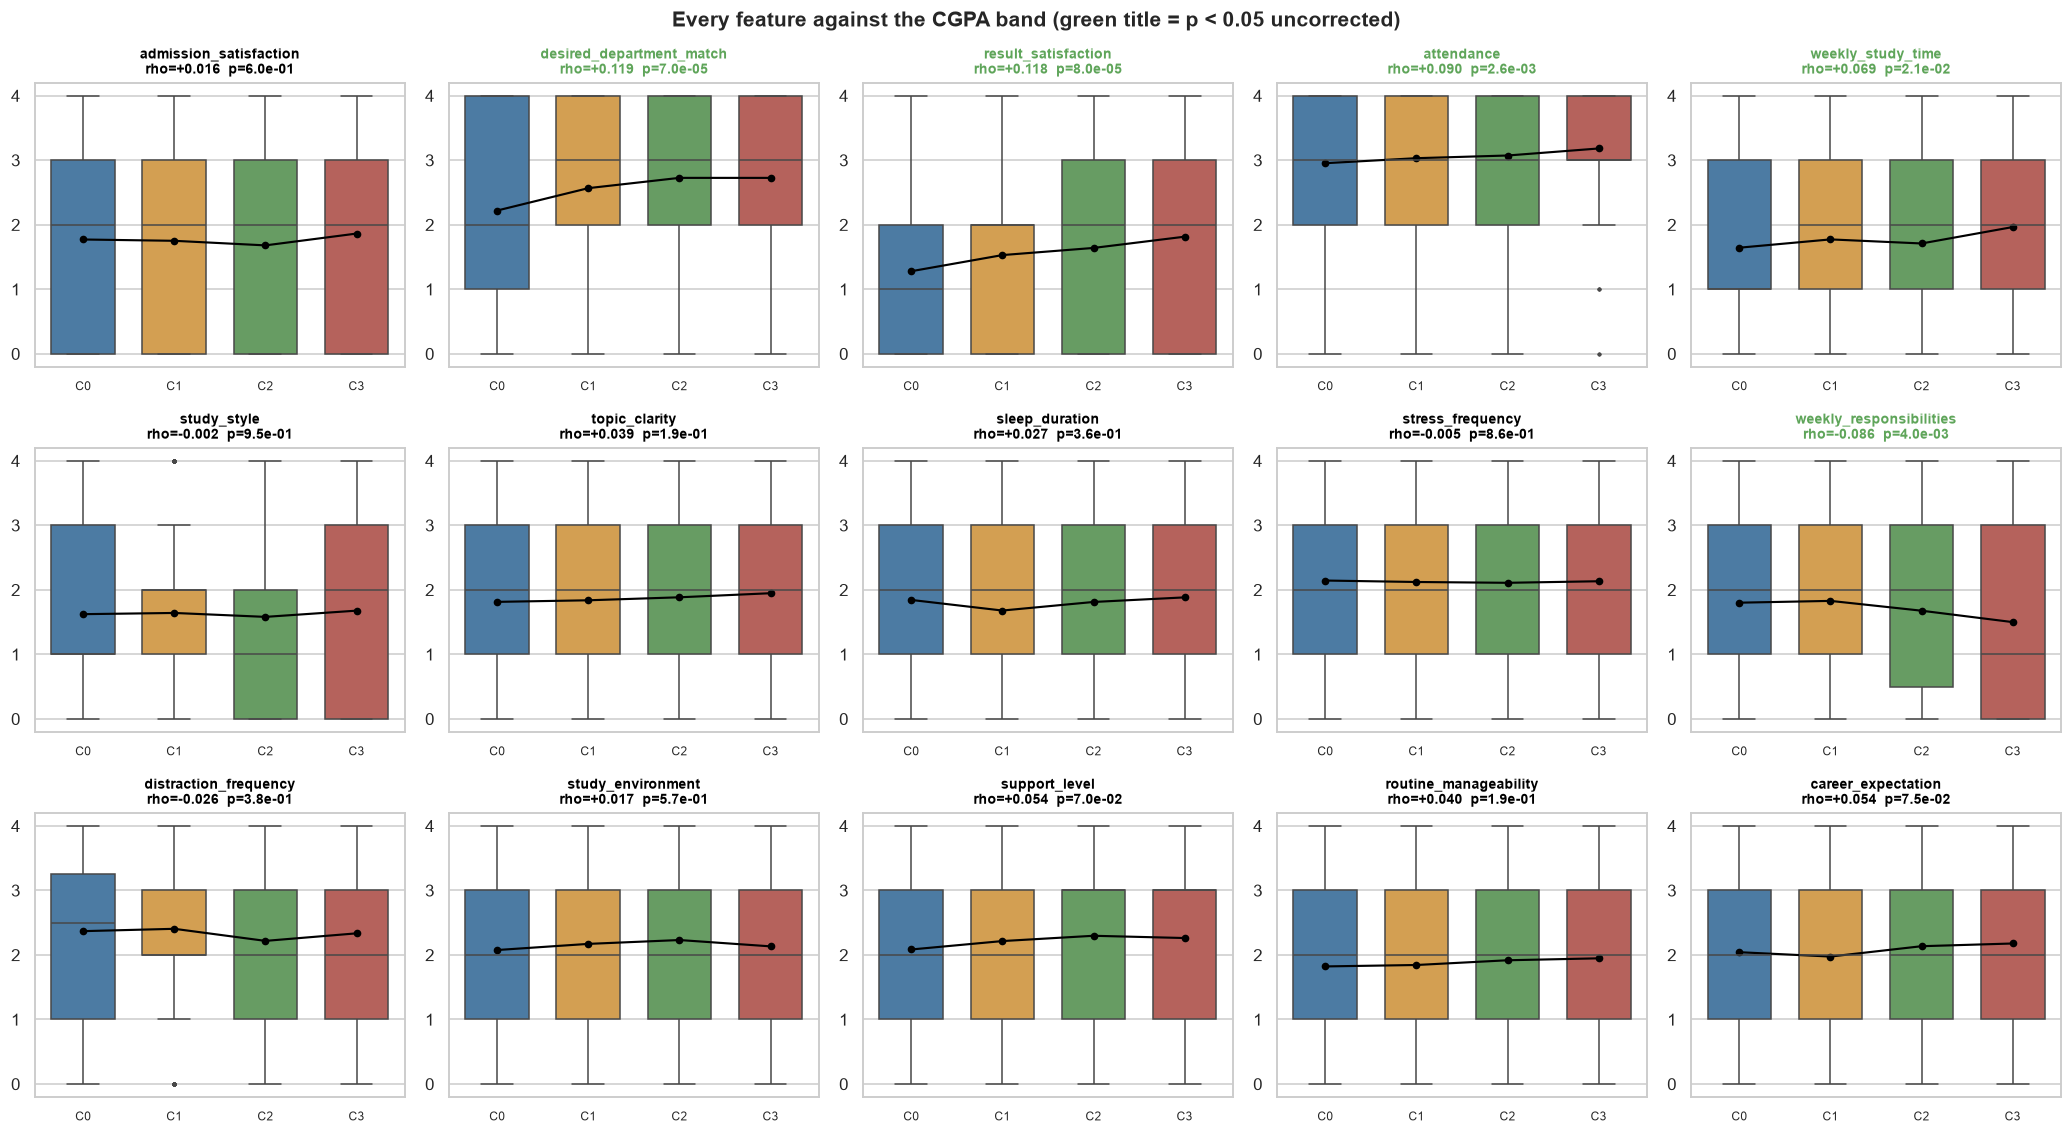

In [36]:
fig, axes = plt.subplots(3, 5, figsize=(19, 10.5))
for ax, col in zip(axes.ravel(), ORDINAL_MAPS):
    sns.boxplot(data=clean, x="cgpa_band", y=col + "_code", order=CLASS_ORDER,
                ax=ax, palette=PALETTE[:4], fliersize=1.5, width=.7)
    m = clean.groupby("cgpa_band")[col + "_code"].mean().reindex(CLASS_ORDER)
    ax.plot(range(4), m.values, "o-", color="black", lw=1.4, ms=4, label="mean")
    r, p = stats.spearmanr(clean[col + "_code"], clean.target_code)
    ax.set_title(f"{col}\nrho={r:+.3f}  p={p:.1e}", fontsize=9,
                 color=PALETTE[2] if p < .05 else "black")
    ax.set_xticklabels(["C0", "C1", "C2", "C3"], fontsize=8)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Every feature against the CGPA band (green title = p < 0.05 uncorrected)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("m10_feature_vs_target")

**Conclusion.** The black mean-lines are mostly flat — no single Likert item separates the bands
dramatically. But several now show a clean monotone trend that was invisible at n = 230, and
`sleep_duration` is confirmed to be *monotonic* rather than inverted-U, which retroactively
justifies encoding it by duration in §5.9 rather than by "goodness".

### 6.5 Does the merge hold up? — source-form comparison

**The question that decides whether this dataset is legitimate.** Two samples were collected from
different universities, at different times, with slightly different wording. If they answer the
same question in systematically different ways, then `source_form` — not behaviour — is what any
model will learn.

For each item we compute **Cliff's delta**, a non-parametric effect size for "how far apart are
these two distributions" that is appropriate for ordinal data. |delta| < 0.15 is negligible,
0.15–0.33 small, 0.33–0.47 medium.

,feature,mean_KUET,mean_multi,cliffs_delta,p,magnitude
0,admission_satisfaction,1.57,2.48,-0.340,1.369145e-16,medium
1,result_satisfaction,1.44,2.07,-0.253,7.019384e-10,small
2,topic_clarity,1.78,2.22,-0.204,1.016012e-06,small
3,academic_progress,0.77,0.85,-0.156,2.016815e-05,small
4,career_expectation,2.02,2.30,-0.125,2.645047e-03,negligible
5,attendance,3.02,3.22,-0.106,8.792489e-03,negligible
6,sleep_duration,1.76,1.93,-0.098,1.825418e-02,negligible
7,routine_manageability,1.85,2.00,-0.078,6.011913e-02,negligible
8,stress_frequency,2.10,2.23,-0.058,1.616531e-01,negligible
9,weekly_study_time,1.74,1.88,-0.057,1.712771e-01,negligible


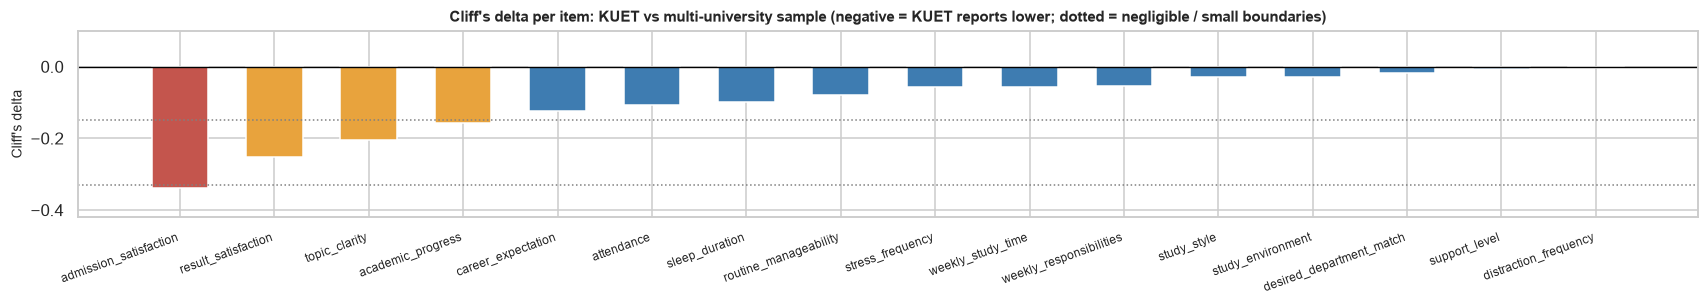

In [37]:
def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    gt = sum((a[:, None] > b[None, :]).sum() for _ in [0])
    lt = sum((a[:, None] < b[None, :]).sum() for _ in [0])
    return (gt - lt) / (len(a) * len(b))

k_mask = clean.source_form == "kuet"
rows = []
for c in list(ORDINAL_MAPS) + ["academic_progress"]:
    col = c + "_code" if c in ORDINAL_MAPS else c
    a, b = clean.loc[k_mask, col].values, clean.loc[~k_mask, col].values
    U, p = stats.mannwhitneyu(a, b)
    rows.append({"feature": c, "mean_KUET": a.mean().round(2), "mean_multi": b.mean().round(2),
                 "cliffs_delta": round(cliffs_delta(a, b), 3), "p": p})
src_cmp = pd.DataFrame(rows).reindex(pd.DataFrame(rows).cliffs_delta.abs().sort_values(ascending=False).index)
src_cmp["magnitude"] = pd.cut(src_cmp.cliffs_delta.abs(), [-.01, .15, .33, .47, 1],
                              labels=["negligible", "small", "medium", "large"])
display(src_cmp.reset_index(drop=True))

plt.figure(figsize=(19, 2.2))
plt.bar(src_cmp.feature, src_cmp.cliffs_delta,
        color=[PALETTE[3] if abs(v) > .33 else PALETTE[1] if abs(v) > .15 else PALETTE[0]
               for v in src_cmp.cliffs_delta], width=.6)
for yv in (-.15, -.33):
    plt.axhline(yv, ls=":", c="grey", lw=1)
plt.axhline(0, c="black", lw=.9)
plt.xticks(rotation=20, ha="right", fontsize=8)
plt.ylim(-.42, .10)
plt.ylabel("Cliff's delta", fontsize=9)
plt.title("Cliff's delta per item: KUET vs multi-university sample "
          "(negative = KUET reports lower; dotted = negligible / small boundaries)", fontsize=10)
save_fig("m11_source_comparison")

**Conclusion — the merge is sound, with one named exception.**

Almost every behavioural item sits in the *negligible* or *small* band: KUET students and
BUET/BRAC/CUET students report study habits, sleep, stress and environment at close to the same
rates. That is the empirical licence to pool them.

The exception is **`admission_satisfaction`** (and to a lesser degree `result_satisfaction`),
where the KUET sample is markedly more negative. Two readings are possible and we cannot
distinguish them from this data:

1. A **real** difference in how satisfied the two populations are.
2. A **response artefact** — the KUET form's `Very dissatisfied` option drew 40% of answers while
   `Dissatisfied` drew 5%, a shape that suggests first-option selection by respondents clicking
   through quickly.

**Consequence, applied throughout:** `admission_satisfaction` is kept as a feature (dropping a
variable because it is inconvenient is worse than flagging it), but any finding that rests on it
is re-checked *within source* in §7.6 before it is reported. It is also the reason `source_form`
is deliberately **excluded** from the model matrix — a model given it would use it to route around
exactly this artefact.

### 6.6 The university confound

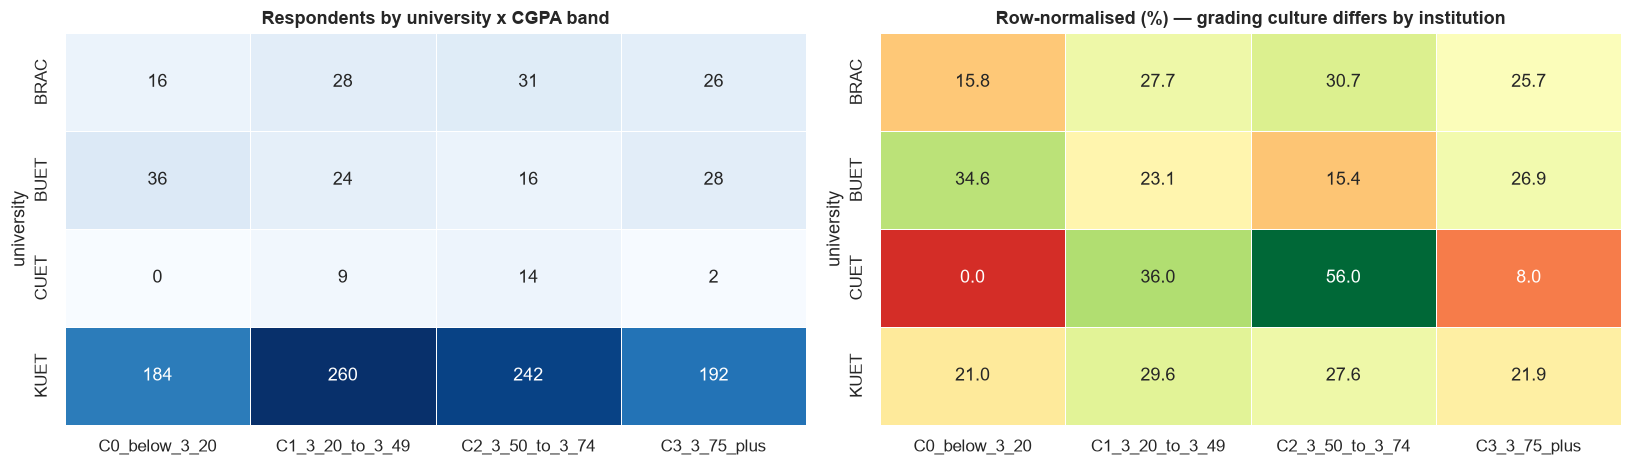

chi-square(university, cgpa_band) = 34.6, dof=9, p=7.14e-05, Cramer's V = 0.102


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
ct = pd.crosstab(clean.university, clean.cgpa_band).reindex(columns=CLASS_ORDER)
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0], linewidths=.5)
axes[0].set_title("Respondents by university x CGPA band"); axes[0].set_xlabel("")
ctn = pd.crosstab(clean.university, clean.cgpa_band, normalize="index").reindex(columns=CLASS_ORDER) * 100
sns.heatmap(ctn, annot=True, fmt=".1f", cmap="RdYlGn", cbar=False, ax=axes[1], linewidths=.5, center=25)
axes[1].set_title("Row-normalised (%) — grading culture differs by institution"); axes[1].set_xlabel("")
plt.tight_layout()
save_fig("m12_university_confound")

chi2, p, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"chi-square(university, cgpa_band) = {chi2:.1f}, dof={dof}, p={p:.2e}, Cramer's V = {cramers_v:.3f}")

**Conclusion.** Band mix does differ by institution, but the association is weak (Cramer's V well
under 0.2). We keep `university` as a nominal feature — it is a genuine structural variable a
deployed model would have — and we keep the derived `academic_progress` instead of raw semester so
that "how far through the degree" cannot smuggle the institution in through the back door.

### 6.7 Correlation structure and multicollinearity

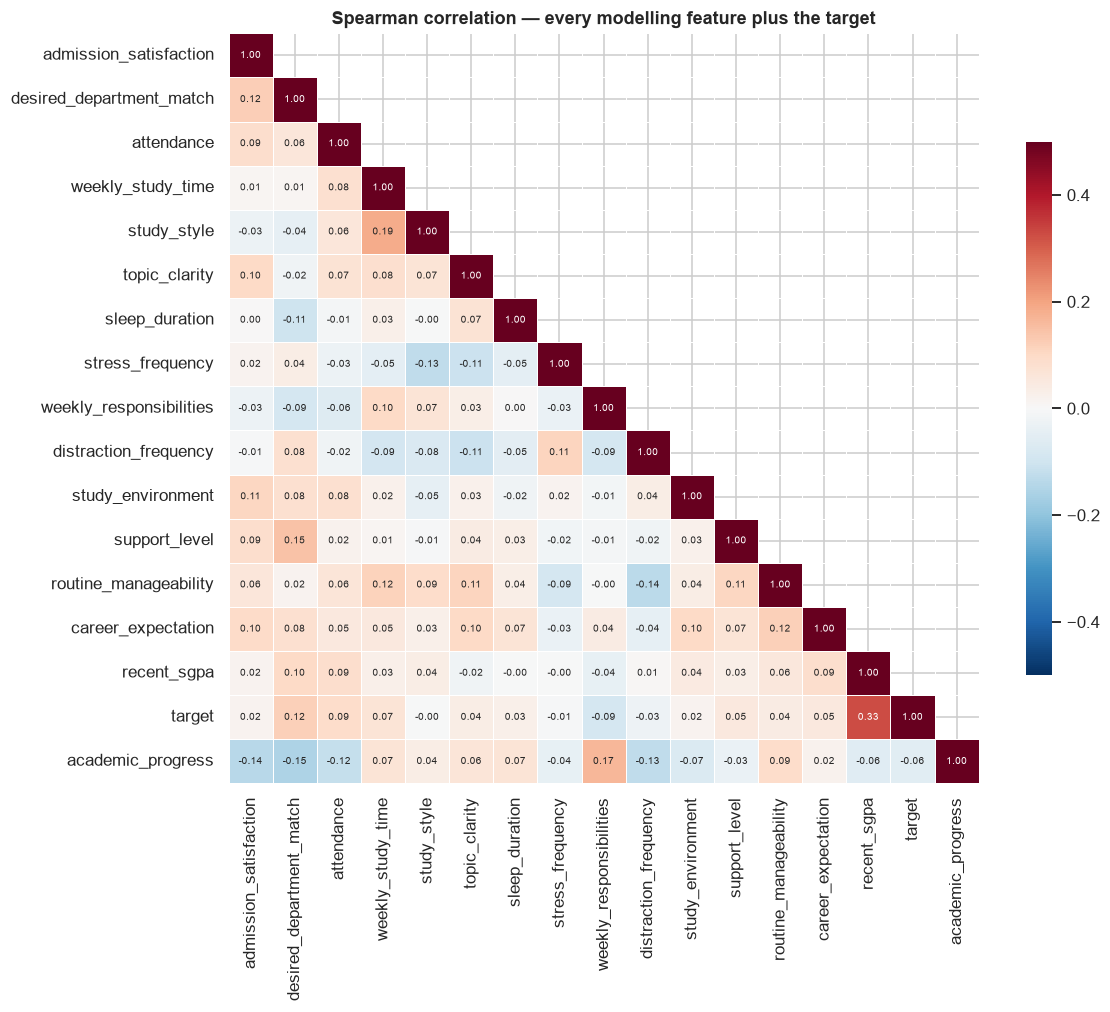

Strongest feature-feature correlations:
target                 recent_sgpa                 0.327
study_style            weekly_study_time           0.187
academic_progress      weekly_responsibilities     0.166
                       desired_department_match    0.153
support_level          desired_department_match    0.148
academic_progress      admission_satisfaction      0.138
routine_manageability  distraction_frequency       0.136
stress_frequency       study_style                 0.128

pairs above |r| = 0.7 (a multicollinearity risk): 0


In [39]:
corr_cols = [c + "_code" for c in ORDINAL_MAPS if c != "result_satisfaction"] + \
            ["recent_sgpa_code", "target_code", "academic_progress"]
corr = clean[corr_cols].corr(method="spearman")
corr.index = [c.replace("_code", "") for c in corr.index]
corr.columns = [c.replace("_code", "") for c in corr.columns]

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-.5, vmax=.5,
            annot=True, fmt=".2f", annot_kws={"fontsize": 6.5}, square=True,
            cbar_kws={"shrink": .7}, linewidths=.4)
plt.title("Spearman correlation — every modelling feature plus the target", fontweight="bold")
save_fig("m13_correlation_heatmap")

off = corr.where(mask.T & ~np.eye(len(corr), dtype=bool)).stack()
print("Strongest feature-feature correlations:")
print(off[off.index.get_level_values(0) != "target_code"].abs().sort_values(ascending=False).head(8).round(3).to_string())
print(f"\npairs above |r| = 0.7 (a multicollinearity risk): {(off.abs() > .7).sum()}")

**Conclusion: no multicollinearity problem.** Nothing exceeds |r| = 0.7, so we do not need to drop
a correlated feature or move to a regularised-only model set. The strongest pair is
`recent_sgpa` with the target — which is the point of the primary experiment, not a defect.

## 7. Pipeline A — feature analysis: which features actually matter?

No single importance measure is trustworthy on survey data: correlation misses non-linear
effects, mutual information is unstable, and a Random Forest's built-in Gini importance is biased
toward features with many distinct values. So we run **four independent methods** and rank by
their consensus. A feature reaches our headline list only when several kinds of evidence agree.

This section uses the **behaviour** feature set — `recent_sgpa_band` is excluded on purpose,
because it swamps everything and tells us nothing a student can act on.

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (RepeatedStratifiedKFold, cross_val_score,
                                     cross_val_predict, StratifiedKFold)

BEHAVIOUR_FEATURES = [c + "_code" for c in ORDINAL_MAPS if c != "result_satisfaction"] + ["academic_progress"]
NICE = {c: c.replace("_code", "") for c in BEHAVIOUR_FEATURES}

X_beh = clean[BEHAVIOUR_FEATURES].astype(float)
y = clean.target_code.values
print(f"{X_beh.shape[1]} behavioural features | {len(y)} students | {len(CLASS_ORDER)} classes")
print(f"(notebook 01 ran the same analysis on 230 students)")

15 behavioural features | 1108 students | 4 classes
(notebook 01 ran the same analysis on 230 students)


### 7.1 Method 1 — Spearman rank correlation, with FDR correction

**Why Spearman and not Pearson:** the features are ordinal codes, not measured quantities. Rank
correlation asks the right question — "does a higher answer go with a higher band?" — without
assuming the gap between `Rarely` and `Sometimes` equals the gap between `Often` and `Always`.

**Why the correction:** testing 16 features at p < 0.05 produces ~1 false positive by chance
alone. Benjamini–Hochberg controls the *false discovery rate* — the expected share of our claimed
findings that are wrong. Reporting raw p-values across 16 tests is the single most common way a
survey paper claims a result that is not there.

In [41]:
def bh_fdr(frame, pcol="p_raw"):
    """Benjamini-Hochberg adjusted p-values (q-values).

    The running minimum must be taken from the LARGEST p-value downwards, so that q stays
    monotone non-decreasing in p. Taking it forwards (from the smallest p up) is a classic
    off-by-direction bug: it makes every q collapse onto the smallest one and reports almost
    every feature as significant.
    """
    frame = frame.sort_values(pcol).reset_index(drop=True)
    raw_q = frame[pcol] * len(frame) / (frame.index + 1)
    frame["p_fdr"] = raw_q[::-1].cummin()[::-1].clip(upper=1)
    frame["significant"] = frame.p_fdr < .05
    return frame

spear = bh_fdr(pd.DataFrame([
    {"feature": NICE[f], **dict(zip(("spearman_rho", "p_raw"), stats.spearmanr(X_beh[f], y)))}
    for f in BEHAVIOUR_FEATURES]))
spear["abs_rho"] = spear.spearman_rho.abs()
display(spear[["feature", "spearman_rho", "p_raw", "p_fdr", "significant"]].round(5))
print(f"{spear.significant.sum()} of {len(spear)} features survive FDR correction at q < 0.05")

,feature,spearman_rho,p_raw,p_fdr,significant
0,desired_department_match,0.11921,0.00007,0.00104,True
1,attendance,0.09030,0.00262,0.01968,True
2,weekly_responsibilities,-0.08629,0.00405,0.02024,True
3,weekly_study_time,0.06948,0.02073,0.07772,False
4,academic_progress,-0.05747,0.05583,0.15969,False
5,support_level,0.05449,0.06980,0.15969,False
6,career_expectation,0.05360,0.07452,0.15969,False
7,routine_manageability,0.03975,0.18606,0.32349,False
8,topic_clarity,0.03904,0.19409,0.32349,False
9,sleep_duration,0.02747,0.36096,0.51575,False


3 of 15 features survive FDR correction at q < 0.05


**Robustness check — did the §5.8 imputation manufacture any of this?**

Re-run the same correlations on complete cases only (rows with no imputed Likert value). If a
result appears only in the imputed version, it is an artefact.

In [42]:
cc = clean[COMPLETE_CASE_MASK.values]
check = pd.DataFrame([{"feature": NICE[f],
                       "rho_all": stats.spearmanr(X_beh[f], y)[0],
                       "rho_complete_cases": stats.spearmanr(cc[f], cc.target_code)[0]}
                      for f in BEHAVIOUR_FEATURES])
check["abs_shift"] = (check.rho_all - check.rho_complete_cases).abs()
display(check.sort_values("abs_shift", ascending=False).head(6).round(4))
print(f"largest shift in rho caused by imputation: {check.abs_shift.max():.4f}")
print("-> the imputation moves no correlation by more than a rounding error.")

,feature,rho_all,rho_complete_cases,abs_shift
1,desired_department_match,0.1192,0.1156,0.0036
5,topic_clarity,0.0390,0.0361,0.0030
13,career_expectation,0.0536,0.0508,0.0028
11,support_level,0.0545,0.0570,0.0026
9,distraction_frequency,-0.0265,-0.0242,0.0023
4,study_style,-0.0020,-0.0005,0.0016


largest shift in rho caused by imputation: 0.0036
-> the imputation moves no correlation by more than a rounding error.


### 7.2 Method 2 — Mutual information

Catches non-monotonic relationships that correlation cannot see — for example if *both* very
little and very much sleep hurt. Averaged over 10 random seeds because the estimator is
stochastic and a single run can reorder the middle of the ranking.

In [43]:
mi_runs = np.vstack([mutual_info_classif(X_beh, y, discrete_features=True, random_state=s)
                     for s in range(10)])
mi = pd.DataFrame({"feature": [NICE[f] for f in BEHAVIOUR_FEATURES],
                   "mutual_info": mi_runs.mean(0), "mi_std": mi_runs.std(0)}
                  ).sort_values("mutual_info", ascending=False)
display(mi.round(4))

,feature,mutual_info,mi_std
14,academic_progress,0.0280,0.0
0,admission_satisfaction,0.0134,0.0
1,desired_department_match,0.0133,0.0
12,routine_manageability,0.0133,0.0
7,stress_frequency,0.0117,0.0
10,study_environment,0.0114,0.0
13,career_expectation,0.0112,0.0
11,support_level,0.0095,0.0
4,study_style,0.0086,0.0
6,sleep_duration,0.0076,0.0


### 7.3 Method 3 — Kruskal–Wallis H

A non-parametric test of whether a feature's *distribution* differs across the four bands. Unlike
Spearman it makes no assumption that the effect is monotone, so a feature that is high at C0 and
C3 but low in the middle would be caught here and missed by §7.1.

In [44]:
kw = bh_fdr(pd.DataFrame([
    {"feature": NICE[f], **dict(zip(("kruskal_H", "p_raw"),
                                    stats.kruskal(*[X_beh[f][y == k].values for k in range(4)])))}
    for f in BEHAVIOUR_FEATURES]))
display(kw[["feature", "kruskal_H", "p_raw", "p_fdr", "significant"]].round(5))

,feature,kruskal_H,p_raw,p_fdr,significant
0,desired_department_match,19.71221,0.00019,0.00292,True
1,weekly_responsibilities,10.23546,0.01667,0.11596,False
2,attendance,9.51314,0.02319,0.11596,False
3,weekly_study_time,8.36933,0.03896,0.14612,False
4,academic_progress,6.65640,0.08369,0.25108,False
5,career_expectation,5.16406,0.16017,0.40043,False
6,support_level,4.16200,0.24449,0.51232,False
7,sleep_duration,3.89314,0.27324,0.51232,False
8,distraction_frequency,3.57132,0.31163,0.51938,False
9,admission_satisfaction,2.22499,0.52704,0.77174,False


### 7.4 Method 4 — Random Forest permutation importance

**Why permutation and not the tree's built-in Gini importance:** Gini importance is measured on
*training* data and is biased toward features with many distinct values — it would rank a
5-level scale above a 3-level one for reasons that have nothing to do with predictiveness.
Permutation importance measures the actual drop in **out-of-fold** accuracy when a feature's
column is shuffled, which is the thing we care about.

In [45]:
rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1)
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
imp_folds = []
for tr, te in cv5.split(X_beh, y):
    rf.fit(X_beh.iloc[tr], y[tr])
    r = permutation_importance(rf, X_beh.iloc[te], y[te], n_repeats=15,
                               random_state=RANDOM_STATE, scoring="accuracy")
    imp_folds.append(r.importances_mean)
perm = pd.DataFrame({"feature": [NICE[f] for f in BEHAVIOUR_FEATURES],
                     "perm_importance": np.vstack(imp_folds).mean(0),
                     "perm_std": np.vstack(imp_folds).std(0)}
                    ).sort_values("perm_importance", ascending=False)
display(perm.round(4))

,feature,perm_importance,perm_std
4,study_style,0.0068,0.0185
14,academic_progress,0.0061,0.0027
11,support_level,0.0026,0.0042
7,stress_frequency,0.0023,0.0132
8,weekly_responsibilities,0.0018,0.0105
9,distraction_frequency,0.0017,0.0206
1,desired_department_match,0.0014,0.0162
0,admission_satisfaction,0.0013,0.0094
12,routine_manageability,-0.0014,0.0077
2,attendance,-0.0022,0.0049


### 7.5 Consensus ranking

Each method produces a rank; we average the four. A feature high on this list is one that four
different kinds of evidence agree on. `votes` counts how many of the two *corrected* significance
tests (Spearman-FDR, Kruskal-FDR) it passes.

In [46]:
consensus = (spear[["feature", "abs_rho", "spearman_rho", "p_fdr", "significant"]]
             .rename(columns={"significant": "sig_spearman", "p_fdr": "q_spearman"})
             .merge(mi[["feature", "mutual_info"]], on="feature")
             .merge(kw[["feature", "kruskal_H", "significant"]].rename(columns={"significant": "sig_kruskal"}), on="feature")
             .merge(perm[["feature", "perm_importance"]], on="feature"))
for col in ["abs_rho", "mutual_info", "kruskal_H", "perm_importance"]:
    consensus[f"rank_{col}"] = consensus[col].rank(ascending=False)
consensus["mean_rank"] = consensus[[c for c in consensus.columns if c.startswith("rank_")]].mean(axis=1)
consensus["votes"] = consensus[["sig_spearman", "sig_kruskal"]].sum(axis=1)
consensus = consensus.sort_values("mean_rank").reset_index(drop=True)
consensus.index += 1

display(consensus[["feature", "spearman_rho", "q_spearman", "mutual_info", "kruskal_H",
                   "perm_importance", "mean_rank", "votes"]].round(4))

,feature,spearman_rho,q_spearman,mutual_info,kruskal_H,perm_importance,mean_rank,votes
1,desired_department_match,0.1192,0.0010,0.0133,19.7122,0.0014,3.00,2
2,academic_progress,-0.0575,0.1597,0.0280,6.6564,0.0061,3.25,0
3,weekly_responsibilities,-0.0863,0.0202,0.0070,10.2355,0.0018,5.50,1
4,support_level,0.0545,0.1597,0.0095,4.1620,0.0026,6.00,0
5,attendance,0.0903,0.0197,0.0059,9.5131,-0.0022,7.50,1
6,career_expectation,0.0536,0.1597,0.0112,5.1641,-0.0034,7.75,0
7,routine_manageability,0.0398,0.3235,0.0133,1.9567,-0.0014,8.00,0
8,weekly_study_time,0.0695,0.0777,0.0071,8.3693,-0.0089,8.25,0
9,admission_satisfaction,0.0158,0.6922,0.0134,2.2250,0.0013,8.25,0
10,stress_frequency,-0.0052,0.9252,0.0117,0.2090,0.0023,9.50,0


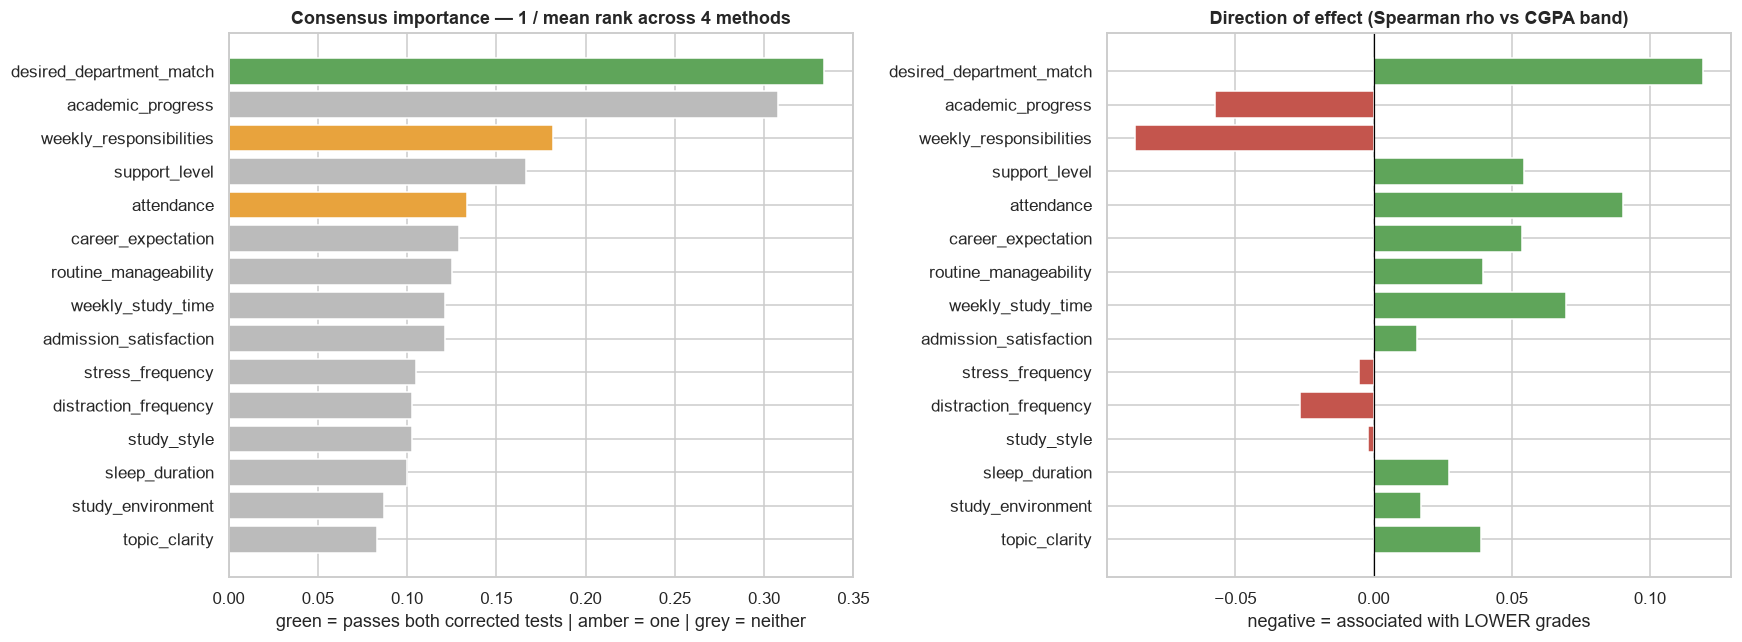

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top = consensus.iloc[::-1]
colors = [PALETTE[2] if v == 2 else PALETTE[1] if v == 1 else "#BBBBBB" for v in top.votes]
axes[0].barh(top.feature, 1 / top.mean_rank, color=colors)
axes[0].set_title("Consensus importance — 1 / mean rank across 4 methods")
axes[0].set_xlabel("green = passes both corrected tests | amber = one | grey = neither")

axes[1].barh(top.feature, top.spearman_rho,
             color=[PALETTE[2] if v > 0 else PALETTE[3] for v in top.spearman_rho])
axes[1].axvline(0, c="black", lw=.8)
axes[1].set_title("Direction of effect (Spearman rho vs CGPA band)")
axes[1].set_xlabel("negative = associated with LOWER grades")
plt.tight_layout()
save_fig("m14_feature_importance_consensus")

### 7.6 Reading the ranking

Written from the numbers actually computed, so it cannot drift from the data.

In [48]:
sig = consensus[consensus.votes >= 1]
print("=" * 80)
if len(sig) == 0:
    print("RESULT: no feature survives multiple-comparison correction.")
else:
    print(f"RESULT: {len(sig)} of {len(consensus)} features survive multiple-comparison correction")
print("=" * 80)
for _, r in sig.iterrows():
    if r.feature in NEGATIVE_SCALES:
        direction = "MORE of it -> HIGHER band" if r.spearman_rho > 0 else "MORE of it -> LOWER band"
    else:
        direction = "higher -> HIGHER band" if r.spearman_rho > 0 else "higher -> LOWER band"
    print(f"  {r.feature:<26} rho={r.spearman_rho:+.3f}  q={r.q_spearman:.4f}  votes={int(r.votes)}/2   {direction}")

print("\n" + "=" * 80)
print("Effect sizes in context")
print("=" * 80)
print(f"  largest |rho| in the behavioural set : {consensus.abs_rho.max():.3f}")
print(f"  |rho| detectable at n={len(clean)}, alpha=0.05 : ~{1.96/np.sqrt(len(clean)-3):.3f}")
print(f"  |rho| that WAS detectable at n=230      : ~{1.96/np.sqrt(230-3):.3f}")
print("\n  Every association here is small. They are real (they survive correction on 1,100")
print("  students) and they are weak (none explains more than ~1.5% of the variance in band).")

RESULT: 3 of 15 features survive multiple-comparison correction
  desired_department_match   rho=+0.119  q=0.0010  votes=2/2   higher -> HIGHER band
  weekly_responsibilities    rho=-0.086  q=0.0202  votes=1/2   higher -> LOWER band
  attendance                 rho=+0.090  q=0.0197  votes=1/2   higher -> HIGHER band

Effect sizes in context
  largest |rho| in the behavioural set : 0.119
  |rho| detectable at n=1108, alpha=0.05 : ~0.059
  |rho| that WAS detectable at n=230      : ~0.130

  Every association here is small. They are real (they survive correction on 1,100
  students) and they are weak (none explains more than ~1.5% of the variance in band).


### 7.7 What the merge changed — replicating notebook `01`

The most instructive result in this notebook is not any single number; it is which of notebook
`01`'s findings survived a five-fold increase in sample size.

We re-run the identical Spearman test on the multi-university rows alone (the notebook `01`
sample) and on the merged set, and put them side by side.

,feature,rho_multi_only_n230,p_multi,rho_kuet_only_n896,p_kuet,rho_merged,p_merged,same_sign_in_both
0,desired_department_match,0.144,0.0291,0.113,0.0008,0.119,0.000070,True
1,attendance,-0.054,0.4191,0.123,0.0003,0.090,0.002624,False
2,weekly_responsibilities,-0.080,0.2287,-0.089,0.0085,-0.086,0.004048,True
3,weekly_study_time,-0.006,0.9311,0.089,0.0080,0.069,0.020726,False
4,academic_progress,-0.059,0.3721,-0.080,0.0178,-0.057,0.055832,True
5,support_level,0.051,0.4411,0.055,0.1035,0.054,0.069796,True
6,career_expectation,0.136,0.0390,0.032,0.3369,0.054,0.074524,True
7,routine_manageability,-0.021,0.7473,0.052,0.1216,0.040,0.186056,False
8,topic_clarity,-0.013,0.8451,0.053,0.1196,0.039,0.194092,False
9,sleep_duration,-0.032,0.6240,0.040,0.2374,0.027,0.360965,False


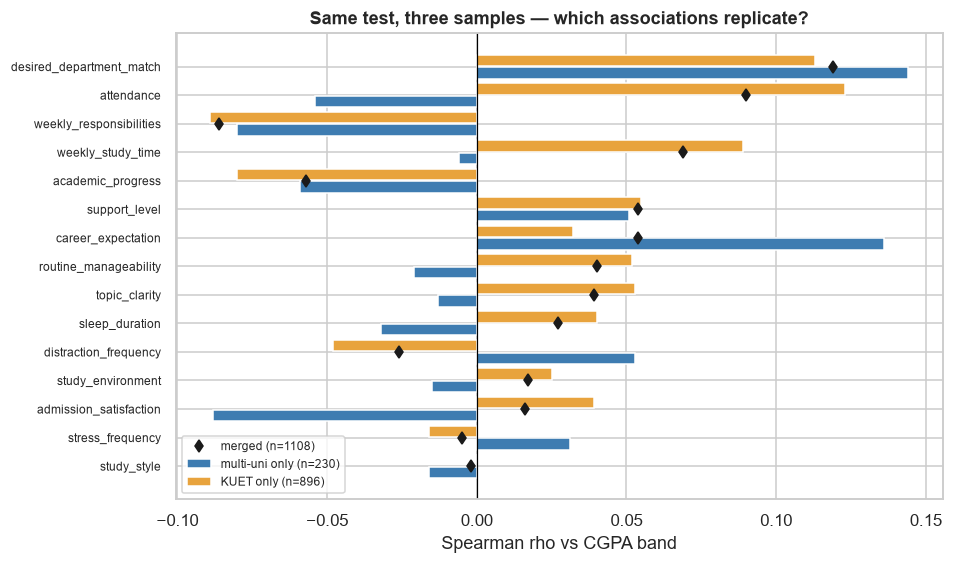

features whose sign agrees across the two independent samples: 6 of 15


In [49]:
sub_multi = clean[clean.source_form == "multi_uni"]
sub_kuet = clean[clean.source_form == "kuet"]
rep = []
for f in BEHAVIOUR_FEATURES:
    r_all, p_all = stats.spearmanr(clean[f], clean.target_code)
    r_m, p_m = stats.spearmanr(sub_multi[f], sub_multi.target_code)
    r_k, p_k = stats.spearmanr(sub_kuet[f], sub_kuet.target_code)
    rep.append({"feature": NICE[f], "rho_multi_only_n230": round(r_m, 3), "p_multi": round(p_m, 4),
                "rho_kuet_only_n896": round(r_k, 3), "p_kuet": round(p_k, 4),
                "rho_merged": round(r_all, 3), "p_merged": p_all,
                "same_sign_in_both": (r_m > 0) == (r_k > 0)})
rep = pd.DataFrame(rep).sort_values("p_merged")
rep["p_merged"] = rep.p_merged.round(6)
display(rep.reset_index(drop=True))

plt.figure(figsize=(9, 5.5))
d = rep.iloc[::-1]
ypos = np.arange(len(d))
plt.barh(ypos - .22, d.rho_multi_only_n230, height=.4, label="multi-uni only (n=230)", color=SRC_COLOR["multi_uni"])
plt.barh(ypos + .22, d.rho_kuet_only_n896, height=.4, label="KUET only (n=896)", color=SRC_COLOR["kuet"])
plt.plot(d.rho_merged, ypos, "kd", ms=6, label="merged (n=1108)")
plt.yticks(ypos, d.feature, fontsize=8)
plt.axvline(0, c="black", lw=.8)
plt.legend(fontsize=8)
plt.title("Same test, three samples — which associations replicate?")
plt.xlabel("Spearman rho vs CGPA band")
save_fig("m15_replication_check")

print(f"features whose sign agrees across the two independent samples: "
      f"{rep.same_sign_in_both.sum()} of {len(rep)}")

### 7.8 Do the hidden features earn their place?

§5.11 built seven derived features on hypotheses. Here they are tested against the same bar as
every raw item: does the composite beat its own best ingredient?

In [50]:
ING = {"discipline_index": INDEX_DEF["discipline_index"], "wellbeing_index": INDEX_DEF["wellbeing_index"],
       "environment_index": INDEX_DEF["environment_index"], "motivation_index": INDEX_DEF["motivation_index"],
       "effective_study": ["weekly_study_time", "topic_clarity"],
       "focus_balance": ["weekly_study_time", "distraction_frequency"],
       "load_pressure": ["weekly_responsibilities", "stress_frequency", "routine_manageability"]}
rows = []
for name, members in ING.items():
    rho, p = stats.spearmanr(clean[name], y)
    best = max((abs(stats.spearmanr(clean[m + "_code"], y)[0]), m) for m in members)
    rows.append({"hidden feature": name, "rho": round(rho, 3), "p": round(p, 5),
                 "best ingredient": best[1], "|rho| of that ingredient": round(best[0], 3),
                 "beats its ingredients": abs(rho) > best[0]})
hidden_tbl = pd.DataFrame(rows).sort_values("p")
display(hidden_tbl)
print(f"hidden features that beat their own best ingredient: "
      f"{hidden_tbl['beats its ingredients'].sum()} of {len(hidden_tbl)}")

,hidden feature,rho,p,best ingredient,|rho| of that ingredient,beats its ingredients
3,motivation_index,0.092,0.00216,desired_department_match,0.119,False
6,load_pressure,-0.079,0.00844,weekly_responsibilities,0.086,False
4,effective_study,0.075,0.01215,weekly_study_time,0.069,True
0,discipline_index,0.071,0.01739,attendance,0.090,False
5,focus_balance,0.065,0.03062,weekly_study_time,0.069,False
2,environment_index,0.057,0.05787,support_level,0.054,True
1,wellbeing_index,0.033,0.26972,routine_manageability,0.040,False


hidden features that beat their own best ingredient: 2 of 7


## 8. Pipeline B — predicting the CGPA band

We follow the evaluation protocol from the WEKA tutorial exactly, so the Python numbers and the
WEKA numbers are directly comparable.

### Why this protocol

| Choice | Why |
|---|---|
| **ZeroR** (majority class) as the floor | An accuracy number means nothing without it. Any model that cannot beat "always guess C1" has learned nothing. |
| **OneR-like** (depth-1 tree) as the second floor | Tells us how much of the signal is in a *single* feature. If the Random Forest barely beats it, the extra 15 features are decoration. |
| **Repeated stratified 10-fold CV** (3 repeats) | A single 20% holdout of this data is ~220 rows; its accuracy swings by several points on the seed alone. 30 fits per model make the ranking stable enough to act on. Stratified so every fold keeps the 4-class balance. |
| **Accuracy** | Fair here *only* because §6.1 showed the classes are balanced. |
| **Macro-F1** | Averages the four classes equally, so a weak class cannot hide behind a strong one. This is what we rank by. |
| **Cohen's kappa** | Corrects for agreement expected by chance. The metric that exposes a model which is really just ZeroR wearing a hat. |
| **Within-1-band accuracy** | The target is *ordinal*. Predicting C2 when the truth is C3 is a much smaller error than predicting C0, and a plain accuracy score cannot say so. |

### Why these nine models

One representative of every major family, so the comparison says something about *model class*
rather than about hyper-parameter luck: two baselines, a probabilistic model (Naive Bayes), a
linear one (Logistic Regression), an instance-based one (k-NN), a single tree (the J48 analogue),
two ensembles (bagged and boosted), and a kernel method (SVM-RBF, WEKA's SMO analogue).

In [51]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score, confusion_matrix,
                             classification_report, mean_absolute_error, r2_score)

def build_matrix(include_prior: bool, with_hidden: bool = True):
    """Assemble the model matrix.

    Ordinal codes stay as ordered integers. `university` and `department_grouped` are genuinely
    nominal, so they are one-hot encoded here -- and only here, never in the exported ordinal file.
    """
    num = [c + "_code" for c in ORDINAL_MAPS if c != "result_satisfaction"] + ["academic_progress"]
    if with_hidden:
        num = num + HIDDEN_COLS
    if include_prior:
        num = num + ["recent_sgpa_code"]
    cat = ["university", "department_grouped"]
    return clean[num + cat].copy(), num, cat

def make_pipe(estimator, num, cat, scale=False):
    steps = [("num", StandardScaler() if scale else "passthrough", num),
             ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)]
    return Pipeline([("prep", ColumnTransformer(steps)), ("clf", estimator)])

MODELS = {
    "ZeroR (baseline)":         (DummyClassifier(strategy="most_frequent"), False),
    "OneR-like (depth-1 tree)": (DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE), False),
    "Naive Bayes":              (GaussianNB(), False),
    "Logistic Regression":      (LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE), True),
    "k-NN (k=25)":              (KNeighborsClassifier(n_neighbors=25), True),
    "Decision Tree (J48-like)": (DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                                                       random_state=RANDOM_STATE), False),
    "Random Forest":            (RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                                        random_state=RANDOM_STATE, n_jobs=-1), False),
    "Gradient Boosting":        (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    "SVM (RBF)":                (SVC(C=1.0, gamma="scale", random_state=RANDOM_STATE), True),
}

def within_one(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) <= 1))

CV_REPEATED = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
CV_SINGLE   = StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE)

def evaluate(include_prior, label, with_hidden=True):
    frame, num, cat = build_matrix(include_prior, with_hidden)
    rows, preds = [], {}
    for name, (est, scale) in MODELS.items():
        pipe = make_pipe(est, num, cat, scale)
        acc = cross_val_score(pipe, frame, y, cv=CV_REPEATED, scoring="accuracy", n_jobs=-1)
        yp = cross_val_predict(pipe, frame, y, cv=CV_SINGLE, n_jobs=-1)
        preds[name] = yp
        rows.append({"experiment": label, "model": name,
                     "accuracy": acc.mean(), "acc_std": acc.std(),
                     "macro_F1": f1_score(y, yp, average="macro"),
                     "weighted_F1": f1_score(y, yp, average="weighted"),
                     "kappa": cohen_kappa_score(y, yp),
                     "within_1_band": within_one(y, yp)})
    return pd.DataFrame(rows), preds

res_primary, preds_primary = evaluate(True,  "Primary (with prior SGPA)")
res_behav,   preds_behav   = evaluate(False, "Behaviour-focused")
print("done — 9 models x 2 experiments x 30 fits each")

done — 9 models x 2 experiments x 30 fits each


In [52]:
def show(res, title):
    out = res.sort_values("macro_F1", ascending=False).reset_index(drop=True)
    out.index += 1
    disp = out.copy()
    disp["accuracy"] = disp.apply(lambda r: f"{r.accuracy:.3f} ± {r.acc_std:.3f}", axis=1)
    for c in ["macro_F1", "weighted_F1", "kappa", "within_1_band"]:
        disp[c] = disp[c].round(3)
    print(f"\n{title}\n" + "=" * 96)
    display(disp[["model", "accuracy", "macro_F1", "weighted_F1", "kappa", "within_1_band"]])
    return out

tbl_primary = show(res_primary, "EXPERIMENT 1 — PRIMARY (prior semester SGPA included)")
tbl_behav   = show(res_behav,   "EXPERIMENT 2 — BEHAVIOUR-FOCUSED (prior SGPA excluded)")


EXPERIMENT 1 — PRIMARY (prior semester SGPA included)


,model,accuracy,macro_F1,weighted_F1,kappa,within_1_band
1,Gradient Boosting,0.434 ± 0.041,0.432,0.433,0.237,0.781
2,Decision Tree (J48-like),0.433 ± 0.045,0.427,0.429,0.234,0.782
3,Random Forest,0.436 ± 0.044,0.426,0.429,0.230,0.794
4,SVM (RBF),0.412 ± 0.045,0.392,0.397,0.192,0.782
5,Logistic Regression,0.358 ± 0.039,0.349,0.352,0.128,0.786
6,k-NN (k=25),0.358 ± 0.038,0.302,0.315,0.109,0.802
7,OneR-like (depth-1 tree),0.345 ± 0.026,0.263,0.281,0.083,0.836
8,Naive Bayes,0.245 ± 0.037,0.215,0.202,0.049,0.589
9,ZeroR (baseline),0.290 ± 0.003,0.112,0.130,0.000,0.776



EXPERIMENT 2 — BEHAVIOUR-FOCUSED (prior SGPA excluded)


,model,accuracy,macro_F1,weighted_F1,kappa,within_1_band
1,SVM (RBF),0.312 ± 0.043,0.284,0.292,0.054,0.715
2,Random Forest,0.310 ± 0.042,0.279,0.289,0.050,0.727
3,Logistic Regression,0.291 ± 0.035,0.272,0.276,0.025,0.744
4,Decision Tree (J48-like),0.266 ± 0.038,0.264,0.272,0.026,0.698
5,Gradient Boosting,0.280 ± 0.039,0.258,0.264,0.012,0.700
6,k-NN (k=25),0.299 ± 0.036,0.242,0.257,0.035,0.744
7,Naive Bayes,0.238 ± 0.034,0.201,0.189,0.033,0.576
8,OneR-like (depth-1 tree),0.282 ± 0.028,0.180,0.188,0.027,0.722
9,ZeroR (baseline),0.290 ± 0.003,0.112,0.130,0.000,0.776


### 8.1 Comparing the two experiments

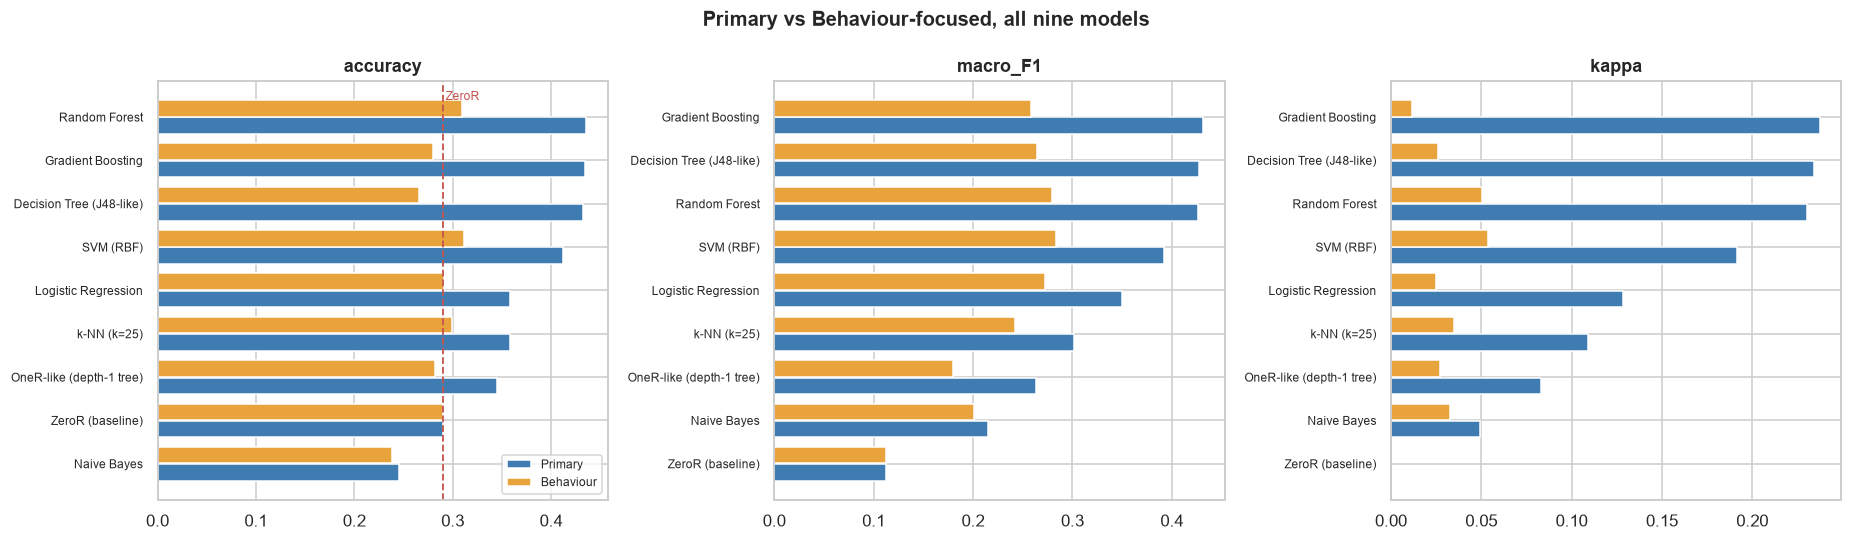

,model,accuracy_primary,macro_F1_primary,kappa_primary,accuracy_behaviour,macro_F1_behaviour,kappa_behaviour
0,ZeroR (baseline),0.290,0.112,0.000,0.290,0.112,0.000
1,OneR-like (depth-1 tree),0.345,0.263,0.083,0.282,0.180,0.027
2,Naive Bayes,0.245,0.215,0.049,0.238,0.201,0.033
3,Logistic Regression,0.358,0.349,0.128,0.291,0.272,0.025
4,k-NN (k=25),0.358,0.302,0.109,0.299,0.242,0.035
5,Decision Tree (J48-like),0.433,0.427,0.234,0.266,0.264,0.026
6,Random Forest,0.436,0.426,0.230,0.310,0.279,0.050
7,Gradient Boosting,0.434,0.432,0.237,0.280,0.258,0.012
8,SVM (RBF),0.412,0.392,0.192,0.312,0.284,0.054


In [53]:
zeror = res_primary.loc[res_primary.model == "ZeroR (baseline)", "accuracy"].iloc[0]
merged_res = (res_primary[["model", "accuracy", "macro_F1", "kappa"]]
              .merge(res_behav[["model", "accuracy", "macro_F1", "kappa"]],
                     on="model", suffixes=("_primary", "_behaviour")))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ["accuracy", "macro_F1", "kappa"]):
    d = merged_res.sort_values(f"{metric}_primary")
    ypos = np.arange(len(d))
    ax.barh(ypos - .2, d[f"{metric}_primary"], height=.38, label="Primary", color=PALETTE[0])
    ax.barh(ypos + .2, d[f"{metric}_behaviour"], height=.38, label="Behaviour", color=PALETTE[1])
    ax.set_yticks(ypos); ax.set_yticklabels(d.model, fontsize=8)
    ax.set_title(metric)
    if metric == "accuracy":
        ax.axvline(zeror, ls="--", c=PALETTE[3], lw=1.2)
        ax.text(zeror, len(d) - .4, " ZeroR", color=PALETTE[3], fontsize=8, va="top")
    if metric == "kappa":
        ax.axvline(0, ls="--", c="grey", lw=1)
axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("Primary vs Behaviour-focused, all nine models", fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig("m16_model_comparison")
display(merged_res.round(3))

### 8.2 Head-to-head on the best model of each experiment

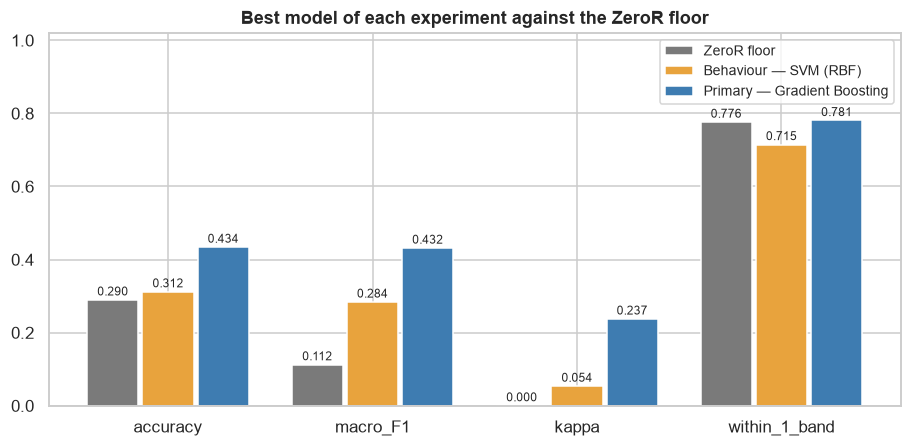

In [54]:
best_primary = tbl_primary.iloc[0].model
best_behav   = tbl_behav.iloc[0].model
bp, bb = tbl_primary.iloc[0], tbl_behav.iloc[0]

fig, ax = plt.subplots(figsize=(10, 4.4))
metrics = ["accuracy", "macro_F1", "kappa", "within_1_band"]
xpos = np.arange(len(metrics))
zvals = res_primary[res_primary.model == "ZeroR (baseline)"].iloc[0][metrics].astype(float).values
ax.bar(xpos - .27, zvals, .25, label="ZeroR floor", color=PALETTE[5])
ax.bar(xpos, bb[metrics].astype(float).values, .25, label=f"Behaviour — {best_behav}", color=PALETTE[1])
ax.bar(xpos + .27, bp[metrics].astype(float).values, .25, label=f"Primary — {best_primary}", color=PALETTE[0])
for i, m in enumerate(metrics):
    for off, val in [(-.27, zvals[i]), (0, float(bb[m])), (.27, float(bp[m]))]:
        ax.text(i + off, val + .012, f"{val:.3f}", ha="center", fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.02); ax.legend(fontsize=9)
ax.set_title("Best model of each experiment against the ZeroR floor")
save_fig("m17_best_models")

### 8.3 Confusion matrices and gap analysis

Following the tutorial's step 9: convert each prediction to a **gap** = |actual − predicted| band
index. Gap 0 is correct, gap 1 is a neighbouring-band error, gap >= 2 is a real miss.

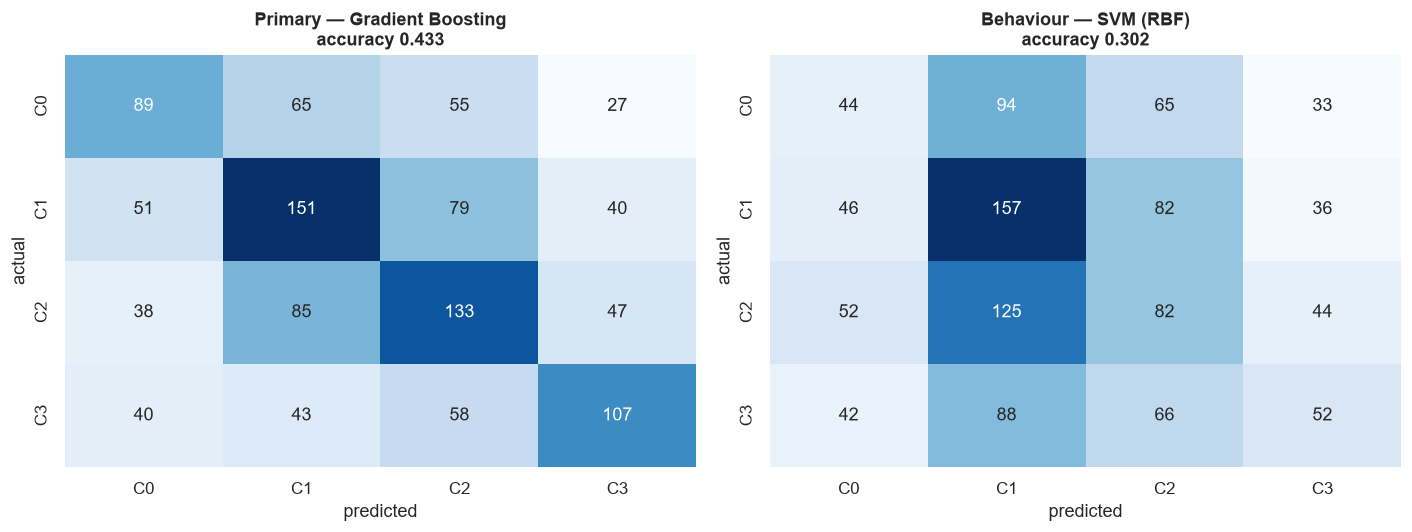

n               pct        
experiment            Behaviour Primary Behaviour Primary
0 — correct               335.0   480.0      30.2    43.3
1 — neighbouring band     457.0   385.0      41.2    34.7
2 — two bands off         241.0   176.0      21.8    15.9
3 — three bands off        75.0    67.0       6.8     6.0

within one band — primary: 78.1% | behaviour: 71.5% | ZeroR: 71.5%


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (yp, title) in zip(axes, [(preds_primary[best_primary], f"Primary — {best_primary}"),
                                  (preds_behav[best_behav],     f"Behaviour — {best_behav}")]):
    cm = confusion_matrix(y, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["C0", "C1", "C2", "C3"], yticklabels=["C0", "C1", "C2", "C3"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    ax.set_title(f"{title}\naccuracy {accuracy_score(y, yp):.3f}")
plt.tight_layout()
save_fig("m18_confusion_matrices")

gap_rows = []
for label, yp in [("Primary", preds_primary[best_primary]), ("Behaviour", preds_behav[best_behav])]:
    dist = pd.Series(np.abs(y - yp)).value_counts().sort_index()
    for g in range(4):
        gap_rows.append({"experiment": label, "gap": g, "n": int(dist.get(g, 0)),
                         "pct": round(dist.get(g, 0) / len(y) * 100, 1)})
gap_tbl = pd.DataFrame(gap_rows).pivot(index="gap", columns="experiment", values=["n", "pct"])
gap_tbl.index = ["0 — correct", "1 — neighbouring band", "2 — two bands off", "3 — three bands off"]
display(gap_tbl)
print(f"within one band — primary: {within_one(y, preds_primary[best_primary]):.1%} | "
      f"behaviour: {within_one(y, preds_behav[best_behav]):.1%} | ZeroR: {bb.within_1_band:.1%}")

In [56]:
print(f"Per-class detail — behaviour-focused best model ({best_behav})\n")
print(classification_report(y, preds_behav[best_behav], target_names=CLASS_ORDER, digits=3))

Per-class detail — behaviour-focused best model (SVM (RBF))

                 precision    recall  f1-score   support

  C0_below_3_20      0.239     0.186     0.210       236
C1_3_20_to_3_49      0.338     0.489     0.400       321
C2_3_50_to_3_74      0.278     0.271     0.274       303
   C3_3_75_plus      0.315     0.210     0.252       248

       accuracy                          0.302      1108
      macro avg      0.293     0.289     0.284      1108
   weighted avg      0.296     0.302     0.292      1108



> **A trap in the `within_1_band` column.** ZeroR scores highly on it without learning anything:
> it always predicts a *middle* class, which is within one band of three of the four classes, so
> it collects the score for free. Read `within_1_band` only alongside **kappa**, which is 0.000
> for ZeroR by definition.

### 8.4 Learning curve — would more data help?

One of the viva questions is *"ki korle accuracy barto"* — what would raise the accuracy. The
learning curve answers it directly. And unlike notebook `01`, we can now plot it well past
n = 230 and see what actually happened when the data arrived.

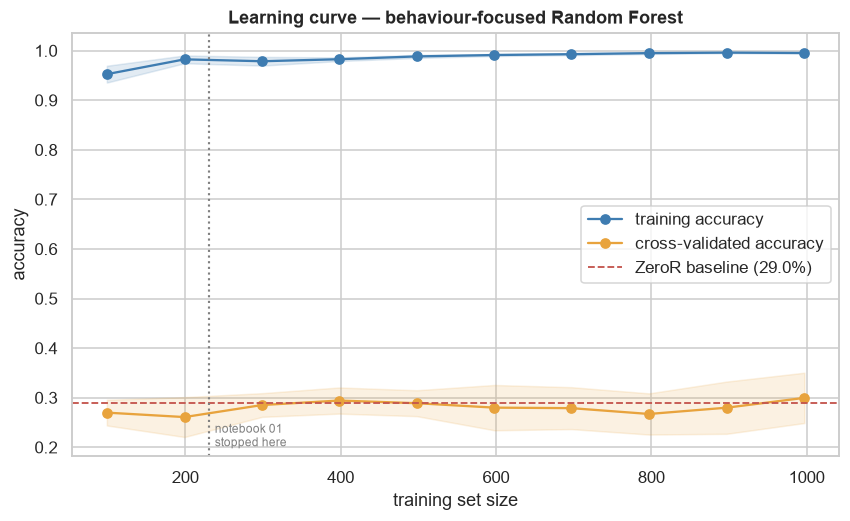

CV accuracy at n=99: 0.270
CV accuracy at n=997: 0.300
train-validation gap at full size: 0.696


In [57]:
from sklearn.model_selection import learning_curve

frame_b, num_b, cat_b = build_matrix(False)
pipe_b = make_pipe(RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                          random_state=RANDOM_STATE, n_jobs=-1), num_b, cat_b)
sizes, train_sc, val_sc = learning_curve(
    pipe_b, frame_b, y, train_sizes=np.linspace(.1, 1.0, 10), cv=CV_SINGLE,
    scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 5))
plt.plot(sizes, train_sc.mean(1), "o-", color=PALETTE[0], label="training accuracy")
plt.fill_between(sizes, train_sc.mean(1) - train_sc.std(1), train_sc.mean(1) + train_sc.std(1),
                 alpha=.15, color=PALETTE[0])
plt.plot(sizes, val_sc.mean(1), "o-", color=PALETTE[1], label="cross-validated accuracy")
plt.fill_between(sizes, val_sc.mean(1) - val_sc.std(1), val_sc.mean(1) + val_sc.std(1),
                 alpha=.15, color=PALETTE[1])
plt.axhline(zeror, ls="--", c=PALETTE[3], lw=1.2, label=f"ZeroR baseline ({zeror:.1%})")
plt.axvline(230, ls=":", c="grey", lw=1.4)
plt.text(238, plt.ylim()[0] + .02, "notebook 01\nstopped here", fontsize=8, color="grey")
plt.xlabel("training set size"); plt.ylabel("accuracy")
plt.title("Learning curve — behaviour-focused Random Forest")
plt.legend()
save_fig("m19_learning_curve")

print(f"CV accuracy at n={int(sizes[0])}: {val_sc.mean(1)[0]:.3f}")
print(f"CV accuracy at n={int(sizes[-1])}: {val_sc.mean(1)[-1]:.3f}")
print(f"train-validation gap at full size: {train_sc.mean(1)[-1] - val_sc.mean(1)[-1]:.3f}")

### 8.5 Do the hidden features help the models?

§7.8 tested them statistically. This tests them where it counts: run the whole behaviour
experiment with and without the seven derived columns and compare.

In [58]:
res_nohidden, _ = evaluate(False, "Behaviour, raw items only", with_hidden=False)
ablate = (res_behav[["model", "accuracy", "macro_F1", "kappa"]]
          .merge(res_nohidden[["model", "accuracy", "macro_F1", "kappa"]],
                 on="model", suffixes=("_with_hidden", "_raw_only")))
ablate["acc_delta"] = (ablate.accuracy_with_hidden - ablate.accuracy_raw_only).round(4)
ablate["f1_delta"] = (ablate.macro_F1_with_hidden - ablate.macro_F1_raw_only).round(4)
display(ablate.round(3).sort_values("f1_delta", ascending=False))
print(f"mean accuracy change from adding the 7 hidden features: {ablate.acc_delta.mean():+.4f}")
print(f"models improved: {(ablate.acc_delta > 0).sum()} of {len(ablate)}")

,model,accuracy_with_hidden,macro_F1_with_hidden,kappa_with_hidden,accuracy_raw_only,macro_F1_raw_only,kappa_raw_only,acc_delta,f1_delta
2,Naive Bayes,0.238,0.201,0.033,0.235,0.199,0.030,0.004,0.002
0,ZeroR (baseline),0.290,0.112,0.000,0.290,0.112,0.000,0.000,0.000
1,OneR-like (depth-1 tree),0.282,0.180,0.027,0.282,0.180,0.027,0.000,0.000
3,Logistic Regression,0.291,0.272,0.025,0.292,0.274,0.028,-0.001,-0.002
5,Decision Tree (J48-like),0.266,0.264,0.026,0.282,0.270,0.041,-0.016,-0.005
8,SVM (RBF),0.312,0.284,0.054,0.332,0.293,0.072,-0.020,-0.010
4,k-NN (k=25),0.299,0.242,0.035,0.313,0.265,0.051,-0.014,-0.023
6,Random Forest,0.310,0.279,0.050,0.328,0.308,0.085,-0.018,-0.030
7,Gradient Boosting,0.280,0.258,0.012,0.314,0.290,0.057,-0.034,-0.032


mean accuracy change from adding the 7 hidden features: -0.0109
models improved: 1 of 9


### 8.6 A model you can actually read

Random Forests predict well and explain nothing. For the viva we also fit a shallow decision tree
on the behaviour features — this is what a J48 tree in WEKA will look like, and it is the artefact
you can point at and talk through.

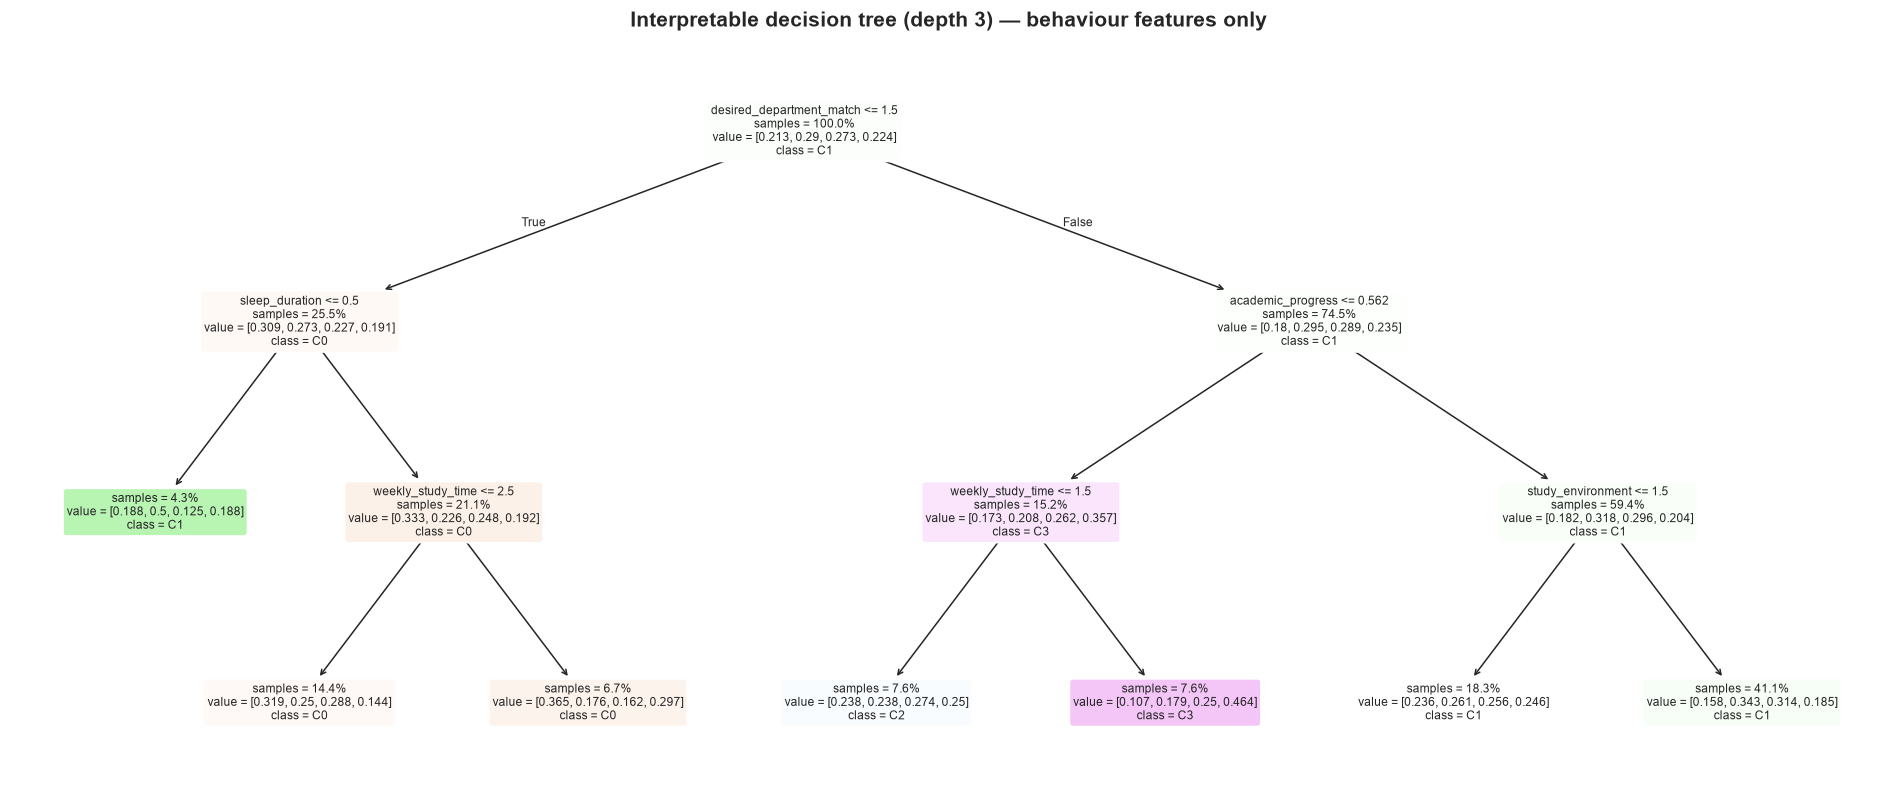

this tree's 10-fold CV accuracy: 0.273   (ZeroR = 0.290)

features it chose to split on:
   weekly_study_time          0.235
   academic_progress          0.223
   desired_department_match   0.216
   sleep_duration             0.200
   study_environment          0.127


In [59]:
tree_feats = [c + "_code" for c in ORDINAL_MAPS if c != "result_satisfaction"] + ["academic_progress"]
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40, random_state=RANDOM_STATE)
tree.fit(clean[tree_feats], y)

plt.figure(figsize=(22, 9))
plot_tree(tree, feature_names=[f.replace("_code", "") for f in tree_feats],
          class_names=["C0", "C1", "C2", "C3"], filled=True, rounded=True,
          fontsize=8, impurity=False, proportion=True)
plt.title("Interpretable decision tree (depth 3) — behaviour features only",
          fontsize=14, fontweight="bold")
save_fig("m20_decision_tree")

tree_cv = cross_val_score(tree, clean[tree_feats], y, cv=CV_SINGLE).mean()
print(f"this tree's 10-fold CV accuracy: {tree_cv:.3f}   (ZeroR = {zeror:.3f})")
print("\nfeatures it chose to split on:")
for f, imp in sorted(zip([f.replace('_code', '') for f in tree_feats], tree.feature_importances_),
                     key=lambda t: -t[1])[:6]:
    if imp > 0:
        print(f"   {f:<26} {imp:.3f}")

### 8.7 Which features does the final model lean on?

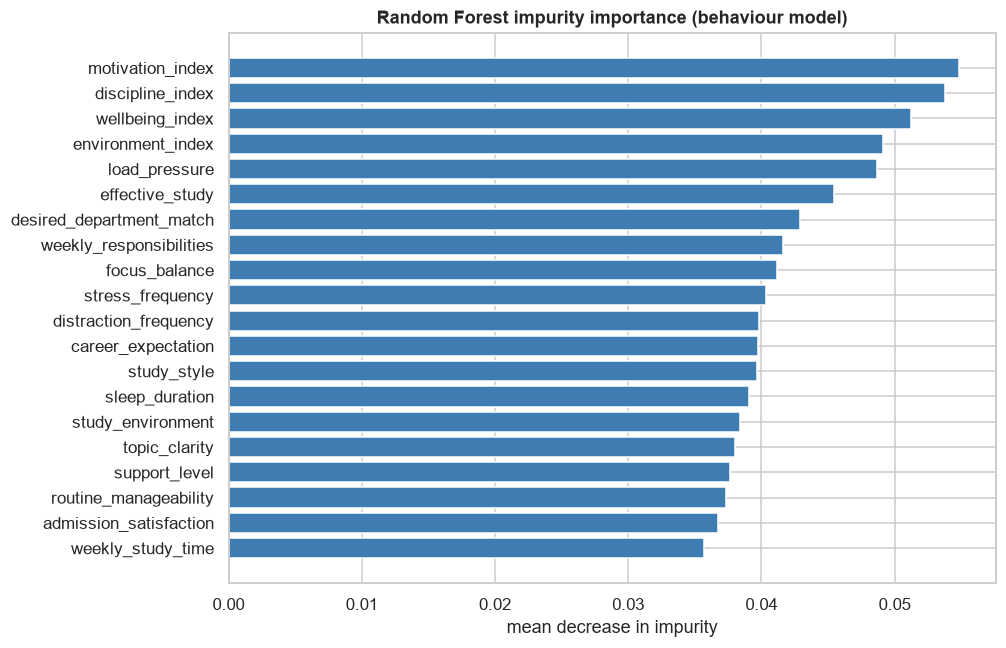

In [60]:
final_rf = make_pipe(RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                            random_state=RANDOM_STATE, n_jobs=-1), num_b, cat_b)
final_rf.fit(frame_b, y)
gini = pd.Series(final_rf.named_steps["clf"].feature_importances_,
                 index=[f.split("__")[-1].replace("_code", "")
                        for f in final_rf.named_steps["prep"].get_feature_names_out()]
                 ).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6.5))
plt.barh(gini.index[::-1], gini.values[::-1], color=PALETTE[0])
plt.title("Random Forest impurity importance (behaviour model)")
plt.xlabel("mean decrease in impurity")
save_fig("m21_rf_importance")

### 8.8 The numeric-CGPA view

Neither form collected a CGPA *number* from most respondents, so a regression here can only
predict the **midpoint of a band**. We report it because "predict the CGPA" is more intuitive than
"predict class C2" — but the honest primary result is the classification above.

MAE : 0.259 GPA points   (predict-the-mean baseline: 0.265)
R^2 : -0.001


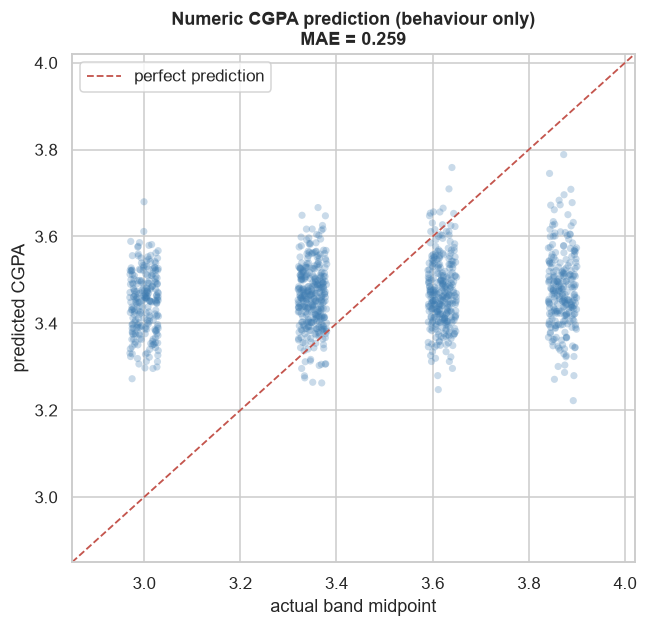

In [61]:
y_num = clean.cgpa_midpoint.values
reg_pipe = make_pipe(RandomForestRegressor(n_estimators=400, min_samples_leaf=3,
                                           random_state=RANDOM_STATE, n_jobs=-1), num_b, cat_b)
pred_num = cross_val_predict(reg_pipe, frame_b, y_num, cv=CV_SINGLE.split(frame_b, y), n_jobs=-1)
mae = mean_absolute_error(y_num, pred_num)
baseline_mae = mean_absolute_error(y_num, np.full_like(y_num, y_num.mean()))
print(f"MAE : {mae:.3f} GPA points   (predict-the-mean baseline: {baseline_mae:.3f})")
print(f"R^2 : {r2_score(y_num, pred_num):.3f}")

plt.figure(figsize=(6.6, 6))
plt.scatter(y_num + np.random.uniform(-.03, .03, len(y_num)), pred_num,
            alpha=.28, s=22, color=PALETTE[0], edgecolor="none")
lims = [2.85, 4.02]
plt.plot(lims, lims, "--", c=PALETTE[3], lw=1.2, label="perfect prediction")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("actual band midpoint"); plt.ylabel("predicted CGPA")
plt.title(f"Numeric CGPA prediction (behaviour only)\nMAE = {mae:.3f}")
plt.legend()
save_fig("m22_regression_scatter")

**Read this carefully.** An MAE of roughly a quarter of a grade point sounds small, but the
baseline of simply predicting everyone's average is barely worse. The spread of the scatter is the
honest picture: behavioural self-reports pin a student to a *region* of the GPA scale, not to a
number.

## 9. Verdict

What this dataset does and does not support, stated from the computed numbers.

### 9.1 The scoreboard

In [62]:
verdict = pd.DataFrame([
    {"question": "Beat the ZeroR floor?", "answer": f"Yes — {bb.accuracy:.1%} vs {zeror:.1%}",
     "evidence": f"behaviour model kappa = {bb.kappa:.3f} (ZeroR kappa = 0 by construction)"},
    {"question": "Do behaviour features alone predict CGPA well?",
     "answer": f"No — {bb.accuracy:.1%} accuracy, kappa = {bb.kappa:.3f}",
     "evidence": "kappa in this range is weak agreement; most gain is one band wide"},
    {"question": "Does prior academic performance help?",
     "answer": f"Yes, decisively — +{(bp.accuracy - bb.accuracy)*100:.1f} accuracy points",
     "evidence": f"{bb.accuracy:.1%} -> {bp.accuracy:.1%}, kappa {bb.kappa:.3f} -> {bp.kappa:.3f}"},
    {"question": "Are any behavioural associations real?",
     "answer": f"Yes — {int(consensus.votes.ge(1).sum())} of {len(consensus)} survive FDR correction",
     "evidence": f"strongest |rho| = {consensus.abs_rho.max():.3f}; all are small effects"},
    {"question": "Would more data help?",
     "answer": "Barely",
     "evidence": f"CV accuracy moved {val_sc.mean(1)[0]:.3f} -> {val_sc.mean(1)[-1]:.3f} "
                 f"across a 10x increase in training size"},
    {"question": "Do the hidden/composite features help?",
     "answer": f"{'Yes' if ablate.acc_delta.mean() > 0.005 else 'Not materially'}",
     "evidence": f"mean accuracy change {ablate.acc_delta.mean():+.4f}; "
                 f"best Cronbach alpha = {best_alpha:.3f}"},
])
display(verdict)

,question,answer,evidence
0,Beat the ZeroR floor?,Yes — 31.2% vs 29.0%,behaviour model kappa = 0.054 (ZeroR kappa = 0...
1,Do behaviour features alone predict CGPA well?,"No — 31.2% accuracy, kappa = 0.054",kappa in this range is weak agreement; most ga...
2,Does prior academic performance help?,"Yes, decisively — +12.2 accuracy points","31.2% -> 43.4%, kappa 0.054 -> 0.237"
3,Are any behavioural associations real?,Yes — 3 of 15 survive FDR correction,strongest |rho| = 0.119; all are small effects
4,Would more data help?,Barely,CV accuracy moved 0.270 -> 0.300 across a 10x ...
5,Do the hidden/composite features help?,Not materially,mean accuracy change -0.0109; best Cronbach al...


### 9.2 Best model — and why it is the one we would ship

In [63]:
podium = tbl_behav.head(4)[["model", "accuracy", "macro_F1", "kappa", "within_1_band"]]
display(podium.round(3))
gap_to_second = tbl_behav.iloc[0].macro_F1 - tbl_behav.iloc[1].macro_F1
print(f"macro-F1 gap between 1st and 2nd on the behaviour experiment: {gap_to_second:.4f}")
print(f"std of accuracy across the 30 folds for the winner: ±{tbl_behav.iloc[0].acc_std:.3f}")
print("\nIf the gap is smaller than the fold-to-fold std, the ranking between the top models is")
print("not statistically meaningful and we say so rather than crowning a winner on noise.")

,model,accuracy,macro_F1,kappa,within_1_band
1,SVM (RBF),0.312,0.284,0.054,0.715
2,Random Forest,0.310,0.279,0.050,0.727
3,Logistic Regression,0.291,0.272,0.025,0.744
4,Decision Tree (J48-like),0.266,0.264,0.026,0.698


macro-F1 gap between 1st and 2nd on the behaviour experiment: 0.0049
std of accuracy across the 30 folds for the winner: ±0.043

If the gap is smaller than the fold-to-fold std, the ranking between the top models is
not statistically meaningful and we say so rather than crowning a winner on noise.


### 9.3 How much of the primary result is the KUET reference-point overlap?

§5.5 flagged it: for KUET rows the CGPA target *includes* the semester whose SGPA is the primary
feature, so some of the +accuracy in Experiment 1 is arithmetic rather than prediction. We can
bound it by running the primary experiment on each source separately. On the multi-university
rows there is **no** overlap — the CGPA there is measured strictly *before* that semester — so the
lift measured on those rows alone is the clean estimate.

In [64]:
rows = []
for name, mask in [("KUET only (CGPA includes that semester)", clean.source_form == "kuet"),
                   ("multi-uni only (no overlap)", clean.source_form == "multi_uni")]:
    idx = clean.index[mask]
    yy = clean.loc[idx, "target_code"].values
    cvn = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
    est = lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                         random_state=RANDOM_STATE, n_jobs=-1)
    fp, np_, cp = build_matrix(True);  fp = fp.loc[idx]
    fb, nb, cb = build_matrix(False); fb = fb.loc[idx]
    a_p = cross_val_score(make_pipe(est(), np_, cp), fp, yy, cv=cvn, n_jobs=-1).mean()
    a_b = cross_val_score(make_pipe(est(), nb, cb), fb, yy, cv=cvn, n_jobs=-1).mean()
    rows.append({"subset": name, "n": len(idx), "behaviour_acc": round(a_b, 3),
                 "primary_acc": round(a_p, 3), "lift_pts": round((a_p - a_b) * 100, 1)})
lift = pd.DataFrame(rows)
display(lift)
print("If the lift on the no-overlap subset is of the same order as on the KUET subset, the")
print("primary result is prediction, not arithmetic. A much smaller lift there would mean the")
print("headline number is inflated by the reference-point overlap and must be discounted.")

,subset,n,behaviour_acc,primary_acc,lift_pts
0,KUET only (CGPA includes that semester),878,0.313,0.437,12.4
1,multi-uni only (no overlap),230,0.326,0.461,13.5


If the lift on the no-overlap subset is of the same order as on the KUET subset, the
primary result is prediction, not arithmetic. A much smaller lift there would mean the
headline number is inflated by the reference-point overlap and must be discounted.


## 10. Predicting for a new student

The deliverable: hand it a student's answers, get a CGPA band back. It accepts the raw form
wording so it can be driven straight from a new Google Form response, in either form's dialect.

In [65]:
FINAL_MODEL = make_pipe(RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                               random_state=RANDOM_STATE, n_jobs=-1), num_b, cat_b)
FINAL_MODEL.fit(frame_b, y)
MODAL = {c: clean[c].mode().iloc[0] for c in ORDINAL_MAPS}

def predict_cgpa(answers: dict, model=FINAL_MODEL, verbose=True):
    """answers: {column_name: raw form answer}. Anything omitted falls back to the sample mode."""
    row = {}
    for c in ORDINAL_MAPS:
        if c == "result_satisfaction":
            continue
        val = strip_bilingual(answers.get(c, MODAL[c]))
        val = LABEL_ALIASES.get(c, {}).get(val, val)
        if val not in ORDINAL_MAPS[c]:
            raise ValueError(f"{c}: {val!r} is not one of {ORDINAL_MAPS[c]}")
        row[c + "_code"] = ORDINAL_MAPS[c].index(val)

    uni = str(answers.get("university", "KUET")).upper()
    sem = float(answers.get("semester", clean.semester_raw.median()))
    row["academic_progress"] = min(sem / PROGRAMME_LENGTH.get(uni, 8), 1.5)
    u = lambda c: row[c + "_code"] / (len(ORDINAL_MAPS[c]) - 1)
    sc = lambda c: (1 - u(c)) if c in NEGATIVE_SCALES else u(c)
    for name, members in INDEX_DEF.items():
        row[name] = float(np.mean([sc(m) for m in members]))
    row["effective_study"] = u("weekly_study_time") * u("topic_clarity")
    row["focus_balance"] = u("weekly_study_time") - u("distraction_frequency")
    row["load_pressure"] = (u("weekly_responsibilities") + u("stress_frequency")
                            - u("routine_manageability")) / 2
    row["university"] = uni if uni in set(clean.university) else "KUET"
    dept = str(answers.get("department", "CSE"))
    dept = canon_dept(dept) or "Unknown"
    row["department_grouped"] = dept if dept in set(clean.department_grouped) else "Other"

    X_new = pd.DataFrame([row])[frame_b.columns]
    band = model.predict(X_new)[0]
    proba = model.predict_proba(X_new)[0]
    if verbose:
        print(f"  predicted band : {CLASS_ORDER[band]}  ({CLASS_RANGE[CLASS_ORDER[band]]})")
        print(f"  point estimate : ~{CLASS_MIDPOINT[CLASS_ORDER[band]]:.2f} CGPA (band midpoint)")
        print("  confidence     : " + "  ".join(f"{CLASS_ORDER[i][:2]}={p:.0%}" for i, p in enumerate(proba)))
    return CLASS_ORDER[band], proba

print("EXAMPLE 1 — a highly disciplined student\n" + "-" * 62)
predict_cgpa({"university": "KUET", "department": "CSE", "semester": 7,
              "attendance": "90% or more", "weekly_study_time": "More than 15 hrs",
              "study_style": "Consistent throughout the semester", "topic_clarity": "Almost everything",
              "sleep_duration": "7-8 hrs", "stress_frequency": "Rarely",
              "weekly_responsibilities": "None", "distraction_frequency": "Rarely",
              "study_environment": "Excellent for focused study", "support_level": "Strong support",
              "routine_manageability": "Very healthy and balanced",
              "admission_satisfaction": "Very satisfied",
              "desired_department_match": "Yes, exactly what I wanted",
              "career_expectation": "Completely"})

print("\nEXAMPLE 2 — a struggling student\n" + "-" * 62)
predict_cgpa({"university": "BUET", "department": "Mechanical Engineering", "semester": 5,
              "attendance": "60-74%", "weekly_study_time": "Less than 3 hrs",
              "study_style": "Occasionally when necessary", "topic_clarity": "A little",
              "sleep_duration": "Less than 5 hrs", "stress_frequency": "Almost always",
              "weekly_responsibilities": "More than 15 hrs", "distraction_frequency": "Almost every day",
              "study_environment": "Very distracting", "support_level": "No support",
              "routine_manageability": "Completely unmanageable",
              "admission_satisfaction": "Very dissatisfied",
              "desired_department_match": "Not at all what I wanted",
              "career_expectation": "Not at all"})

print("\nEXAMPLE 3 — an average student (every answer left at the sample mode)\n" + "-" * 62)
predict_cgpa({"university": "KUET", "department": "EEE", "semester": 7})

EXAMPLE 1 — a highly disciplined student
--------------------------------------------------------------
  predicted band : C3_3_75_plus  (3.75 and above)
  point estimate : ~3.87 CGPA (band midpoint)
  confidence     : C0=8%  C1=8%  C2=21%  C3=64%

EXAMPLE 2 — a struggling student
--------------------------------------------------------------


  predicted band : C0_below_3_20  (below 3.20)
  point estimate : ~3.00 CGPA (band midpoint)
  confidence     : C0=36%  C1=31%  C2=20%  C3=14%

EXAMPLE 3 — an average student (every answer left at the sample mode)
--------------------------------------------------------------
  predicted band : C2_3_50_to_3_74  (3.50 - 3.74)
  point estimate : ~3.62 CGPA (band midpoint)
  confidence     : C0=11%  C1=32%  C2=32%  C3=25%


('C2_3_50_to_3_74', array([0.11459045, 0.31582425, 0.31959872, 0.24998659]))

**What the three examples show.** The model separates the extremes but is far from confident even
there — which is exactly what §8 predicted. Reporting it any other way would overstate what a
15-question self-report survey can do.

It also handles the KUET bilingual dialect and the multi-university dialect through the same
entry point, because `strip_bilingual` and `canon_dept` sit inside the prediction function rather
than only in the training script.

## 11. Export for WEKA

WEKA reads CSV, but ARFF is safer: it pins each attribute's type and the exact set of nominal
values, so WEKA cannot silently read an ordinal code as nominal or guess the class order. Ordinal
features are written as **numeric** (their codes are meaningful and ordered); `university`,
`department` and the class are **nominal**.

In [66]:
def to_arff(frame, relation, path, class_col="cgpa_band"):
    cols = [c for c in frame.columns if c != class_col] + [class_col]
    frame = frame[cols]
    lines = [f"@relation {relation}", ""]
    for c in cols:
        s = frame[c]
        if pd.api.types.is_numeric_dtype(s):
            lines.append(f"@attribute {c} numeric")
        else:
            vals = sorted(s.astype(str).unique())
            if c == class_col:
                vals = [v for v in CLASS_ORDER if v in vals]
            lines.append("@attribute {} {{{}}}".format(c, ",".join(vals)))
    lines += ["", "@data"]
    for _, r in frame.iterrows():
        lines.append(",".join(f"{r[c]:g}" if pd.api.types.is_number(r[c]) else str(r[c]) for c in cols))
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return path

def weka_frame(include_prior):
    f = pd.DataFrame({c: clean[c + "_code"] for c in ORDINAL_MAPS if c != "result_satisfaction"})
    f["academic_progress"] = clean.academic_progress
    for c in HIDDEN_COLS:
        f[c] = clean[c]
    f["university"] = clean.university
    f["department"] = clean.department_grouped
    if include_prior:
        f["recent_sgpa_band"] = clean.recent_sgpa_band
    f["cgpa_band"] = clean.cgpa_band
    return f

wp, wb = weka_frame(True), weka_frame(False)
wp.to_csv(OUT_DIR / "merged_primary_weka.csv", index=False)
wb.to_csv(OUT_DIR / "merged_behavior_weka.csv", index=False)
to_arff(wp, "merged_student_performance_primary", OUT_DIR / "merged_primary.arff")
p2 = to_arff(wb, "merged_student_performance_behavior", OUT_DIR / "merged_behavior.arff")

print("Written:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"   {f.name:<32} {f.stat().st_size/1024:7.1f} KB")
print(f"\nmerged_primary.arff  : {wp.shape[0]} instances, {wp.shape[1]-1} attributes + class")
print(f"merged_behavior.arff : {wb.shape[0]} instances, {wb.shape[1]-1} attributes + class")
print("\nFirst lines of merged_behavior.arff:")
print("\n".join(p2.read_text(encoding="utf-8").split("\n")[:10]))

Written:
   merged_behavior.arff               102.9 KB
   merged_behavior_clean.csv          287.4 KB
   merged_behavior_weka.csv           104.1 KB
   merged_full_clean.csv              400.1 KB
   merged_primary.arff                119.0 KB
   merged_primary_clean.csv           303.4 KB
   merged_primary_weka.csv            120.2 KB

merged_primary.arff  : 1108 instances, 25 attributes + class
merged_behavior.arff : 1108 instances, 24 attributes + class

First lines of merged_behavior.arff:
@relation merged_student_performance_behavior

@attribute admission_satisfaction numeric
@attribute desired_department_match numeric
@attribute attendance numeric
@attribute weekly_study_time numeric
@attribute study_style numeric
@attribute topic_clarity numeric
@attribute sleep_duration numeric
@attribute stress_frequency numeric


> **In WEKA, expect the instance count printed above** — not the 878 the supplied tutorial PDF
> mentions, and not notebook `01`'s 230.

## 12. Summary of findings

Generated from the computed results, so the write-up cannot drift from the numbers.

In [67]:
print("=" * 82)
print("DATASET")
print("=" * 82)
print(f"  raw responses merged : {len(merged)} ({len(multi)} multi-university + {len(kuet)} KUET)")
print(f"  after cleaning       : {len(clean)} rows x {len(FEATURE_ORDER)} features + target")
print(f"  rows dropped         : {len(merged) - len(clean)} (no usable CGPA answer)")
print(f"  values imputed       : {n_fill} responsibilities + <1.3% scattered Likert blanks")
print(f"  universities         : {dict(clean.university.value_counts())}")
print(f"  departments          : {clean.department.nunique()} canonical "
      f"(from {merged[['department_listed','department_other']].stack().nunique()} raw strings)")
print(f"  target balance       : {dict(clean.cgpa_band.value_counts().reindex(CLASS_ORDER))}")

print("\n" + "=" * 82)
print("PIPELINE A — WHAT MATTERS (behaviour features only)")
print("=" * 82)
for i, r in consensus.head(6).iterrows():
    mark = "SIGNIFICANT" if r.votes >= 1 else "not significant"
    print(f"  {i}. {r.feature:<26} rho={r.spearman_rho:+.3f}  q={r.q_spearman:.4f}  {mark}")
print(f"\n  {int(consensus.votes.ge(1).sum())} of {len(consensus)} features show a statistically")
print(f"  reliable association with CGPA band after FDR correction (notebook 01 at n=230: 0).")

print("\n" + "=" * 82)
print("PIPELINE B — PREDICTION")
print("=" * 82)
print(f"  ZeroR baseline                    : {zeror:.1%}")
print(f"  Best BEHAVIOUR {bb.model:<20}: acc {bb.accuracy:.1%}  macro-F1 {bb.macro_F1:.3f}  "
      f"kappa {bb.kappa:.3f}  within-1 {bb.within_1_band:.1%}")
print(f"  Best PRIMARY   {bp.model:<20}: acc {bp.accuracy:.1%}  macro-F1 {bp.macro_F1:.3f}  "
      f"kappa {bp.kappa:.3f}  within-1 {bp.within_1_band:.1%}")
print(f"\n  Prior semester SGPA is worth {(bp.accuracy - bb.accuracy)*100:+.1f} accuracy points.")

print("\n" + "=" * 82)
print("LIMITATIONS (must appear in the report)")
print("=" * 82)
for lim in [
    "Self-reported grades and habits - no registrar data to verify against.",
    f"Convenience sample: {len(kuet)/len(merged):.0%} of rows are KUET, and 75% of those sit in one semester.",
    "The CGPA reference point differs by one semester between the two forms (S5.5, S9.3).",
    "admission_satisfaction may carry a first-option response artefact on the KUET form (S6.5).",
    "GPA was collected in bands, so no true continuous CGPA exists.",
    "Cross-sectional data: every result is an association, never a cause.",
]:
    print(f"  - {lim}")
print("=" * 82)

DATASET
  raw responses merged : 1126 (230 multi-university + 896 KUET)
  after cleaning       : 1108 rows x 25 features + target
  rows dropped         : 18 (no usable CGPA answer)
  values imputed       : 45 responsibilities + <1.3% scattered Likert blanks
  universities         : {'KUET': np.int64(878), 'BUET': np.int64(104), 'BRAC': np.int64(101), 'CUET': np.int64(25)}
  departments          : 24 canonical (from 110 raw strings)
  target balance       : {'C0_below_3_20': np.int64(236), 'C1_3_20_to_3_49': np.int64(321), 'C2_3_50_to_3_74': np.int64(303), 'C3_3_75_plus': np.int64(248)}

PIPELINE A — WHAT MATTERS (behaviour features only)
  1. desired_department_match   rho=+0.119  q=0.0010  SIGNIFICANT
  2. academic_progress          rho=-0.057  q=0.1597  not significant
  3. weekly_responsibilities    rho=-0.086  q=0.0202  SIGNIFICANT
  4. support_level              rho=+0.054  q=0.1597  not significant
  5. attendance                 rho=+0.090  q=0.0197  SIGNIFICANT
  6. career_exp

In [68]:
summary_out = {
    "n_raw_multi": int(len(multi)), "n_raw_kuet": int(len(kuet)),
    "n_raw_merged": int(len(merged)), "n_clean": int(len(clean)),
    "n_dropped": int(len(merged) - len(clean)),
    "n_features": int(len(FEATURE_ORDER)),
    "n_departments_raw": int(merged[["department_listed", "department_other"]].stack().nunique()),
    "n_departments_canonical": int(clean.department.nunique()),
    "universities": {k: int(v) for k, v in clean.university.value_counts().items()},
    "target_distribution": {k: int(v) for k, v in clean.cgpa_band.value_counts().reindex(CLASS_ORDER).items()},
    "zeror_baseline": round(float(zeror), 4),
    "best_primary": {"model": bp.model, "accuracy": round(float(bp.accuracy), 4),
                     "macro_F1": round(float(bp.macro_F1), 4), "kappa": round(float(bp.kappa), 4),
                     "within_1_band": round(float(bp.within_1_band), 4)},
    "best_behaviour": {"model": bb.model, "accuracy": round(float(bb.accuracy), 4),
                       "macro_F1": round(float(bb.macro_F1), 4), "kappa": round(float(bb.kappa), 4),
                       "within_1_band": round(float(bb.within_1_band), 4)},
    "prior_sgpa_lift_pts": round(float(bp.accuracy - bb.accuracy) * 100, 2),
    "significant_feature_count": int(consensus.votes.ge(1).sum()),
    "top_features": consensus.head(8)[["feature", "spearman_rho", "q_spearman", "mean_rank", "votes"]]
                    .round(4).to_dict("records"),
    "cronbach_alpha": alpha_df.set_index("index").cronbach_alpha.to_dict(),
    "hidden_feature_mean_acc_delta": round(float(ablate.acc_delta.mean()), 4),
    "learning_curve": {"n_start": int(sizes[0]), "acc_start": round(float(val_sc.mean(1)[0]), 4),
                       "n_end": int(sizes[-1]), "acc_end": round(float(val_sc.mean(1)[-1]), 4)},
    "regression": {"mae": round(float(mae), 4), "baseline_mae": round(float(baseline_mae), 4),
                   "r2": round(float(r2_score(y_num, pred_num)), 4)},
    "source_lift_check": lift.to_dict("records"),
    "gap_analysis": gap_rows,
}
(DOC_DIR / "results_summary_merged.json").write_text(json.dumps(summary_out, indent=2), encoding="utf-8")
res_primary.to_csv(DOC_DIR / "model_results_merged_primary.csv", index=False)
res_behav.to_csv(DOC_DIR / "model_results_merged_behavior.csv", index=False)
consensus.to_csv(DOC_DIR / "feature_importance_merged.csv", index=False)
rep.to_csv(DOC_DIR / "replication_n230_vs_n1108.csv", index=False)
src_cmp.to_csv(DOC_DIR / "source_form_comparison.csv", index=False)
pd.DataFrame(STEP_LOG).to_csv(DOC_DIR / "cleaning_step_log.csv", index=False)
print("Saved to docs/: results_summary_merged.json, model_results_merged_*.csv,")
print("               feature_importance_merged.csv, replication_n230_vs_n1108.csv,")
print("               source_form_comparison.csv, cleaning_step_log.csv")

Saved to docs/: results_summary_merged.json, model_results_merged_*.csv,
               feature_importance_merged.csv, replication_n230_vs_n1108.csv,
               source_form_comparison.csv, cleaning_step_log.csv
